# Aufgabe 2 - Laden und Speichern von Daten

## **Hintergrund**
Im Allgemeinen wollen wir Daten analysieren, die mit einem Computerprogramm oder mit einem Messgerät aufgenommen worden sind und die in einer Datei vorliegen. In diesen Dateien können die Daten in verschiedenen Formen gespeichert sein. Wir beschränken uns hier ausschliesslich auf Textdateien, in denen die Daten im ASCII-Format vorliegen.
Den Inhalt dieser Dateien wollen wir in Python laden und einer Variable (z.B. einem Array) zuweisen. Nach der Analyse wollen wir diese Daten wiederum in einer neuen Datei abspeichern. 

Der Inhalt einer Messdaten-Datei besteht üblicherweise aus einem Header mit Metadaten und den Messdaten selbst. Der Header ist dazu da, die Messung zu beschreiben, so dass man später nachvollziehen kann, zu welchem Experiment die Daten gehören. Ausserdem enthält er normalerweise eine Erklärung zur Struktur der Daten, z.B. was die einzelnen Zeilen und Spalten bedeuten.

Wir haben Ihnen mit der Übung die Beispieldatei "example_data.txt" zur Verfügung gestellt. Wenn Sie diese in einem Texteditor öffnen, können Sie sich ein Bild davon machen, wie eine Messdaten-Datei aussehen könnte. Für die Aufgaben unten werden Sie selbst eine neue Datei erstellen und von Hand Zahlen eingeben, damit Sie an einem einfachen Beispiel ausprobieren können, wie Python und Sie selbst mit der Datei interagieren können.

Die Datei mit den Messdaten ist auf dem Computer gespeichert und zwar in einer Datei mit einem Namen und einer Endung, die üblicherweise das Dateiformat charakterisiert: "Name.Endung"

Beispiele für Dateiendungen sind: 

|Dateiendung | Beschreibung |
| :- | :- |
|.txt | Textdatei |
| .html | Eine Textdatei, die einen HTML-Code enthält und von einem Browser interpretiert werden kann |
| .py | Eine Textdatei, die ein Python-Skript enthält das von einem Python-Interpreter interpretiert werden kann |
| .ipynb | Eine IPython Notebook-Datei, die in einem Binärformat gespeichert ist und nur sinnvoll in IPython Notebooks gelesen und interpretiert werden kann |
|.jpg | Eine Binärdatei, die ein Bild im JPEG-Format enthält |

Diese Dateien sind im Computer in einer Verzeichnisstruktur organisiert. In Windows sieht so ein Verzeichnisbaum üblicherweise so aus:

| Verzeichnis | Beschreibung |
| :- | :- |
| C:\ | Root-Verzeichnis (Wurzel des Baums). |
| C:\Progam Files\ | Hier sind alle 64bit Programme abgespeichert die auf dem Computer installiert sind. |
| C:\Program Files (x86)\ | Hier sind alle 32bit Programme abgespeichert die auf dem Computer installiert sind. |
| C:\Users\ | Hier sind (üblicherweise) die Dateien abgespeichert, die von den Computerbenutzern angelegt oder erzeugt wurden. |
| C:\Users\Name | Im Users-Ordner ist für jeden Benutzer (jeden Account) ein Ordner mit dem Namen (Name) des Accounts angelegt. |
| C:\Users\Name\Desktop | Hier sind alle Dateien abgespeichert, die auf dem Desktop dieser Benutzerin liegen. |
| C:\Users\Name\Documents | Hier sind üblicherweise die Dateien abgespeichert, die der Benutzer mit Programmen erstellt hat. |
| C:\Users\Name\Downloads | Hier sind üblicherweise die Dateien abgespeichert, die die Benutzerin aus dem Internet heruntergeladen hat. |
| C:\Users\Name\OneDrive | Hier sind alle Dateien lokal gespeichert, die aus dem OneDrive Cloud-Speicher synchronisiert werden. |


**MacOS**:

- Das Root-Verzeichnis ist "/"
- Die Programme sind in "/Applications/"
- Die User-Ordner und eine analoge Substruktur wie in Windows sind in "/Users/Name"

**Linux**:

- Das Rootverzeichnis ist "/"
- Systemprogramme sind in "/bin/", "/sbin/", "/usr/bin", "/usr/sbin/"
- Die Systemkonfiguration ist in "/etc/"
- Die Userordner und analoge Substruktur sind in "/home/name/"

Achtung! Auf Windows sind Pfad- und Dateinamen standardmässig case-insensitive (d.h. Gross- und Kleinschreibung sind irrelevant), während auf MacOS und Linux die Pfad- und Dateinamen case-sensitive sind.

## **Aufgaben**

### Orientierung in der Verzeichnisstruktur

Das IPython Notebook ist auch eine Datei, die irgendwo in diesem Verzeichnisbaum liegt, z.B.
C:\Users\Name\Documents\Code\Python

Wenn wir Jupyter notebook starten, starten wir im Browser mit einem Dateiexplorer, der es uns erlaubt zu dem Verzeichnis zu wechseln, in dem wir unseren Code abgespeichert haben, bzw. in dem wir unseren Code abspeichern wollen.

Ordnung in dieser Verzeichnisstruktur zu halten ist hilfreich.

In Python ist dann standardmässig das Arbeitsverzeichnis dasjenige Verzeichnis, in dem die Programmdatei, also der Code, liegt. Das Arbeitsverzeichnis heisst auch "current working directory" und kann folgendermassen ermittelt werden:

In [1159]:
# Einbinden der Bibliothek für Zugriff auf die Dateistruktur
import os
# Ermitteln des current working directory und sofortige Ausgabe
print(os.getcwd())

/Users/std_admin/Desktop/system/ETH/Bachelor Physics/ETH-Data-Analysis/Jupiter notebooks/ExamLibary


Aufgaben:

- Kopieren Sie den soeben ermittelten Pfad zum Arbeitsverzeichnis in die Zwischenablage.
- Öffnen Sie den Dateiexplorer Ihres Betriebssystems
- Fügen Sie den kopierten Pfad in die Pfadzeile des Explorers und bestätigen Sie die Änderung

Mac: Gehe zu... -> Gehe zum Ordner -> *Pfad hierher kopieren* (shortcut: Cmd-Shift-G)<br>
Linux: Kommt auf den verwendenten file explorer an. Oft kann man mit Ctrl-L die Pfadzeile auswählen.


Nun haben Sie ein offenes Explorer-Fenster zum Arbeitsverzeichnis!

Hier sehen wir alle Dateien und Ordner in diesem Verzeichnis. Wir können das auch in Python anzeigen:

In [1160]:
# Für mehr Übersichtlichkeit benutzen wir eine Variable 'cwd' um den Pfad des Arbeitsverzeichnisses zu speichern
cwd = os.getcwd()
# Erzeugen einer Liste 'files' mit allen Dateien und Ordnern im cwd
files = os.listdir(cwd)
# Ausgabe der Liste
print(files)

['.DS_Store', 'Scripts_ML.ipynb', 'DataOut.txt', 'Scripts_LW.ipynb', 'data']


Dieser Code erzeugt eine Liste mit allen Ordnern und Verzeichnissen im Arbeitsverzeichnis und gibt diese aus.

Aufgaben:
- Erzeugen Sie eine Textdatei mit dem Namen "Data.txt" im Arbeitsverzeichnis (z.B. in Windows: Rechtsklick im Dateiexplorer, im Kontextmenü: New - Text Document; Mac: Öffnen Sie Textedit und erzeugen sie die Datei und speichern Sie diese in dem Ordner, den Sie als Arbeitsverzeichnis identifiziert haben)
- Öffnen Sie diese Datei mit einem Texteditor (z.B. in Windows: Rechtsklick auf die Datei, im Kontextmenü: Open with - Notepad)
- Geben Sie im Editor jeweils in ein paar Zeilen eine Zahl ein.
- Speichern Sie die Datei
- Führen Sie den obigen Code erneut aus. Sie sollten nun die neue Datei "Data.txt" in der Liste wiederfinden können.

Um im Allgemeinen auf eine Datei zugreifen zu können, müssen wir nicht nur ihren Namen, sondern auch ihre Position im Verzeichnisbaum kennen. Also erzeugen wir uns einen absoluten Pfad, der den Zugriff auf die Datei vollständig charakterisiert:

In [1161]:
file = os.path.join(cwd, 'Musterloesung_Data.txt')
print(file)

/Users/std_admin/Desktop/system/ETH/Bachelor Physics/ETH-Data-Analysis/Jupiter notebooks/ExamLibary/Musterloesung_Data.txt


Nun sehen Sie den absoluten Pfad der Datei (in Windows üblicherweise beginnend mit "C:\"), mit dem Dateinamen am Ende.

### Laden von Dateien

Nun können wir den Inhalt der Datei in Python laden:

In [1162]:
import numpy as np
# Laden der Datei die über den Pfad 'file' charakterisiert ist und abspeichern der Dateiinhalte in der Variable 'data'
# data = np.loadtxt(file)
# print(data)

Nun sehen Sie die Zahlen, die Sie zuvor in die Datei geschrieben haben.

Nebenbemerkung: Dateien können auch über relative Pfade, ausgehend vom aktuellen Arbeitsverzeichnis, angegeben werden. Das heisst, wir können diese Daten also auch einfach mit: `data = np.loadtxt('Data.txt')` laden, da sie sich im gleichen Verzeichnis wie unser IPython-Notebook befinden. Probieren Sie es aus.

Aufgabe:
- Öffnen Sie wieder die Datei "Data.txt" in einem Editor, geben Sie nun Zahlen in zwei Zeilen ein, und speichern Sie die Datei. Wichtig: Die Zahlen müssen durch Leerzeichen getrennt sein und in beiden Zeilen müssen gleich viele Zahlen stehen!
- Führen Sie den vorherigen Code wieder aus. Diese Funktion ist recht intelligent und interpretiert das Format der Zahlen oft vernünftig.

In [1163]:
# Ihr Code
# data = np.loadtxt(file)
# print(data)

Bisher enthält die Datei nur Zahlen, üblicherweise wollen wir in den ersten paar Zeilen aber auch Metadaten speichern. Metadaten könnten zum Beispiel sein: Das Datum der Messung, der Name des Messgeräts, das die Dateien erzeugt hat, oder die Bezeichnung der Messgrössen, die in der Datei gespeichert sind. Solche Metadaten sind wichtig, damit man später noch nachvollziehen kann, was gemessen wurde und wie.

Aufgabe:

- Öffnen Sie nochmal die Datei in einem Editor und fügen Sie am Anfang eine oder mehrere Zeilen mit Metadaten ein, z.B. ihrem Namen, dem heutigen Datum, etc.

Da die Zeilen mit den Metadaten nicht strukturiert sind, kann die funktion np.loadtxt sie nicht interpretieren: Wenn Sie den obigen Code nochmal ausführen, sollten Sie eine Fehlermeldung erhalten. Daher wollen wir der Funktion die Anweisung mitgeben, die Zeilen mit den Metadaten zu überspringen. Das entsprechende Argument finden Sie im der Dokumentation der np.loadtxt Funktion:

In [1164]:
np.loadtxt?

Signature:
np.loadtxt(
    fname,
    dtype=<class 'float'>,
    comments='#',
    delimiter=None,
    converters=None,
    skiprows=0,
    usecols=None,
    unpack=False,
    ndmin=0,
    encoding=None,
    max_rows=None,
    *,
    quotechar=None,
    like=None,
)
Docstring:
Load data from a text file.

Parameters
----------
fname : file, str, pathlib.Path, list of str, generator
    File, filename, list, or generator to read.  If the filename
    extension is ``.gz`` or ``.bz2``, the file is first decompressed. Note
    that generators must return bytes or strings. The strings
    in a list or produced by a generator are treated as lines.
dtype : data-type, optional
    Data-type of the resulting array; default: float.  If this is a
    structured data-type, the resulting array will be 1-dimensional, and
    each row will be interpreted as an element of the array.  In this
    case, the number of columns used must match the number of fields in
    the data-type.
comments : str or se

Aufgabe:

- Finden Sie in der Dokumentation das Argument, mit dem Sie festlegen können, wie viele Zeilen am Anfang der Datei übersprungen werden, und wenden Sie es an, um Ihre Datei einzulesen.

In [1165]:
# Ihr Code
# data = np.loadtxt(file, skiprows=1)
# print(data)

Wenn man nicht von vornherein weiss, wie viele Zeilen Metadaten die Datei enthält, ist es oft am einfachsten die Datei in einem Texteditor zu öffnen und die Zeilen zu zählen. Falls die Zeilen mit den Metadaten alle mit dem gleichen Symbol beginnen (z.B. "#"), können diese auch automatisch ignoriert werden, indem man das Argument `comments='#'` verwendet.

Aufgabe:

- Nun haben Sie alle Mittel, die Sie brauchen, um die Daten aus der Beispieldatei "example_data.txt" einzulesen. Versuchen Sie es!

In [1166]:
# Ihr Code
data = np.loadtxt('data/example_data.txt', skiprows=9)
x = data[:, 0]
y = data[:, 1]
psi = data[:, 2]
v = data[:, 3]

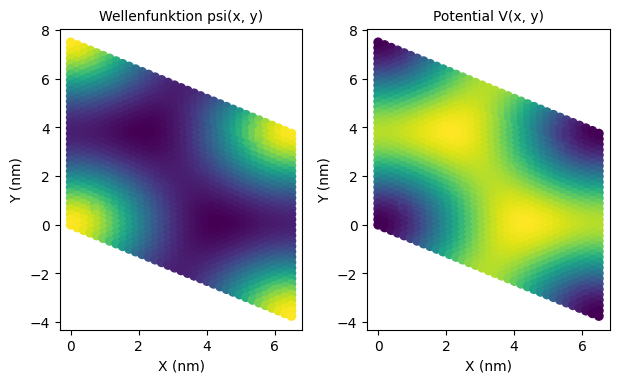

In [1167]:
# Wir können die Daten plotten um zu schauen, ob sie richtig geladen wurden.
import matplotlib.pyplot as plt
cm = 1 / 2.54
fig = plt.figure(figsize=(16*cm, 10*cm))
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)

ax1.scatter(x, y, c=psi)
ax1.set_xlabel('X (nm)')
ax1.set_ylabel('Y (nm)')
ax1.set_title('Wellenfunktion psi(x, y)', size=10)

ax2.scatter(x, y, c=v)
ax2.set_xlabel('X (nm)')
ax2.set_ylabel('Y (nm)')
ax2.set_title('Potential V(x, y)', size=10)

fig.tight_layout()

Weiter unten in diesem Notebook gibt es noch Beispiele mit Erklärungen zu etwas allgemeineren Möglichkeiten Daten einzulesen. Dies kann nützlich sein, wenn man nicht genau weiss, wie die Daten strukturiert sind, oder einen Code schreibt, der verschiedene Arten von Daten lesen soll. Für diesen Kurs wird die Funktion np.loadtxt jedoch ausreichen.

### Daten abspeichern

Nun wollen wir die Daten wieder abspeichern, um sie zu archivieren oder sie gegebenenfalls zu einem späteren Zeitpunkt weiter zu analysieren.

Hierzu gibt es verschiedene Möglichkeiten:

1) Die einfachste Möglichkeit ist wieder die Numpy-Funktion savetxt, das Äquivalent zu loadtxt:


In [1168]:
x = np.array([1, 2, 3, 4, 5])
y = np.array([0.1, 0.2, 0.3, 0.4, 0.5])
z = np.array([-5, -6, -7, -8, -9])

np.savetxt('DataOut.txt', (x,y,z), delimiter=',')

Die wichtigsten Parameter sind hier:
- `DataOut.txt`: Der Dateiname der Ausgabedatei. Hier könnte auch wieder ein absoluter Pfad angegeben werden. In dieser einfachen Form mit einem Dateinamen wird die Datei im aktuellen Arbeitsverzeichnis erstellt. Die Dateiendung bestimmt den Dateityp, diese muss also immer mit eingegeben werden!
- `(x,y,z)`: Die Daten, die wir abspeichern wollen. Hier übergeben wir die drei Arrays, die zeilenweise abgespeichert werden.
- `delimiter=','`: Der Delimiter, also das Zeichen, mit dem die einzelnen Datenwerte in der Datei voneinander getrennt werden.

Aufgabe:
- Öffnen Sie die Datei, die Sie so erstellt haben. Was ist anders als in der Datei, die wir eingelesen haben?
- Überlegen Sie sich, wie wir vorgehen könnten um die Daten in dem gleichen Format abzuspeichern wie in der Datei, die wir eingelesen haben.

Um Metadaten einzufügen, kann man einen String für das Argument `header` übergeben.

In [1169]:
np.savetxt('DataOut.txt', (x,y,z), delimiter=',', header='Beispieldatei Datenanalyse, 14.2.2023. Format: x, y, z')

### String Formatting: Zahlenwerte für die Ausgabe formatieren

Berechnete Zahlenwerte, die ausgegeben werden, müssen oft formatiert werden, z.B. um eine sinnvolle Anzahl signifikanter Ziffern anzugeben. Ausserdem möchte man häufig einen beschreibenden Text damit kombinieren. Beides wird mit format strings erreicht.

Hierzu werden in einem String Platzhalter eingefügt, und die Werte, die die Platzhalter ersetzen sollen, mit der `format` Funktion an den String weitergegeben.

In [1170]:
print('Die Summe der Zahlen {} und {} ist gleich {}.'.format(3, 5, 8))

Die Summe der Zahlen 3 und 5 ist gleich 8.


Die geschweiften Klammern sind die Platzhalter für die Werte der Argumente der format-Funktion.

In den Platzhaltern kann man Formatierungsanweisungen einfügen, die angeben wie die Zahlen interpretiert und formatiert werden sollen:
- `{:d}` : Integer
- `{:f}` : Fliesskomma
- `{:0.2f}`: Fliesskomma mit 2 Nachkommestellen

In [1171]:
print('{:.2f}'.format(1.3502))

1.35


Aufgabe:

- Probieren Sie verschieden Formate aus. Erzeugen Sie zum Beispiel mit einer Funktion wie np.exp Gleitkommazahlen, und geben Sie diese mit einer fixen Anzahl Ziffern aus.

In [1172]:
# Ihr code
print('exp(3) = {:.5f}'.format(np.exp(3)))

exp(3) = 20.08554


Solche Formatierungsanweisungen können auch in der np.savetxt Funktion verwendet werden, um die Darstellung der Zahlen zu bestimmen.

Für viele weitere Informationen über String-Formatierung siehe https://pyformat.info/

**String Interpolation / f-Strings**

In neueren Python Versionen (python 3.6+) gibt es sogenannte formatierte Strings (f-Strings), die das Einfügen von Variabelwerten noch einfacher machen. Hier sind einige Anwendungsbeispiele: 

In [1173]:
# definiere einige Variablen:
pi = 3.141592653589793
e = 2.718281828459045
sr2 = 1.414213562373095
c = 299792458

# einfacher f-string
s = f'Der Wert von pi ist: {pi}, Der Wert der Eulerschen Zahl ist: {e}, die Wurzel von 2 ist: {sr2}'
print(s)
print('-----')

# mit gerundeten Werten
s = f'Der Wert von pi ist: {pi:.2f}, Der Wert der Eulerschen Zahl ist: {e:.3f}, die Wurzel von 2 ist: {sr2:.4f}'
print(s)
print('-----')

# wissenschaftliche Notation
s = f'Die Lichtgeschwindigkeit im Vakuum ist {c:e} m/s, oder auf zwei Nachkommastellen gerundet {c:.2e} m/s'
print(s)

Der Wert von pi ist: 3.141592653589793, Der Wert der Eulerschen Zahl ist: 2.718281828459045, die Wurzel von 2 ist: 1.414213562373095
-----
Der Wert von pi ist: 3.14, Der Wert der Eulerschen Zahl ist: 2.718, die Wurzel von 2 ist: 1.4142
-----
Die Lichtgeschwindigkeit im Vakuum ist 2.997925e+08 m/s, oder auf zwei Nachkommastellen gerundet 3.00e+08 m/s


## Zusammenfassung

Mit diesen einfachen Beispielen können Sie nun Daten aus Textdateien einlesen und weiterverarbeiten. Darüber hinaus können Sie Daten in Textdateien abspeichern und Zahlenwerte in formatierte Strings umwandeln.


## Zusatz: Manuelles Einlesen von Dateien

Sie haben in den Übungen die Funktion np.loadtxt schon ein bisschen kennen gelernt und damit gearbeitet. Wir wollen nun ein bisschen allgemeiner auf Daten in Textdateien blicken.

Oft liegen die Daten aber in einem speziellen Format vor (z.B. vorgegeben von dem Messgerät das die Datei erzeugt hat), und wir wollen sie auch entsprechend einlesen.
Um zu verstehen, wie die Daten in einer Datei vorliegen, können wir die Datei mit einem Editor öffnen und betrachten. Wir können aber auch in Python eine Datei etwas allgemeiner verstehen:

Idealerweise beinhalten Daten-Dateien nicht nur die Daten (also Zahlen), sondern auch Metainformation über die Daten bzw. das Experiment durch das sie zustande gekommen sind. Ein einfaches Beispiel wäre eine Datei mit folgendem Inhalt:

x, y<br>
0.1, 0.31<br>
0.2, 0.45<br>
0.3, 0.55<br>

Hier sind offensichtlich die Werte für x und y genmessen worden. 

Aufgabe:
- Kopieren Sie diesen Textblock in Ihre Data.txt Datei, oder erzeugen Sie einen ähnlichen Inhalt, und speichern Sie die Datei ab.

Um alle Zeilen einer Textdatei einzulesen und in einer Liste aus Strings zu speichern, ist folgender Code praktisch:

In [1174]:
file = os.path.join(cwd, 'data', 'Musterloesung_Data_bearbeitet.txt')
with open(file, 'r') as f:
    lines = f.readlines()

Mit dem `open`-Befehl öffnen wir die Datei (hier die Datei mit dem Pfad `file`). Um die Datei nur zu lesen, übergeben wir das Argument `'r'` (um die Datei zu schreiben würden wir `'w'` übergeben). Die Variable `f` ist ein Datei-Objekt, auf dem wir Methoden wie z.B. hier `readlines()` anwenden können. Die Methode `readlines()` übergibt eine Liste aus Strings, die alle Zeilen der Datei beinhaltet.
Die `with` Umgebung garantiert, dass die Datei am Ende (auch im Misserfolg) wieder ordentlich geschlossen wird.

Wir können diese Zeilen ausgeben:

In [1175]:
print(lines)

['x, y\n', '0.1, 0.31\n', '0.2, 0.45\n', '0.3, 0.55\n']



Die Variable `lines` ist eine Liste, in der jedes Element eine Zeile als String beinhaltet. Um auf eine einzelne Zeile bzw. ein Element in dieser Liste zugreifen zu können, indexieren wir dieses Element:

In [1176]:
print(lines[1])

0.1, 0.31



Dies gibt uns das zweite Element aus der Liste `lines` aus. Falls Sie mehr als eine Zeile Metadaten in die Datei eingegeben haben, müssen Sie den Index anpassen, um die erste Zeile mit Daten zu erhalten.

Um mit den Daten arbeiten zu können, müssen wir sie aus dem String extrahieren und in ein Zahlenformat umwandeln. Das können wir z.B. mit dem Numpy-Befehl `np.fromstring()` machen:

In [1177]:
a = np.fromstring(lines[1], dtype=float, sep=',')

Hier übergeben wir als Argumente:
- `lines[1]`: Die zweite Zeile aus der Datei
- `dtype=float`: Hiermit spezifizieren wir, wie die Zahlen interpretiert werden sollen. In diesem Fall als Fliesskommazahl (floating point, kurz float). Für Integer könnten wir `int` übergeben.
- `sep=','`: Hiermit spezifizieren wir, wodurch die einzelnen Zahlen in dem String separiert werden. Der sogenannte Delimiter. Hier ist das ein Komma. Man könnte die Werte aber beispielsweise auch durch ein Semikolon separieren, dann würde man `sep=';'`  als Delimiter übergeben.

Das Ergebnis ist ein Array `a` aus float Zahlen.

Mit

In [1178]:
print(a)

[0.1  0.31]


können wir wiederum das Array ausgeben.

Wenn wir nun die Daten aus der Liste aus Strings extrahieren wollen, müssen wir die erste Zeile ignorieren, weil diese keine Zahlenwerte enthält.
Wir müssen also alle bis auf die erste Zeile in ein Daten-Array umwandeln. Dazu verwenden wir hier eine Schleife:

In [1179]:
for l in lines:
    print(l)

x, y

0.1, 0.31

0.2, 0.45

0.3, 0.55



Diese einfache Schleife wird für jedes Element in `lines` durchgeführt. Um nun das erste Element zu überspringen, schreiben wir:

In [1180]:
for l in lines[1:]:
    print(l)

0.1, 0.31

0.2, 0.45

0.3, 0.55



In den eckigen Klammern wird der Index, bzw. ein Bereich einer Liste oder eines Arrays indiziert.


Um nun die Daten in ein Array einzulesen, können wir wie folgt vorgehen:

In [1181]:
i = 0
for l in lines[1:]:
    if (i==0):
        d = np.array([np.fromstring(l, dtype=float, sep=',')])
    else:
        d = np.append(d, np.array([np.fromstring(l, dtype=float, sep=',')]), axis=0)
    i = i+1

Dies ist ein Beispiel für den Fall, dass wir nicht viel über die Daten in der Datei wissen. Insbesondere wissen wir nicht, wie viele Zeilen die Datei hat und auch nicht, wie viele Einträge pro Zeile. Wir iterieren durch alle Zeilen ausser der ersten (die ja keine Daten enthält), und für die erste Zeile (`i==0`) merken wir uns den Array, der aus der Zeile erzeugt wurde.
Für alle weiteren Zeilen (`i>0`) hängen wir die neuen Daten an den Datenarray an. Auf diese Weise erhalten wir einen 2-dimensionalen Array, in dem gleichen Format wie die Daten in der Datei. Das wird garantiert, indem wir die neue Zeile entlang der Achse 0 an den alten Array anhängen. Was passiert, wenn wir stattdessen Achse 1 angeben?
Das ist sicher nicht das optimale Vorgehen bei Arrays, ist aber recht einfach.

Alternativ können wir durch Inspektion der Datei mehr über das Datenformat lernen und etwas anders vorgehen:

In [1182]:
d = np.zeros((len(lines)-1, 2))
i = 0
for l in lines[1:]:
    d[i,:] = np.array([np.fromstring(l, dtype=float, sep=',')])
    i = i+1

Hier erzeugen wir uns einen 2-dimensionalen Array mit den Grössen gegeben durch die Anzahl der Zeilen in der Datei und den Daten pro Zeile. Wir erzeugen das Array mit einer Zeile weniger als wir Zeilen in der Datei haben, weil ja die erste Zeile der Datei keine Daten enthält.
Dann schreiben wir die Daten zeilenweise in das Array, dabei geben wir die Zeile `i` des Arrays explizit an. Der Doppelpunkt signalisiert, dass alle Elemente in dieser Zeile ersetzt werden sollen.

Nun können wir das Array ausgeben und überprüfen, dass es die Daten im richtigen Format enthält:

In [1183]:
print(d)

[[0.1  0.31]
 [0.2  0.45]
 [0.3  0.55]]


In diesem Fall stehen die Werte der unabhängigen Variable (x) in der ersten Spalte, wobei die Werte der abhängigen Variable (y) in der zweiten Spalte stehen.
Es ist oft komfortabel, die Daten aus dem 2-dimensionalen Array in zwei 1-dimensionale Arrays zu extrahieren:

In [1184]:
x = d[:, 0]
y = d[:, 1]

print(x)
print(y)

[0.1 0.2 0.3]
[0.31 0.45 0.55]


Hier signalisiert der Doppelpunkt in der Klammer, dass alle Werte aus der ersten Dimension (der Spalte) übernommen werden sollen, die 1 bzw. 2 an der zweiten Stelle gibt die Spalte an, aus der wir die Daten extrahieren.

Nun können wir mit den Daten arbeiten, z.B. können wir den Wert einer weiteren Variable z=y^2 berechnen:

In [1185]:
z = y**2

print(z)

[0.0961 0.2025 0.3025]


Wir können eine Datei auch zeilenweise schreiben:

In [1186]:
with open('DataOut.txt', 'w') as f:
    f.writelines('x, y, z\n')
    for i in range(0, len(x)):
        f.writelines('{:0.5f}, {:0.5f}, {:0.5f}\n'.format(x[i], y[i], z[i]))

Dieses Beispiel ist sehr einfach gehalten. Wir verwenden wieder die `with` Umgebung, um uns nicht weiter um das Öffnen und Schliessen der Datei kümmern zu müssen. Wir öffnen die Datei `'DataOut.txt'` im Schreibmodus. Hier könnte auch wieder ein Pfad angegeben sein.
Mit der Zeile<br>
`f.writelines('x, y, z\n')`<br>
schreiben wir den sogenannten Header in die Datei. Diese Zeile gibt an, wie die einzelnen Spalten zu interpretieren sind.
Dann iterieren wir über die Länge der Arrays. In jeder Iteration erzeugen wir einen String aus den Werten der Arrays mit dem entsprechenden Index `i`: Die Ausdrücke in den geschweiften Klammern sind hierbei Platzhalter für die Parameter, die in `format()` übergeben werden. In der geschweiften Klammer ist angegeben, in welchem Format die Werte ausgegeben werden sollen, hier mit 5 Dezimalstellen. Das Ende der Zeilen wird mit dem `'\n'` Zeilenumbruch markiert. Je nach Betriebssystem können hier andere Steuerzeichen (oder deren Kombination) notwendig sein:<br>
\n Zeilenumbruch<br>
\r neue Zeile (Carriage Return)<br>
Eigentlich ist in Windows `'\r\n'` als Zeilenumbruch definiert, allerdings übersetzt Python `'\n'` (oder `'\r'`) automatisch in die entsprechende Kontrollsequenz des Betriebssystems. Es ist also aus Python heraus nicht notwendig, auf diese Systemunterschiede zu achten.

Öffnen Sie wieder die so erzeugte Datei und inspizieren Sie das Ergebnis.

# **Skillcheck Aufgabe (Optional)**  
Diese Aufgabe ist eine fortgeschrittene Aufgabe, die alle vorgestellten Konzepte der Übung kombiniert. Zu dieser Aufgabe gibt es mehrere mögliche Lösungswege!  
Im aktuellen Ordner befindet sich die Datei Skillcheck.txt. Diese enthält eine Liste bestehend aus zwei verschiedenen Zahlen. Schreiben Sie ein Programm, welches die Liste in ein Array lädt und dann durch diese in einem for loop iteriert. Am Ende soll die Zahl ausgegeben werden, die am häufigsten in der Datei vorkommt. (Unter der Annahme, dass die zwei Zahlen nicht gleich oft vorkommen).  
Extra Challenge: Schaffen Sie es, mit nur einer counter und einer candidate Variable?

In [1187]:
# Ihr Code:
cwd = os.getcwd()
file = os.path.join(cwd, 'data/Skillcheck.txt')
data = np.loadtxt(file)

counter = 0
candidate = 0
for value in data:
    if counter == 0:
        candidate = value
        counter = 1
    else:
        if value == candidate:
            counter += 1
        else:
            counter -= 1
print(candidate)

2.0


---

# Aufgabenblatt 2 Lösung

In [1188]:
import numpy as np
import matplotlib.pyplot as plt

# Aufgabe 1: Auflösung einer Messung

In dieser Übung schauen wir uns den Einfluss der Auflösung des Signalwerts einer Messung auf die Analyse an. Hierfür haben Sie vier Dateien mit Messdaten, die Sie im Ordner "Aufgabe 1" finden. Alle vier Messungen wurden am gleichen System durchgeführt, aber sie haben unterschiedliche Auflösungen.

## a)

Lesen Sie die Messdaten ein und stellen Sie für jede Messung die gemessene Grösse als Funktion der Zeit dar.

Tipp: Jupyter Notebooks unterstützen auch interaktive Plots. Sie können diese Funktion durch das Ausführen des folgenden Codes aktivieren.

In [1189]:
%matplotlib notebook

Um die interaktiven Plots wieder auszuschalten, verwenden Sie:

In [1190]:
%matplotlib inline

### Lösung

In [1191]:
# Einlesen der Daten
data_res1 = np.loadtxt('data/measurement_1.txt', delimiter=',', comments='#')
data_res2 = np.loadtxt('data/measurement_2.txt', delimiter=',', comments='#')
data_res3 = np.loadtxt('data/measurement_3.txt', delimiter=',', comments='#')
data_res4 = np.loadtxt('data/measurement_4.txt', delimiter=',', comments='#')

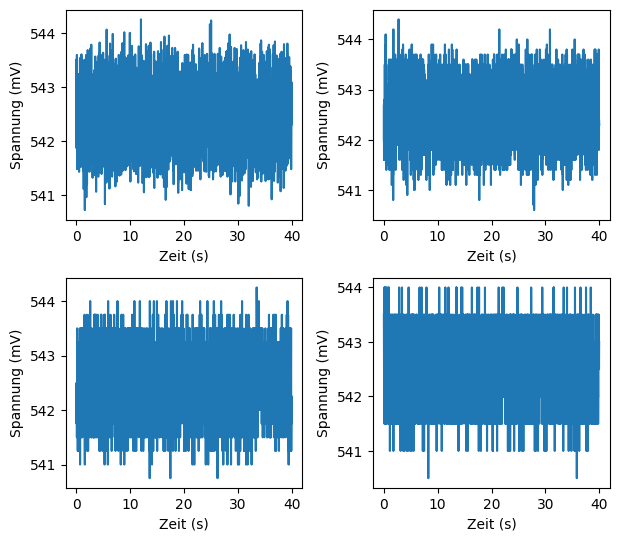

In [1192]:
cm = 1 / 2.54  # Zoll zu Centimeter
fig = plt.figure(figsize=(16*cm, 14*cm))

ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)
ax4 = fig.add_subplot(2, 2, 4)

# Die Zeitachse ist jeweils in der ersten Spalte, die gemessene Spannung in der zweiten Spalte.
ax1.plot(data_res1[:, 0], data_res1[:, 1])
ax2.plot(data_res2[:, 0], data_res2[:, 1])
ax3.plot(data_res3[:, 0], data_res3[:, 1])
ax4.plot(data_res4[:, 0], data_res4[:, 1])

# Da alle Plots gleich sind, können wir die Achsenbeschriftungen etc. auch in einer Schleife generieren!
for ax in [ax1, ax2, ax3, ax4]:
    ax.set_xlabel('Zeit (s)')
    ax.set_ylabel('Spannung (mV)')
    
fig.tight_layout()

## b)

Bestimmen Sie zu jeder Messung die Auflösung in der Signalgrösse (hier Spannung). Nützliche Funktionen hierfür sind z.B. `np.diff`, `np.sort` und `np.min`.

### Lösung

Die Signalauflösung entspricht der kleinsten Differenz zwischen zwei verschiedenen Messwerten. Wenn wir die Messdaten sortieren, entspricht dies wiederum der kleinsten Differenz zwischen zwei verschiedenen aufeinanderfolgenden Werten. Wir sortieren also zuerst die Daten, nehmen dann die Differenzen, und sortieren diese erneut. Es ist immer hilfreich, so etwas erst einmal zu visualisieren.

In [1193]:
# Probieren wir es erst mal mit einem Datensatz
measured_values = data_res1[:, 1]

# Array sortieren
sorted_values = np.sort(measured_values)

# Berechne die Differenzen zwischen aufeinanderfolgenden Werten.
differences = np.diff(sorted_values)

# Absolute Differenzen sortieren, da wir die kleinste Differenz zwischen verschiedenen Messwerten suchen
sorted_differences = np.sort(np.abs(differences))

Text(0, 0.5, 'Differenz (mV)')

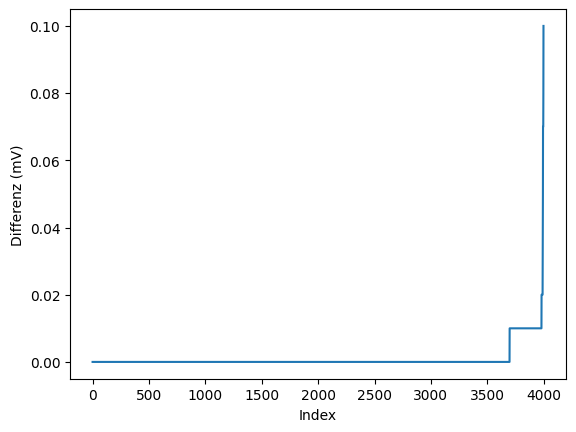

In [1194]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.plot(sorted_differences)
ax.set_xlabel('Index')
ax.set_ylabel('Differenz (mV)')

Wir sehen, dass die meisten Differenzen beinahe Null sind. Das liegt daran, dass natürlich auch mehrmals der gleiche Wert gemessen werden kann. Wir sind am ersten Wert interessiert, der nicht Null ist. Hier kann man das schon ziemlich gut aus dem Plot ablesen und vermuten, dass die Auflösung 0.01 mV ist. Wir können den Wert auch auslesen:

In [1195]:
# Wähle manuell den Index 3800 anhand des Plots aus.
print('Resolution: {:.3f} mV'.format(sorted_differences[3800])) 

Resolution: 0.010 mV


Man könnte das ganze für alle vier Datensätze wiederholen, oder auch eine Funktion schreiben, die das ganze automatisch macht.

In [1196]:
def extract_resolution(measured_values):
    '''Extract smallest difference between two unique values in an array.
    Values are treated as unique if their absolute difference is greater than the tolerance.'''
    # Array sortieren
    sorted_values = np.sort(measured_values)
    
    # Berechne die Differenzen zwischen aufeinanderfolgenden Werten.
    differences = np.diff(sorted_values)
    
    # Viele der Differenzen werden (beinahe) Null sein, weil der gleiche Wert mehrmals
    # gemessen worden ist. Wir suchen die kleinste Differenz, die nicht Null ist.
    # Absolute Differenzen sortieren
    sorted_differences = np.sort(np.abs(differences))
    
    # Wir initialisieren die Variable 'resolution' mit einem negativen Wert, damit wir falls etwas
    # schiefgeht eine negative Auflösung bekommen und es merken (z.B. wenn die Toleranz zu gross ist).
    resolution = -1
    
    tolerance = np.max(np.abs(measured_values)) * 1e-10  # Siehe unten für die Erklärung hierzu
    for diff in sorted_differences:
        if diff > tolerance:
            resolution = diff
            break  # for-Schleife unterbrechen
    
    # Das Minimum der Differenzen ist die Auflösung
    return resolution


res1 = extract_resolution(data_res1[:, 1])
res2 = extract_resolution(data_res2[:, 1])
res3 = extract_resolution(data_res3[:, 1])
res4 = extract_resolution(data_res4[:, 1])

print('Messung 1: dV = {:.4f} mV'.format(res1))
print('Messung 2: dV = {:.4f} mV'.format(res2))
print('Messung 3: dV = {:.4f} mV'.format(res3))
print('Messung 4: dV = {:.4f} mV'.format(res4))

Messung 1: dV = 0.0100 mV
Messung 2: dV = 0.1000 mV
Messung 3: dV = 0.2500 mV
Messung 4: dV = 0.5000 mV


Um die kleinste Differenz zu finden, die nicht Null ist, ist zu beachten, dass man die Gleichheit von zwei Gleitkommazahlen nicht direkt testen sollte; stattdessen testet man, ob die Differenz kleiner ist als eine gewählte Toleranz. (Mit diesen Daten würde auch ein direkter Vergleich funktionieren, aber nicht im Allgemeinen).

Beispiel:

In [1197]:
# Zwei Gleitkommazahlen
a = np.exp(1)
b = np.exp(2) / np.exp(1)
# a und b sollten den gleichen Wert haben
print('a = {:f}, b = {:f}'.format(a, b))

# Falscher Vergleich:
print('a == b: {}'.format(a == b))

# Richtiger Vergleich, Toleranz = 1e-6:
tolerance = 1e-6
print('np.abs(a - b) < {:.1e}: {}'.format(tolerance, np.abs(a - b) < tolerance))

a = 2.718282, b = 2.718282
a == b: False
np.abs(a - b) < 1.0e-06: True


Wie gross die Toleranz ist, hängt von den Werten ab, die verglichen werden: Wenn die Toleranz zu gross ist, wird der Vergleich unpräzise. Wenn die Toleranz zu klein ist, stösst man an die Grenzen der Maschinenpräzision und erhält wieder das falsche Resultat (probieren Sie z.B. tolerance = 1e-35 im Beispiel oben).

Für das Beispiel mit den Messdaten wurde die Toleranz relativ zu dem Messwerten gewählt: Zehn Grössenordnungen kleiner als der grösste Messwert. Das ist deswegen sinnvoll, weil durch die Digitalisierung das Verhältnis von grösstem messbaren Wert zur Auflösung limitiert ist (vgl. dynamic range, später in der Vorlesung).

## c)

Plotten Sie nochmal die Daten, und beschriften Sie die Plots mit der zugehörigen Signalauflösung. Da die Punkte auf der x-Achse sehr dicht beieinander liegen, lässt sich nicht viel erkennen. Schauen Sie sich deswegen kleinere Bereiche auf der x-Achse an, z.B. 10 Sekunden, 5 Sekunden, 1 Sekunde, 0.1 Sekunden... Können Sie eine Struktur erkennen? Wie wirkt sich die Auflösung aus?

### Lösung

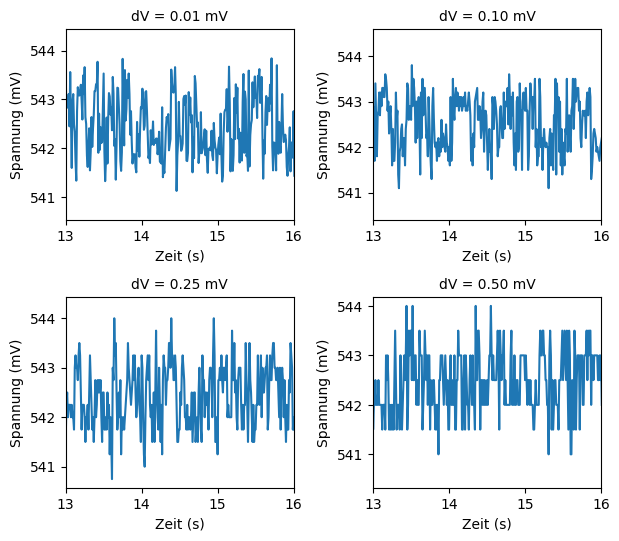

In [1198]:
cm = 1 / 2.54  # Zoll zu Centimeter
fig = plt.figure(figsize=(16*cm, 14*cm))

ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)
ax4 = fig.add_subplot(2, 2, 4)

ax1.plot(data_res1[:, 0], data_res1[:, 1])
ax2.plot(data_res2[:, 0], data_res2[:, 1])
ax3.plot(data_res3[:, 0], data_res3[:, 1])
ax4.plot(data_res4[:, 0], data_res4[:, 1])

# Berechnete Auflösungen aus b)
ax1.set_title('dV = {:.2f} mV'.format(res1), size=10)
ax2.set_title('dV = {:.2f} mV'.format(res2), size=10)
ax3.set_title('dV = {:.2f} mV'.format(res3), size=10)
ax4.set_title('dV = {:.2f} mV'.format(res4), size=10)

# Da alle Plots gleich sind, können wir die Achsenbeschriftungen etc. auch in einer Schleife generieren!
for ax in [ax1, ax2, ax3, ax4]:
    ax.set_xlabel('Zeit (s)')
    ax.set_ylabel('Spannung (mV)')
    
    # Zoom in der x-Achse
    ax.set_xlim(13, 16)
    
fig.tight_layout()

Wenn man auf einen Bereich von wenigen Sekunden zoomt, kann man schon vermuten, dass die Datenpunkte nicht normalverteilt sind: es zeichnen sich Sprünge zwischen zwei Spannungswerten 542 mV und 543 mV ab. Bei den Auflösungen von 0.25 mV und 0.5 mV kann man dies allerdings nicht mehr erkennen, da die Diskretisierung der Werte durch das Messgerät schon zu grosse Sprünge erzeugt.

## d)

Erstellen Sie ein Histogramm für jede Messung und plotten Sie es. Um das Histogramm zu berechnen, können Sie `np.histogram()`, und um es in der gewohnten Balken-Form zu plotten `ax.bar()` verwenden. Die Grösse der Bins hat einen grossen Einfluss auf das Histogramm. Wählen Sie verschiedene Bingrössen aus, die für kleine oder grosse Signalauflösungen optimiert sind. Was passiert, wenn Sie die Bingrösse kleiner als die Auflösung wählen?

Die Syntax der Funktionen finden Sie wieder mit der Hilfe Funktion: `np.histogram?` und `ax.bar?`. Alternativ können Sie auf die Hyperlinks am Anfang des Übungsblattes klicken, um zur Online-Dokumentation zu gelangen.

Um den Zusammenhang zwischen Signalauflösung und Bingrösse zu veranschaulichen, können Sie immer alle vier Histogramme mit derselben Bingrösse plotten, und dann verschiedene Werte für die Bingrösse ausprobieren.

### Lösung

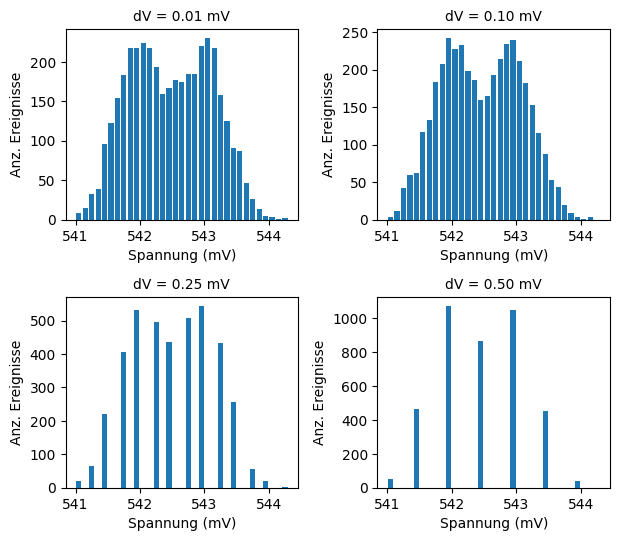

In [1199]:
# Wir wählen eine fixe Bingrösse für alle vier Histogramme.
# Verändern Sie diesen Wert, um sich zu veranschaulichen, was mit den Histogrammen passiert.
binsize = 0.1

# Histogramme erzeugen
bin_edges = np.arange(541, 544.4, binsize)
bin_centers = bin_edges[:-1] + 0.5 * binsize
hist1, _ = np.histogram(data_res1[:, 1], bins=bin_edges)
hist2, _ = np.histogram(data_res2[:, 1], bins=bin_edges)
hist3, _ = np.histogram(data_res3[:, 1], bins=bin_edges)
hist4, _ = np.histogram(data_res4[:, 1], bins=bin_edges)

# Plots
cm = 1 / 2.54  # Zoll zu Centimeter
fig = plt.figure(figsize=(16*cm, 14*cm))

ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)
ax4 = fig.add_subplot(2, 2, 4)

ax1.bar(bin_centers, hist1, width=binsize*0.8)
ax2.bar(bin_centers, hist2, width=binsize*0.8)
ax3.bar(bin_centers, hist3, width=binsize*0.8)
ax4.bar(bin_centers, hist4, width=binsize*0.8)

ax1.set_title('dV = {:.2f} mV'.format(res1), size=10)
ax2.set_title('dV = {:.2f} mV'.format(res2), size=10)
ax3.set_title('dV = {:.2f} mV'.format(res3), size=10)
ax4.set_title('dV = {:.2f} mV'.format(res4), size=10)

for ax in [ax1, ax2, ax3, ax4]:
    ax.set_xlabel('Spannung (mV)')
    ax.set_ylabel('Anz. Ereignisse')

fig.tight_layout()

Geeignete Bingrössen sind z.B. 0.05 mV, 0.1 mV, 0.25 mV, 0.5 mV. Man kann folgendes beobachten:

- Wenn die Bingrösse kleiner als die Signalauflösung ist, gibt es leere Bins. Insbesondere wenn die Bingrösse ähnlich aber nicht gleich der Signalauflösung ist, gibt es merkwürdige Artefakte wie einzelne fehlende Balken im Histogramm (probieren Sie z.B. 0.2 mV als Bingrösse).
- Mit den Auflösungen 0.01 mV und 0.1 mV ist deutlich eine bimodale Verteilung zu sehen (d.h. eine Verteilung mit zwei Maxima). Bei 0.25 mV und 0.5 mV kann man nicht mehr zwischen einer bimodalen Verteilung und einer Normalverteilung mit Rauschen unterscheiden.

## e)

Welche Auflösung würden Sie für diese Messung wählen? Wie hängt die benötigte Auflösung mit den charakteristischen Grössen der Verteilung der Messwerte (z.B. Streuung) zusammen?

### Lösung

Die Auflösung von 0.1 mV ist für diese Messung ausreichend, während 0.25 mV nicht genügt. Mit der noch kleineren Auflösung von 0.01 mV kann man die Messung natürlich auch durchführen, aber man gewinnt dadurch nicht mehr viel Information: Die Auflösung 0.1 mV ist schon kleiner als die Streuung und der Abstand der beiden Moden und reicht damit aus um die Verteilung der Messwerte zu charakterisieren.

# Aufgabe 2: Oszillierendes Signal und Samplingrate

Nun schauen wir uns den Einfluss der Samplingrate, d.h. der zeitlichen Auflösung, auf die Messung von oszillierenden Signalen an. Sie finden die Datensätze zu dieser Aufgabe im Ordner "Aufgabe 2".

## a)

Lesen Sie zuerst den Datensatz 'osc_data_1.txt' ein und bestimmen Sie die Samplingrate. Plotten Sie das Signal als Funktion der Zeit. Verwenden Sie im Plot Marker (z.B. Kreuze oder Punkte), um die Datenpunkte zu markieren.

### Lösung

In [1200]:
# Daten einlesen
data1 = np.loadtxt('data/osc_data.txt', delimiter=',', comments='#')
time1 = data1[:, 0]
signal1 = data1[:, 1]

# Samplerate: 1 / dt, wobei dt die Zeitdifferenz zwischen zwei Datenpunkten ist.
sample_rate = 1 / (time1[1] - time1[0])

(0.0, 0.1)

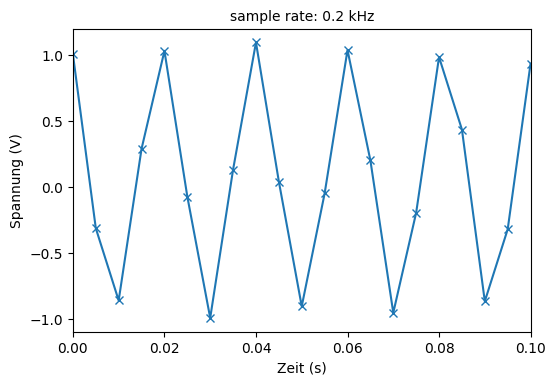

In [1201]:
# Daten Potten
cm = 1 / 2.54  # Zoll zu Centimeter
fig = plt.figure(figsize=(15*cm, 10*cm))
ax = fig.add_subplot(1, 1, 1)
ax.plot(time1, signal1, 'x-')
ax.set_xlabel('Zeit (s)')
ax.set_ylabel('Spannung (V)')
ax.set_title('sample rate: {:.1f} kHz'.format(sample_rate * 1e-3), size=10)

# Wir schauen auf einen kleineren Zeitbereich, um die Oszillation besser zu sehen.
ax.set_xlim(0, 0.1)

## b)

Lesen Sie die Oszillationsfrequenz des Signals aus Ihrem Plot ab.

### Lösung

Aus dem Plot kann man die periode von ca. 0.02 s ablesen -> f = 1 / 0.02s = 50 Hz.

## c)

Lesen Sie nun die Datei 'osc_data_2.txt' ein, bestimmen Sie die Samplingrate, plotten Sie das Signal, und bestimmen Sie die Frequenz.

### Lösung

(0.0, 0.1)

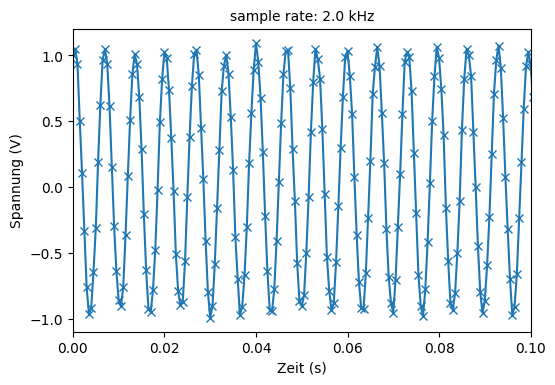

In [1202]:
# Daten einlesen
data2 = np.loadtxt('data/osc_data_2.txt', delimiter=',', comments='#')
time2 = data2[:, 0]
signal2 = data2[:, 1]

# Samplerate: 1 / dt, wobei dt die Zeitdifferenz zwischen zwei Datenpunkten ist.
sample_rate2 = 1 / (time2[1] - time2[0])

# Daten Potten

cm = 1 / 2.54  # Zoll zu Centimeter
fig = plt.figure(figsize=(15*cm, 10*cm))
ax = fig.add_subplot(1, 1, 1)
ax.plot(time2, signal2, 'x-')
ax.set_xlabel('Zeit (s)')
ax.set_ylabel('Spannung (V)')
ax.set_title('sample rate: {:.1f} kHz'.format(sample_rate2 * 1e-3), size=10)

ax.set_xlim(0, 0.1)
# Zoom zum bestimmen der Frequenz
# ax.set_xlim(0, 0.01)

In [1203]:
# Frequenz aus der abgelesenen Periode berechnen
print(1 / 0.0065)

153.84615384615384


Aus dem Plot können wir eine Periode von etwa 6.5 ms ablesen, was einer Frequenz von ca 154 Hz entspricht.

## d)

Plotten Sie beide Datensätze im selbem Plot. Was stellen Sie fest?

### Lösung

(0.0, 0.1)

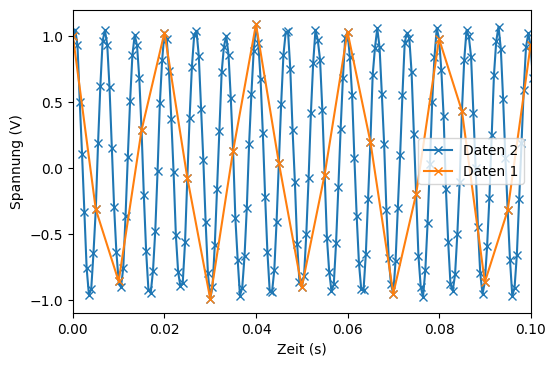

In [1204]:
cm = 1 / 2.54  # Zoll zu Centimeter
fig = plt.figure(figsize=(15*cm, 10*cm))
ax = fig.add_subplot(1, 1, 1)
ax.plot(time2, signal2, 'x-', label='Daten 2')
ax.plot(time1, signal1, 'x-', label='Daten 1')
ax.set_xlabel('Zeit (s)')
ax.set_ylabel('Spannung (V)')
ax.legend()

ax.set_xlim(0, 0.1)

Alle Punkte aus dem ersten Datensatz überlappen genau mit Punkten aus dem zweiten Datensatz. Das heisst, wenn die schnelle Oszillation (151.34 Hz) mit der langsamen Samplingrate gemessen wird, kann man sie nicht von einer langsameren Oszillation mit etwa 50 Hz unterschieden. Tatsächlich sind die überlappenden Punkte hier identisch, weil der Datensatz 1 aus dem Datensatz 2 generiert wurde, indem nur jeder zehnte Punkt verwendet wurde.

Wenn also ein oszillierendes Signal mit einer zu langsamen Samplingrate gemessen wird, ist nicht nur die echte Oszillationsfrequenz nicht messbar, sie kann sogar wie eine Oszillation mit langsamerer Frequenz erscheinen.

## Freiwillige Zusatzaufgabe: Frequenz automatisch bestimmen

In Aufgaben b) und c) haben Sie die ungefähre Frequenz von Auge aus dem Plot abgelesen. Überlegen Sie sich, wie Sie die Frequenz programmatisch aus dem Signal bestimmen könnten, und versuchen Sie Ihren Algorithmus zu implementieren.

Da wir erst später in der Vorlesung genauer auf die Analyse von oszillierenden Signalen zu sprechen kommen, brauchen Sie sich keine Gedanken zu machen, wenn Sie diese Aufgabe nicht bearbeiten möchten.

### Lösung

In [1205]:
# Hier eine Implementation eines einfachen Algorithmus zur Bestimmung der Frequenz mit den Mitteln,
# die Sie in dieser Vorlesung bereits kennengelernt haben. Diese Methode ist nicht besonders robust und
# versagt, wenn es Rauschen auf den Daten gibt.
def get_frequency(time, signal):
    '''Find frequency of an oscillatory signal by calculating the mean distance between local maxima
    in the signal.'''
    n_points = len(time)

    period_sum = 0  # Speichert die Summe der Perioden
    n_period = 0  # Speichert die Anzahl der berechneten Perioden für das Mitteln: period = period_sum / n_period
    prev_max_index = 0  # Speichert den Index des letzten Maximums.
    
    # Als erstes suchen wir das erste lokale Maximum im Signal.
    for i in range(1, n_points-2):
        if signal[i-1] < signal[i] and signal[i+1] < signal[i]:
            prev_max_index = i
            break
    
    # In einer for-Schleife iterieren wir vom ersten Punkt nach dem ersten Maximum bis zum vorletzten Punkt,
    # weil wir jeden Punkt mit seinen Nachbarpunkten vergleichen wollen.
    for i in range(prev_max_index+1, n_points-2):
        # Wir suchen lokale Maxima, d.h. Punkte, die grösser sind als beide Nachbarpunkte.
        if signal[i-1] < signal[i] and signal[i+1] < signal[i]:
            # Wenn wir ein Maximum finden, addieren wir die Zeitdifferenz zum letzten Maximum
            # zu der period_sum variable, und erhöhen die Anzahl der addierten Zeitdifferenzen um eins.
            period_sum += time[i] - time[prev_max_index]
            n_period += 1
            
            # Ausserdem müssen wir den Index zum letzten Maximum updaten.
            prev_max_index = i
    
    
    # Mittelwert berechnen und Frequenz zurückgeben.
    period = period_sum / n_period
    return 1 / period


print('Frequenz 1: {:.2f} Hz'.format(get_frequency(time1, signal1)))
print('Frequenz 2: {:.2f} Hz'.format(get_frequency(time2, signal2)))

Frequenz 1: 48.89 Hz
Frequenz 2: 151.36 Hz


In [1206]:
# Eine andere Möglichkeit basierend auf der gleichen Idee wäre, die Funktion argrelmax aus der
# Bibliothek scipy.signal zu verwenden. Diese Funktion findet die Indizes aller lokalen Maxima eines Arrays.
# Die Funktion hat das Argument 'order', was angibt, wie viele Punkte in der Nachbarschaft beim bestimmen
# der lokalen Maxima berücksichtigt werden, was den Algorithmus ein bisschen stabiler gegen Rauschen macht.
import scipy.signal

def get_frequency_scipy(time, signal):
    '''Find frequency of an oscillatory signal by calculating the mean distance between local maxima
    in the signal using scipy.signal.argrelmax'''
    max_indices = scipy.signal.argrelmax(signal, order=3)[0]
    n_period = len(max_indices) - 1
    period_sum = 0
    
    for i in range(0, n_period):
        period_sum += time[max_indices[i+1]] - time[max_indices[i]]
        
    period = period_sum / n_period
    return 1 / period


print('Frequenz 1: {:.2f} Hz'.format(get_frequency_scipy(time1, signal1)))
print('Frequenz 2: {:.2f} Hz'.format(get_frequency_scipy(time2, signal2)))

Frequenz 1: 48.94 Hz
Frequenz 2: 151.36 Hz


Eine bessere Methode, die auch mit verrauschten Daten funktioniert, beruht auf Fouriertransformation. Sie werden diese später in der Vorlesung kennenlernen.

---

# Aufgabenblatt 3 - Musterlösung

In [1207]:
import numpy as np

# Aufgabe 1 - Mittelwert und Standardabweichung
## **Hintergrund: Python Funktionen**

Funktionen sind ein fundamentales Tool beim Schreiben von Code. Im Folgenden wollen wir eine kleine Einführung zu Funktionen in Python geben. Sie ist gezielt einfach und kurz gehalten, beinhaltet aber alles, was Sie für den Start benötigen.  Die Definition einer Python-Funktion beginnt mit `def`, gefolgt vom Funktionsnamen und, falls benötigt, den zu übergebenden Argumenten in der Klammer. Analog zu for-Schleifen ist der zur Funktion gehörende Code dadurch definiert, dass er eingerückt ist:

```
def function_name(parameter1, parameter2, default_argument=standard_value):
	"""Docstring"""
    # some code
	return return_value1, return_value2
```
    
Dabei können `parameter1`, `parameter2` und `default_argument` beliebige Datentypen sein, z.B. `int`, `np.ndarray`, `str`, etc. Der Unterschied zwischen `default_argument` und `parameter1` oder `parameter2` ist, dass Default Arguments einen Standardwert haben. In der Funktionsdefinition müssen Default Arguments immer **nach** Non-Default Arguments geschrieben werden. Das `return` statement ist nur notwendig, wenn man einen Wert zurückgeben will, und kann ansonsten weggelassen werden. Es können eine oder mehrere mit Kommas separierte Variablen ausgegeben werden, und sie können beliebige Datentypen annehmen.
 
Beim Aufrufen oder Ausführen der Funktion können die Parameter entweder positional oder mit Hilfe von Keywords übergeben werden. Bei der positionalen Übergabe werden die Übergabeparameter in der Reihenfolge, in der die Parameter in der Funktionsdefinition geschrieben sind, übergeben. Bei einem Aufruf `function_name(1,2)` beispielsweise hat also `parameter1` den Wert `1`, `parameter2` den Wert `2` und `default_argument` den Standardwert `standard_value`. Bei der Übergabe mit Keywords kann man die Reihenfolge der Parameter im Aufruf frei wählen, also z. B. `function_name(parameter2='hello!', default_argument=5, parameter1=3.141)`. Man kann die beiden Übergabemethoden auch in einem Aufruf mischen, dann muss man jedoch zuerst alle positionalen Parameter (in der richtigen Reihenfolge) und dann die Keyword Parameter übergeben.

Im Folgenden sind einige einfache Funktionen aufgeführt, die die Funktionsweise illustrieren sollten.


In [1208]:
def simple_print():
    print('Always the same.')

def print_input(text):
    print('Prints: {:s}'.format(text))

def linear_function(x, a):
    y = x * a
    return y 

# Die erste Funktion braucht kein Argument:
simple_print()

# Die zweite Funktion verwended das Argument:
print_input('This')
text = 'Or that'
print_input(text)

# Die dritte Funktion gibt 
x = 5
y = linear_function(x, 2)
print(y)
x = np.linspace(0, 3, 3)
y = linear_function(x, 2)
print(y)

Always the same.
Prints: This
Prints: Or that
10
[0. 3. 6.]


In [1209]:
def print_param(param1, param2, param3=3, param4=4):
    print('Param1: {:d}; Param2: {:d}, Param3: {:d}, Param4: {:d}'.format(param1, param2, param3, param4))

# Wir können die Standardwerte für die Default Argumente benutzen:
print_param(1, 2)
# Die Reihenfolge der Parameter ist entscheidend
print_param(2, 1)
# Wir können Default Argumente positional übergeben
print_param(1, 2, 3, 4)
# Oder als Keyword
print_param(1, 2, param4=8)
# Oder wir können Non-Default Parameter als Keyword übergeben
print_param(param2=2, param1=1)

Param1: 1; Param2: 2, Param3: 3, Param4: 4
Param1: 2; Param2: 1, Param3: 3, Param4: 4
Param1: 1; Param2: 2, Param3: 3, Param4: 4
Param1: 1; Param2: 2, Param3: 3, Param4: 8
Param1: 1; Param2: 2, Param3: 3, Param4: 4


Eine Besonderheit von Python-Funktionen ist, dass sie auch auf Variablen ausserhalb der Funktionsdefinition zugreifen können. Dies kann ein verlockend einfacher Weg sein Variablen an eine Funktion zu übergeben, es ist aber ratsam, die benötigten Variablen über die Funktionsdefinition zu übergeben. Besonders bei verschachtelten Codes kann es schnell vorkommen, dass eine Funktion nicht mehr macht was sie soll, weil eine Variable ausserhalb der Funktionsdefinition geändert wurde.

In [1210]:
a = 5 
def print_a():
    print(a)
    
print_a()
a= 4
print_a()

5
4


## **Aufgabe 1: Mittelwert und Standardabweichung**

a.) Schreiben Sie selbst eine Funktion, die den Mittelwert und die Standardabweichung von einem Array berechnet. Nutzen Sie dafür keine importierten Packages ausser `np.sqrt()`, sondern ausschliesslich die built-in Funktionen und Methoden wie `for`, `len()`, etc.

### Lösung:
Die Definition von Mittelwert und Standardabweichung ist:

$\mu = \frac{1}{N}\Sigma x_i$

$\sigma = \sqrt{\frac{1}{N}\Sigma(x_i-\mu)^2}$

In [1211]:
def mean(x):
    # Die Anzahl Werte in x
    N = len(x)
    # Wir definieren zuerst eine Variable, mit der wir die Werte aufaddieren, und initialisieren sie mit 0.
    summation = 0
    # in einer for-Schleife addieren wir jeden Wert zu den Vorhergehenden
    for i in range(N):
        summation += x[i]
    # Zum Schluss teilen wir noch durch die Anzahl der Werte. 
    mean = summation/N
    return mean


def std(x):
    # Wir berechnen zuerst den Mittelwert wie oben
    sumation = 0
    for i in range(len(x)):
        sumation += x[i]
    mean = sumation/len(x)
    # Wir definieren eine Variable, um die Differenzen  mit dem Mittelwert zu summieren.
    diff = 0
    # Wir summieren über alle Differenzen 
    for i in range(len(x)):
        diff += (x[i]-mean)**2
    # Schlussendlich müssen wir noch durch N teilen und die Wurzel ziehen. 
    std = np.sqrt(diff/len(x))
    return std

b.) Überprüfen Sie nun die selbstgeschriebenen Funktionen mit den numpy Funktionen `np.mean()` und `np.std()`, indem Sie den Mittelwert und die Standardabweichung  von zufällig generierten Werten berechnen. Benutzen Sie dazu die Funktion `np.random.rand()`. Hilfe zu den Funktion finden Sie in der Dokumentation mit `np.random.rand?`, `np.mean?` und  `np.std?`.

### Lösung:

In [1212]:
x = np.random.rand(100)
mean_self = mean(x)
std_self = std(x)
mean_np = np.mean(x)
std_np = np.std(x)

print('Die Ergebnisse der selbstgeschriebenen Funkionen sind: {:0.2f} +/- {:.2f}'.format(mean_self, std_self))
print('Die Ergebnisse der numpy Funkionen sind: {:0.2f} +/- {:.2f}'.format(mean_np, std_np))

Die Ergebnisse der selbstgeschriebenen Funkionen sind: 0.48 +/- 0.28
Die Ergebnisse der numpy Funkionen sind: 0.48 +/- 0.28


## **Hintergrund (Wiederholung): Erstellen von Grafen**

Eine der wichtigsten Schritte beim Verarbeiten und Verstehen von Daten ist die grafische Darstellung der Werte. Ein weit verbreitetes Package fürs plotten ist `matplotlib`, es beinhaltet zahlreiche Möglichkeiten beliebig komplizierte Plots zu erstellen. Für die meisten Anwendungen genügt es jedoch aus `matplotlib.pyplot` mit `subplots` eine Figur und die dazugehörigen Achsen zu erstellen, und dann mit `plot` die Werte darzustellen. Zu jedem Plot gehört die Achsenbeschriftung, die mit `ax.set_xlabel` und  `ax.set_ylabel` erstellt werden kann (dazu gehören auch immer die Einheiten der dargestellten Grössen). Um klarzumachen, was dargestellt ist, kann mit `ax.set_title` ein Titel erstellt werden, was insbesondere dann hilfreich ist, wenn es keinen erklärenden Text zum Plot gibt (z.B. hier im Notebook oder in einer Präsentation).

Text(0.5, 1.0, 'Wurfparabel')

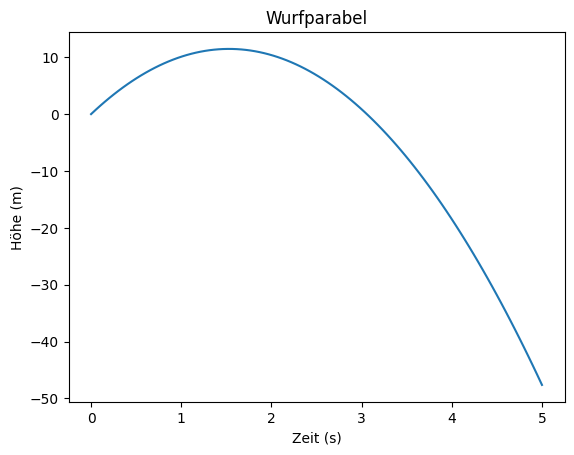

In [1213]:
import matplotlib.pyplot as plt
t = np.linspace(0, 5, 100)
y = 15 * t - 9.81 / 2 * t**2

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.plot(t, y)
ax.set_xlabel('Zeit (s)')
ax.set_ylabel('Höhe (m)')
ax.set_title('Wurfparabel')

## **Aufgabe 2: Histogramm und Rauschen**

a.) Wie bereits in der Vorlesung gezeigt wurde, wollen wir hier das Rauschen in einer Messung genauer anschauen. Laden Sie dazu als erstes den Datensatz `ExampleData.txt`. Der Datensatz beinhaltet eine zeitabhängige Spannung mit den Spalten: $t$, $V$. Plotten Sie die Zeitabhängigkeit der Spannung.


### Lösung

(2, 20000)


Text(0, 0.5, 'V (V)')

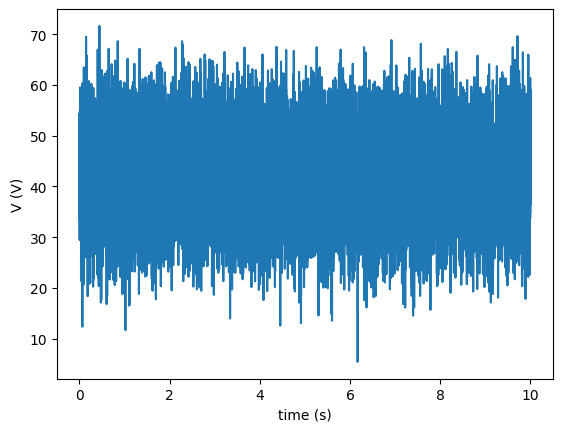

In [1214]:
data = np.loadtxt('data/voltage_timeseries.txt', skiprows=1, delimiter=',')
print(data.shape)

# Wir weisen den 2D Datensatz verschiedenen 1D Arrays zu
t = data[0,:]
V = data[1,:]

fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.plot(t,V)
ax.set_xlabel('time (s)')
ax.set_ylabel('V (V)')


b.) Berechnen Sie Mittelwert und Standardabweichung der Spannung.

### Lösung

In [1215]:
V_mean = np.mean(V)
V_std = np.std(V)

print('V = {:0.3f} +/- {:0.3f} V'.format(V_mean,V_std))


V = 42.019 +/- 7.992 V


c.) Plotten Sie das Histogramm der Spannung. Um das Histogramm zu berechnen, können Sie `np.histogram()`, und um es in der gewohnten Balken-Form zu plotten `ax.bar()` verwenden. Die Grösse der Bins hat einen grossen Einfluss auf das Histogramm. Testen Sie verschiedene Grössen aus! Was sehen Sie?

Die Syntax der Funktionen finden Sie wieder mit der Hilfe Funktionen: `np.histogram?` und `ax.bar?`.

Beachten Sie, dass die Breite der Balken im Plot kleiner als die Bingrösse gewählt werden sollte.

### Lösung

Text(0, 0.5, 'Occurrences')

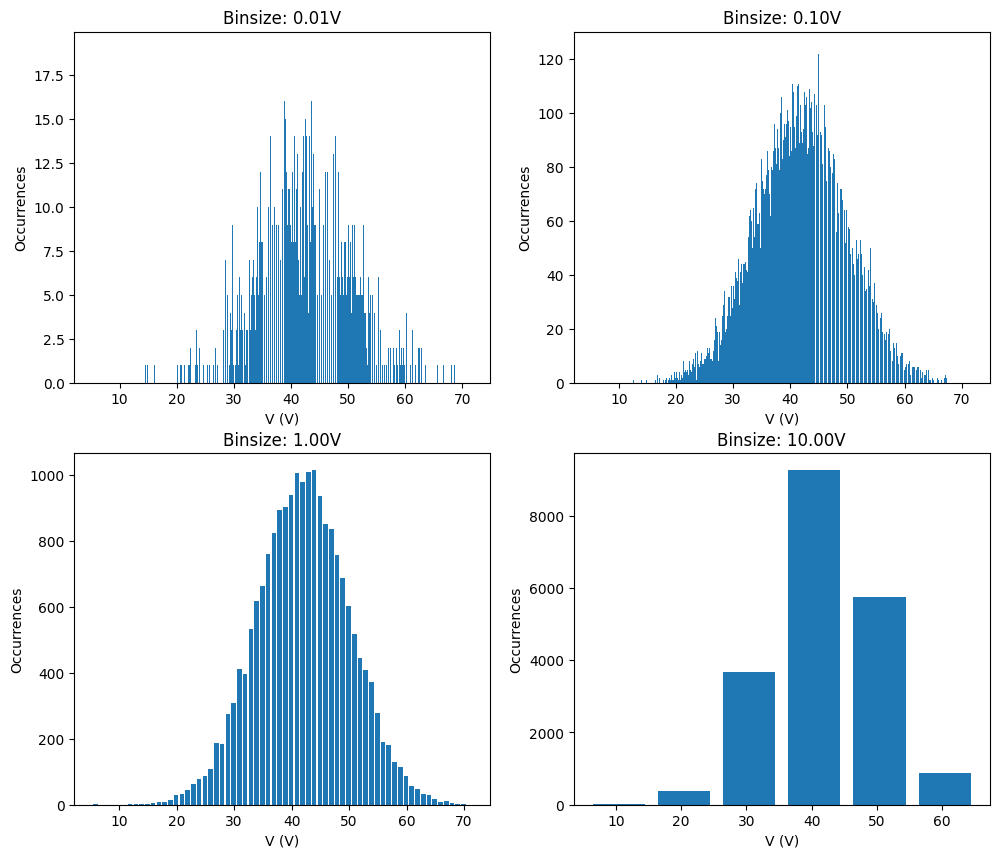

In [1216]:
cm = 0.393701  # Umrechnung Zoll zu Centimeter

# Wir wählen eine Binsize und erstellen dann zuerst die Bins für jede Beschleunigungskomponente.
# Wir suchen dazu das Minimum und das Maximum der vorhandenen Werte
# Anschliessend berechnen wir das Histogramm. 
binsize = 0.01
bin_edges = np.arange(np.min(V), np.max(V), binsize)
# Da die Funktion zwei Werte zurückgibt, wir aber nur am ersten interessiert sind, können
# wir folgende Syntax verwenden, um den zweiten Wert gleich zu verwerfen:
hist, _ = np.histogram(V, bin_edges)
# Das Array 'bin_edges' gibt die Grenzen der Bins an, für den Plot brauchen wir aber die Mitte
# der Bins, um die Balken richtig zu positionieren
bin_centers = bin_edges[:-1] + 0.5 * binsize

# Wir plotten die drei bar plots und wählen die 'width' etwas kleiner als die binsize. 
fig = plt.figure(figsize=(30*cm, 25.5*cm))
ax1 = fig.add_subplot(2,2,1)
ax1.bar(bin_centers, hist, width=0.8*binsize)
ax1.set_title('Binsize: {:.2f}V'.format(binsize))
# Wir wiederholen den Vorgang für verschiedene binsizes.
# Natürlich kannst du hier auch eine Funktion definieren, anstatt den selben Code mehrere mal zu schreiben. 
binsize = 0.1
bin_edges = np.arange(np.min(V), np.max(V), binsize)
hist, _ = np.histogram(V, bin_edges)
bin_centers = bin_edges[:-1] + 0.5 * binsize

ax2 = fig.add_subplot(2,2,2)
ax2.bar(bin_centers, hist, width=0.8*binsize)
ax2.set_title('Binsize: {:.2f}V'.format(binsize))

binsize = 1
bin_edges = np.arange(np.min(V), np.max(V), binsize)
hist, _ = np.histogram(V, bin_edges)
bin_centers = bin_edges[:-1] + 0.5 * binsize

ax3 = fig.add_subplot(2,2,3)
ax3.bar(bin_centers, hist, width=0.8*binsize)
ax3.set_title('Binsize: {:.2f}V'.format(binsize))


binsize = 10
bin_edges = np.arange(np.min(V), np.max(V), binsize)
hist, _ = np.histogram(V, bin_edges)
bin_centers = bin_edges[:-1] + 0.5 * binsize

ax4 = fig.add_subplot(2,2,4)
ax4.bar(bin_centers, hist, width=0.8*binsize)
ax4.set_title('Binsize: {:.2f}V'.format(binsize))

ax1.set_xlabel('V (V)')
ax2.set_xlabel('V (V)')
ax3.set_xlabel('V (V)')
ax4.set_xlabel('V (V)')
ax1.set_ylabel('Occurrences')
ax2.set_ylabel('Occurrences')
ax3.set_ylabel('Occurrences')
ax4.set_ylabel('Occurrences')


d.) Zuletzt plotten Sie nochmals das Histogramm mit einer sinnvollen Bin-Grösse, und zeichnen Sie den Mittelwert sowie die Standardabweichung ein. Hierzu können Sie die Funktion `ax.axvline` des Achsenobjekts verwenden.


Text(0.5, 1.0, 'Binsize: 1.00V')

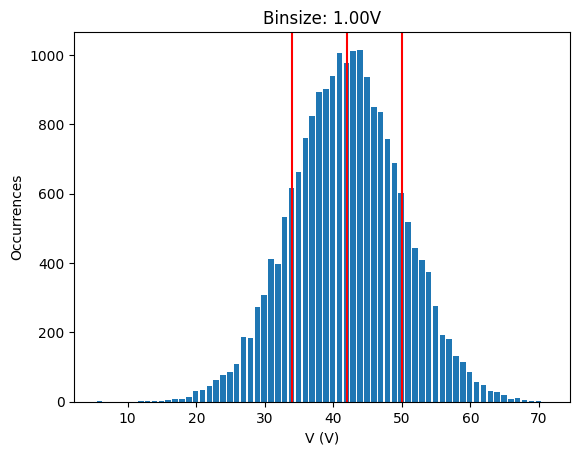

In [1217]:
binsize = 1
bin_edges = np.arange(np.min(V), np.max(V), binsize)
hist, _ = np.histogram(V, bin_edges)
bin_centers = bin_edges[:-1] + 0.5 * binsize

fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.bar(bin_centers, hist, width=0.8*binsize)
ax.axvline(V_mean, color='r')
ax.axvline(V_mean-V_std, color='r')
ax.axvline(V_mean+V_std, color='r')

ax.set_xlabel('V (V)')
ax.set_ylabel('Occurrences')
ax.set_title('Binsize: {:.2f}V'.format(binsize))

## **Zusatzaufgabe: Zentraler Grenzwertsatz**

Wie in der Vorlesung gezeigt wurde, ergibt eine additive Überlagerung unabhängiger Zufallseffekte im Gesamten zumindest Näherungsweise eine Normalverteilung. In der Vorlesung wurde dies anhand von Würfeln gezeigt, hier versuchen wir das Ergebnis mit (virtuellen) Münzen zu reproduzieren. Hierzu weisen wir Kopf und Zahl einfach zwei Zahlenwerte zu, 0 und 1. 

a) Generieren Sie als erstes die Zufallswerte für den Münzwurf. Dazu eignet sich z.B. `np.random.randint()`. Werfen Sie dafür gleichzeitig N Münzen und schauen Sie sich das Histogramm der Ergebnisse an. Wählen Sie dabei N gross genug, um zu überprüfen ob beide möglichen Werte gleich oft vorkommen.

### Lösung:

Text(0.5, 1.0, 'Tossing 2000 coins')

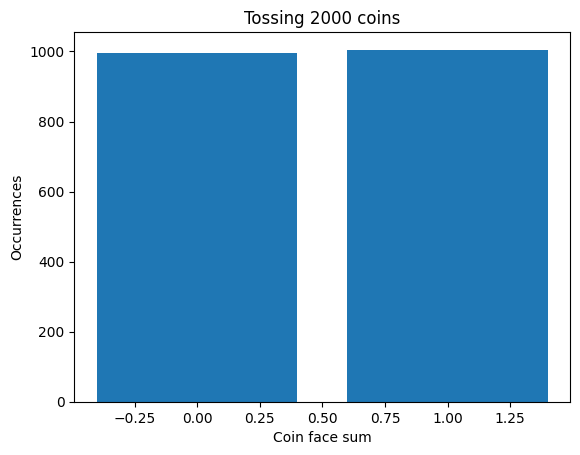

In [1218]:
Ncoins = 2000
coin = np.random.randint(0, 2, Ncoins)
bin_edges = np.array([-.5, .5, 1.5])  # die Ränder der Bins, zentriert um die Werte 0 und 1.
hist, _ = np.histogram(coin, bin_edges)
bin_centers = [0, 1]

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.bar(bin_centers, hist, width=0.8)

ax.set_xlabel('Coin face sum')
ax.set_ylabel('Occurrences')
ax.set_title('Tossing {:d} coins'.format(Ncoins))

b) Wiederholen Sie als nächstes dieses Experiment M-mal, und summieren Sie für jede der N Münzen die M Ergebnisse auf. Plotten Sie dann das Histogramm der Summen und die dazugehörige (skalierte) Normalverteilung

$p(x) = \frac{N}{\sqrt{2\pi\sigma^2}}e{\frac{-(x-\mu)^2}{2\sigma^2}}$.

Vergleichen Sie es für verschiedene Anzahl Wiederholungen.

### Lösung

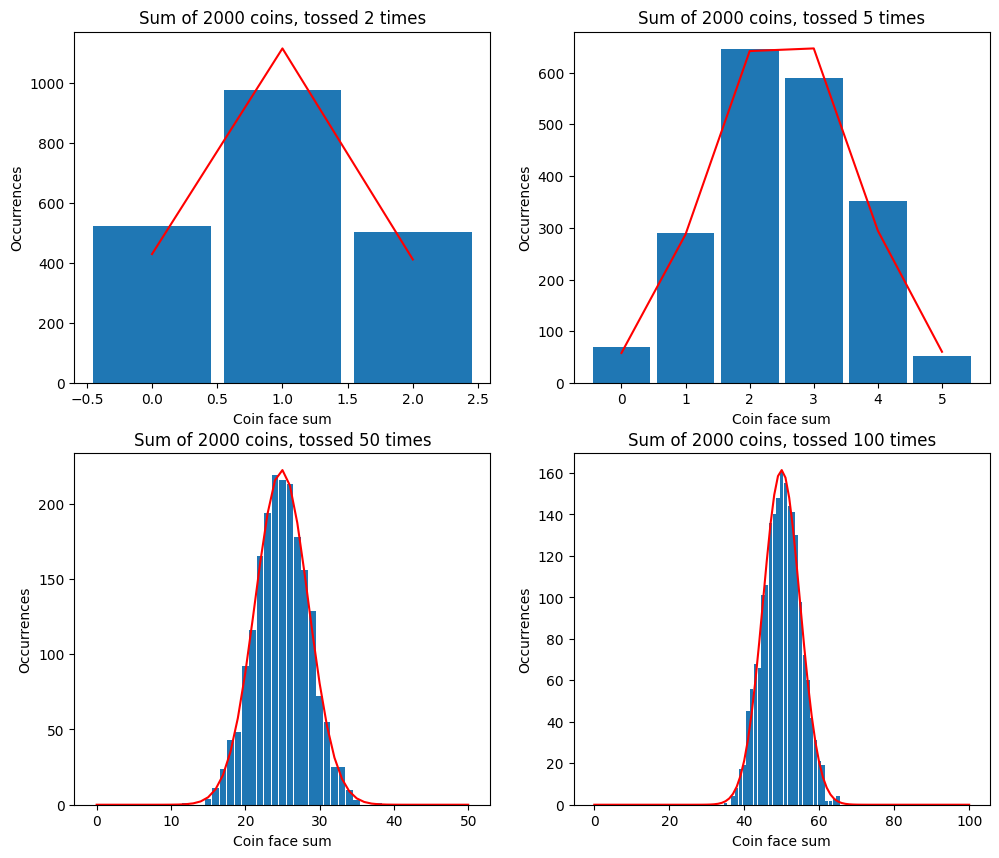

In [1219]:
cm = 0.393701  # Umrechnung Zoll zu Centimeter

Ncoins = 2000
Mtosses = np.array([2, 5, 50, 100])
fig = plt.figure(figsize=(30*cm, 25.5*cm))

for i in range(len(Mtosses)):
    s = np.zeros(Ncoins, dtype=int)
    
    for j in range(Mtosses[i]):
        s = s + np.random.randint(0,2, Ncoins)

    bin_edges = np.arange(0, Mtosses[i]+2) - 0.5
    hist, _ = np.histogram(s, bin_edges)
    bin_centers = np.arange(0, Mtosses[i]+1)
    
    mean = np.mean(s)
    var = np.var(s)
    gauss = Ncoins / np.sqrt(2 * np.pi * var) * np.exp(-(bin_centers - mean)**2 / (2 * var))

    ax = fig.add_subplot(2, 2, i+1)
    ax.bar(bin_centers, hist, width=(bin_centers[1] - bin_centers[0])*0.9)
    ax.plot(bin_centers, gauss, color='r')
    ax.set_xlabel('Coin face sum')
    ax.set_ylabel('Occurrences')
    ax.set_title('Sum of {:d} coins, tossed {:d} times'.format(Ncoins, Mtosses[i]))

---

# Aufgabenblatt 4 - Lösung

In [1220]:
import numpy as np
import matplotlib.pyplot as plt

# Aufgabe 1 Fehler des Mittelwertes

Wie Sie in der Vorlesung gesehen haben, kann der Fehler des Mittelwertes reduziert werden, indem mehr Datenpunkte gesammelt werden. Er hängt also damit zusammen, wie viel Information man über die Normalverteilung hat, und je mehr Datenpunkte man hat, desto genauer gleicht die Verteilung der Daten der Normalverteilung. Obwohl die Unsicherheit der einzelnen Datenpunkte gegebenenfalls gross sein kann, kann also die Unsicherheit des Mittelwertes beliebig klein werden. 

In dieser Aufgabe untersuchen Sie den Mittelwert und dessen Fehler als Funktion der Anzahl Datenpunkte, und vergleichen Ihr Ergebnis mit den Histogrammen der Datenpunkte.

## a)

Laden Sie dazu zuerst den Datensatz `ExampleData.txt`.

### Lösung

In [1221]:
data = np.loadtxt('data/ExampleData.txt')

## b)

Als nächstes berechnen Sie den Mittelwert, die Standardabweichung  und den Fehler des Mittelwerts als Funktion der Anzahl der berücksichtigten Datenpunkte und stellen diese grafisch dar. Nehmen Sie dazu zuerst nur die ersten $n=10$ Punkte des Datensatzes und berechnen Sie davon den Mittelwert $\bar{x}_n$, die Standardabweichung $\sigma$ und den theoretisch erwarteten Fehler des Mittelwertes $\sigma_{\bar{x}_n}$. Wiederholen Sie dies für zunehmende $n$, bis Sie schliesslich alle Datenpunkte berücksichtigen. 
Speichern Sie die berechneten Werte für jedes $n$ in einem Array, so dass Sie am Ende alles als Funktion von $n$ plotten können.
Vergleichen Sie auch den theoretisch erwarteten Fehler mit der Abweichung von $\bar{x}_n$ zum echten Mittelwert $\mu$, der für diesen Datensatz $\mu=5$ ist. 

Da es sich hier um mehrere Grössenordnungen handelt, ist es vorteilhaft, mit `np.logspace` die Anzahl Punkte zu definieren und mit `ax.semilogx` die Resultate zu plotten.

### Lösung

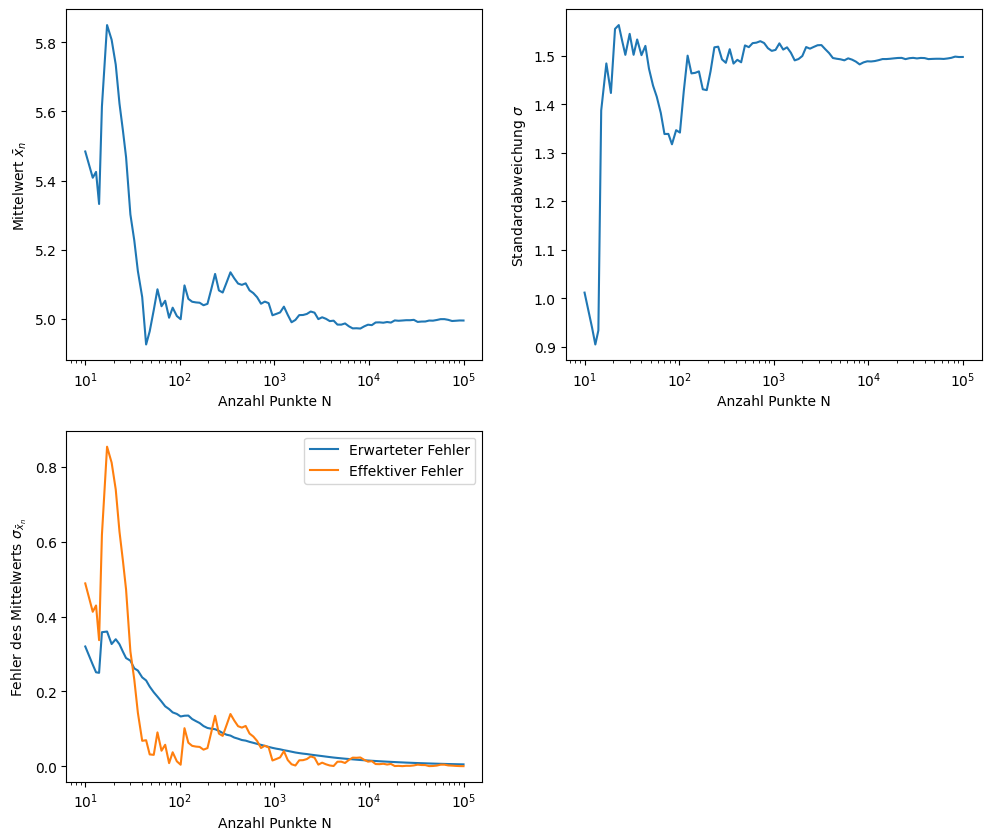

In [1222]:
cm = 0.393701  # Umrechnung Zoll zu Centimeter

# Logarithmischer Bereich von 10 bis len(data): Das sind die verschiedenen n (Anzahl berücksichtiger Punkte)
# dtype = int ist notwendig, damit wir diese Zahlen gleich als Arrayindizes verwenden können.
n_points = np.logspace(1, np.log10(len(data)), 100, dtype=int)

# Initialisiere Arrays, in denen die berechneten Werte für jedes n gespeichert werden
mean_n = np.zeros(len(n_points))
std_n = np.zeros(len(n_points))
error_mean = np.zeros(len(n_points))

# Berechne Mittelwert, Standardabweichung und Fehler des Mittelwerts für jedes n.
for i, n in enumerate(n_points):
    mean_n[i] = np.mean(data[:n])
    std_n[i] = np.std(data[:n])
    error_mean[i] = np.std(data[:n]) / np.sqrt(n)

# Ergebnis Plotten
fig = plt.figure(figsize=(30*cm, 25.5*cm))
ax = fig.add_subplot(2, 2, 1)
ax.semilogx(n_points, mean_n)
ax.set_xlabel('Anzahl Punkte N')
ax.set_ylabel(r'Mittelwert $\bar{x}_n$')

ax = fig.add_subplot(2, 2, 2)
ax.semilogx(n_points, std_n)
ax.set_xlabel('Anzahl Punkte N')
ax.set_ylabel(r'Standardabweichung $\sigma$')

ax = fig.add_subplot(2, 2, 3)
ax.semilogx(n_points, error_mean, label='Erwarteter Fehler')
ax.semilogx(n_points, np.abs(mean_n - mean_n[-1]),label='Effektiver Fehler')
ax.set_xlabel('Anzahl Punkte N')
ax.set_ylabel(r'Fehler des Mittelwerts $\sigma_{\bar{x}_n}$')
ax.legend()

Man kann deutlich erkennen, wie sich der Mittelwert und die Standardabweichung der Daten den Werten $\mu=5$ und $\sigma=1.5$ annähern, während die Unsicherheit des Mittelwerts mit $\frac{1}{\sqrt{N}}$ abnimmt. 

## c)

Vergleichen Sie die Mittelwerte und deren Unsicherheiten mit den Verteilungen der Datenpunkte. Plotten Sie dazu die Histogramme für 10, 100, 1'000 und 10'000 Punkte, und zeichnen Sie die dazugehörigen Mittelwerte mit deren Unsicherheiten ein.

### Lösung

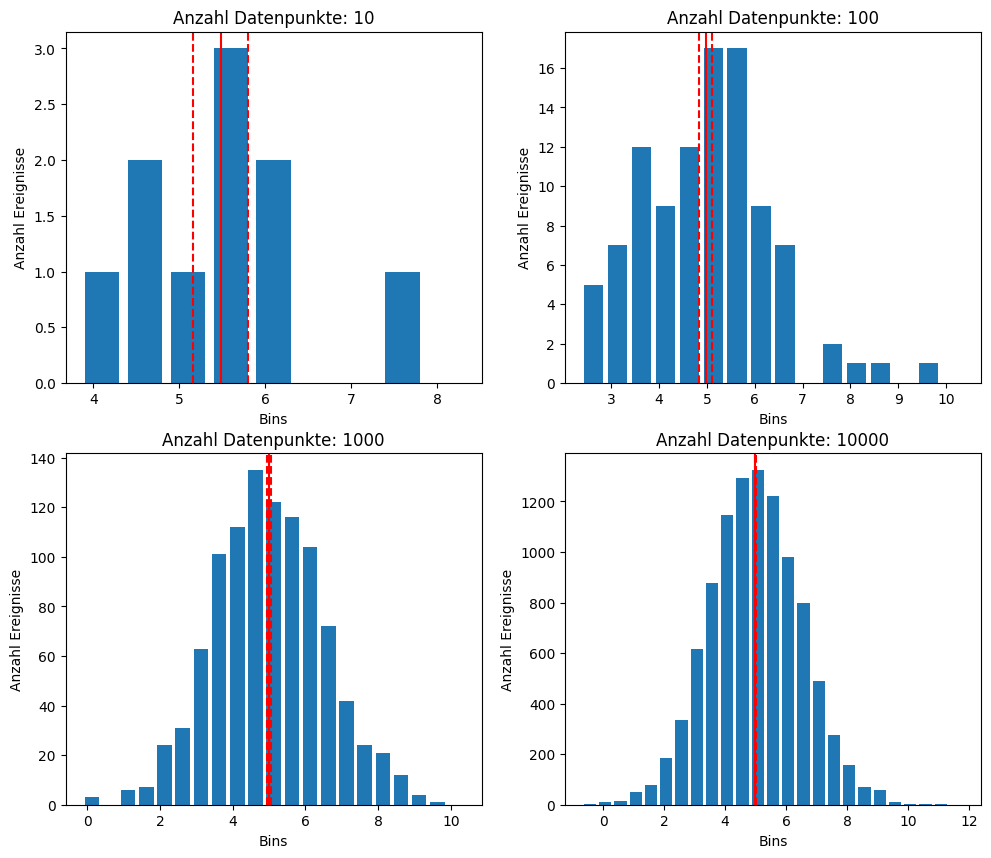

In [1223]:
cm = 0.393701  # Umrechnung Zoll zu Zentimeter

# Liste der betrachteten n
n_points_list = np.array([10, 100, 1000, 10000])

fig = plt.figure(figsize=(30*cm, 25.5*cm))
binsize = 0.5

# Wir erzeugen die Histogramme und Plots für die verschiedenen n in einer for-Schleife, da
# der Code immer der gleiche ist.
for i, n_points in enumerate(n_points_list):
    # Mittelwert und Fehler des Mittelwerts berechnen
    mean = np.mean(data[:n_points])
    error_mean = np.std(data[:n_points]) / np.sqrt(n_points)
    
    # Histogramm erzeugen
    bin_edges = np.arange(np.min(data[:n_points]), np.max(data[:n_points])+1, binsize)
    bin_centers = bin_edges[:-1] + 0.5 * binsize
    hist, _ = np.histogram(data[:n_points], bin_edges)
    
    # Plotten
    ax = fig.add_subplot(2, 2, i+1)
    ax.bar(bin_centers, hist, width=0.8*binsize)
    ax.axvline(mean, color='r')
    ax.axvline(mean-error_mean, color='r', linestyle='--')
    ax.axvline(mean+error_mean, color='r', linestyle='--')
    ax.set_xlabel('Bins')
    ax.set_ylabel('Anzahl Ereignisse')
    ax.set_title('Anzahl Datenpunkte: {:.0f}'.format(n_points))

# Aufgabe 2 Fehler des Mittelwerts mit Gauss

Leiten Sie die Unsicherheit des Mittelwerts mithilfe der Gaussschen Fehlerfortpflanzung her. Nehmen Sie dazu an, dass alle Datenpunkte die gleiche Unsicherheit $\sigma$ haben.

### Lösung

Der Mittelwert ist gegeben durch

$$\bar{x} = \frac{1}{N} \sum_{i=1}^{N} x_i.$$

Jeder Datenpunkt $x_i$ ist eine Unabhähngige Variable, d.h. die Varianz des Mittelwerts ist

$$\sigma_\bar{x}^2 = \sum_{i=1}^{N} \left(\frac{\partial\bar{x}}{\partial x_i}\right)^2 \sigma^2.$$

Die Ableitung nach dem $i$-ten Punkt ist 

$$\left(\frac{\partial\bar{x}}{\partial x_i}\right) = \frac{1}{N},$$

also haben wir

$$\sigma_\bar{x}^2 = \sum_{i=1}^{N} \left(\frac{\partial\bar{x}}{\partial x_i}\right)^2 \sigma^2 = \sum_{i=1}^{N} \frac{1}{N^2} \sigma^2 = \frac{\sigma^2}{N}$$

und somit wie erwartet

$$\sigma_\bar{x} = \frac{\sigma}{\sqrt{N}}.$$

# Aufgabe 3 Gausssche Fehlerfortpflanzung

In vielen Experimenten wird nicht die gesuchte Grösse direkt gemessen, sondern diese muss erst aus den gesammelten Daten berechnet werden. In dieser Aufgabe werden Sie die Fehler einer solchen Grösse durch Fehlerfortpflanzung der Unsicherheit normalverteilter Werte berechnen.

Als System betrachten wir dazu eine Masse $m$, die sich mit einer Geschwindigkeit $v$ auf einer Kreisbahn mit Radius $R$ bewegt. Nun soll für verschiedene Geschwindigkeiten die Kraft berechnet werden, mit der die Masse auf der Kreisbahn gehalten wird. Die Geschwindigkeiten und ihre Standardabweichungen können dabei aus der Datei `Geschwindigkeiten.txt` entnommen werden. Die zusätzlichen Werte sind:

$m$  | $R$
---|---
0.1 $\pm$ 0.001 kg| 0.15 $\pm$ 0.001 m

## a)

Laden Sie zuerst den Datensatz.

### Lösung

In [1224]:
R = 0.15
sigma_R = 0.001
m = 0.1
sigma_m = 0.001

data = np.loadtxt('data/geschwindigkeiten.txt')
v = data[0,:]
sigma_v = data[1,:]

## b)

Berechnen Sie nun die Unsicherheit der Zentripetalkraft mit der Gaussschen Fehlerfortpflanzung. Vergleichen Sie die einzelnen Terme in der Summe. Gibt es Terme, die Sie vernachlässigen können?

Tipp: Sie können mit `ax.set_yscale` auf eine logarithmische Skala auf der y-Achse wechseln.

### Lösung

Die Zentripetalkraft ist gegeben durch $F_z=\frac{mv^2}{R}$, woraus die Unsicherheit

$$\sigma_F=\sqrt{\left(\frac{\partial F}{\partial m}\right)^2\sigma_m^2 + \left(\frac{\partial F}{\partial v}\right)^2\sigma_v^2+\left(\frac{\partial F}{\partial R}\right)^2\sigma_R^2} = \sqrt{\frac{v^4}{R^2}\sigma_m^2 + \frac{4m^2v^2}{R^2}\sigma_v^2 + \frac{m^2v^4}{R^4}\sigma_R^2} = F_z\sqrt{\frac{1}{m^2}\sigma_m^2+\frac{4}{v^2}\sigma_v^2+\frac{1}{R^2}\sigma_R^2}$$

folgt. Wir vergleichen nun die Terme unter der Wurzel:

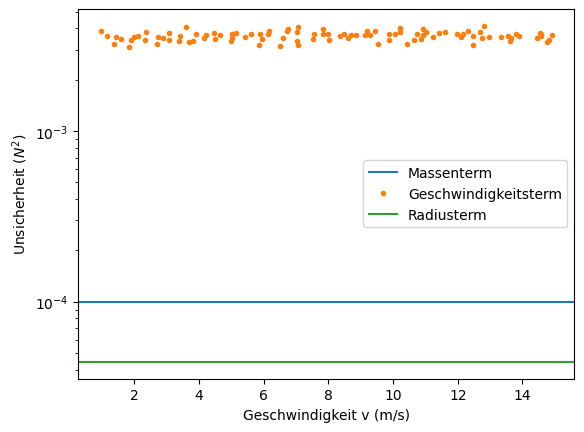

In [1225]:
dFdm = 1 / m**2 * sigma_m**2
dFdv = 4 / v**2 * sigma_v**2
dFdR = 1 / R**2 * sigma_R**2

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

# Logarithmische Skalierung der y-Achse
ax.set_yscale("log", nonpositive='clip')
ax.axhline(dFdm, color='C0', label='Massenterm')
ax.plot(v, dFdv, '.', color='C1', label='Geschwindigkeitsterm')
ax.axhline(dFdR, color='C2', label='Radiusterm')
ax.set_xlabel('Geschwindigkeit v (m/s)')
ax.set_ylabel(r'Unsicherheit $(N^2)$')
ax.legend()

Der Fehler des Radius ist im vergleich zu den anderen beiden Termen vernachlässigbar klein. Was also übrig bleibt ist:
$\sigma_F = F_z\sqrt{\frac{1}{m^2}\sigma_m^2+\frac{4}{v^2}\sigma_v^2}$.

## c)

Plotten Sie nun die Kraft zusammen mit den Fehlern in Abhängigkeit der gemessenen Geschwindigkeit. Sie können dazu `ax.errorbar()` benutzen. 

### Lösung

Text(0.5, 1.0, 'Zentripetalkraft')

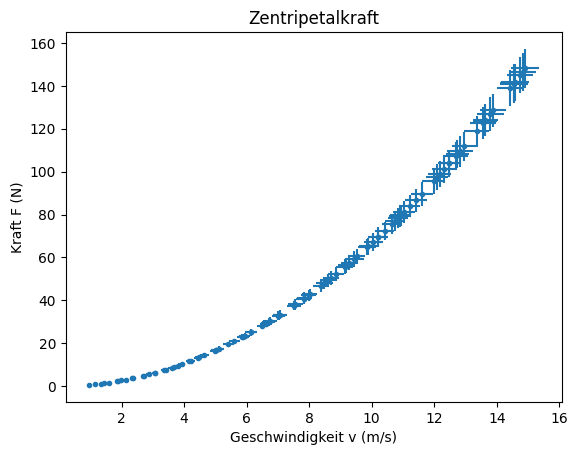

In [1226]:
Fz = m * v**2 / R
sigma_F = Fz * np.sqrt(1 / m**2 * sigma_m**2 + 4 / v**2 * sigma_v**2)

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.errorbar(v, Fz, xerr=sigma_v, yerr=sigma_F, marker='.', linestyle='none')
ax.set_xlabel('Geschwindigkeit v (m/s)')
ax.set_ylabel('Kraft F (N)')
ax.set_title('Zentripetalkraft')

## Aufgabe 4 Gausssche Fehlerfortpflanzung

Wir betrachten den exponentiellen Zerfall der Population eines beliebigen Systems (z.B. eines radioaktiven Isotops), gegeben durch $N(t) = N_0e^{-\frac{t}{\tau}}$. Um die Zerfallszeit $\tau$ zu bestimmen, wird wiederholt die Anfangspopulation $N_0$ und die Population $N(t)$ nach einer Zeit $t$ gemessen.

## a)

Berechnen Sie die Unsicherheit $\sigma_\tau$ der Zerfallszeit abhängig von den Unsicherheiten der Population ($\sigma_N$) und der gemessenen Zeit ($\sigma_t$).

### Lösung

Zuerst formen wir die Gleichung um und lösen nach $\tau$ auf:

$$ \tau = \frac{t}{ln\left(\frac{N_0}{N(t)}\right)}.$$

Anschliessend können wir die Unsicherheit berechnen, wobei wir annehmen dass $\sigma_N=\sigma_{N_0}$:

$$\sigma_\tau=\sqrt{\left(\left(\frac{\partial\tau}{\partial N}\right)^2+\left(\frac{\partial\tau}{\partial N_0}\right)^2\right)\sigma_N^2 + \left(\frac{\partial\tau}{\partial t}\right)^2\sigma_t^2}.$$

Die Ableitungen sind

$$\frac{\partial\tau}{\partial t} = \frac{1}{ln\left(\frac{N_0}{N(t)}\right)},$$

$$\frac{\partial\tau}{\partial N_0} = -\frac{t}{ln^2\left(\frac{N_0}{N}\right)N_0},$$

$$\frac{\partial\tau}{\partial N} = \frac{t}{ln^2\left(\frac{N_0}{N}\right)N}.$$

Einsetzen ergibt schliesslich

$$\sigma_\tau=\sqrt{\left(\frac{t^2}{ln^4\left(\frac{N_0}{N}\right)N^2}+\frac{t^2}{ln^4\left(\frac{N_0}{N}\right)N_0^2}\right)\sigma_N^2 + \frac{1}{ln^2\left(\frac{N_0}{N}\right)}\sigma_t^2} = \tau \sqrt{\left(\frac{1}{ln^2\left(\frac{N_0}{N}\right)N^2}+\frac{1}{ln^2\left(\frac{N_0}{N}\right)N_0^2}\right)\sigma_N^2+\frac{1}{t^2}\sigma_t^2}.$$



## b)

Laden Sie nun die Datensätze `Population1.txt` und `Population2.txt`. Sie beinhalten die wiederholte Messung von $N_0$ sowie $N(t=20s)$, wobei der zweite Datensatz mit einem Detektor mit einer grösseren Unsicherheit gemessen wurde. Nehmen Sie an, dass die Unsicherheit in der Zeit vernachlässigbar ist, und plotten Sie die Histogramme der Zerfallskonstanten. Was können Sie beobachten?

### Lösung

In [1227]:
t = 20

data = np.loadtxt('data/Population1.txt', comments='#')
N01 = data[0, :]
N1 = data[1, :]

data = np.loadtxt('data/Population2.txt', comments='#')
N02 = data[0, :]
N2 = data[1, :]

Text(0.5, 1.0, 'Hohe Unsicherheit')

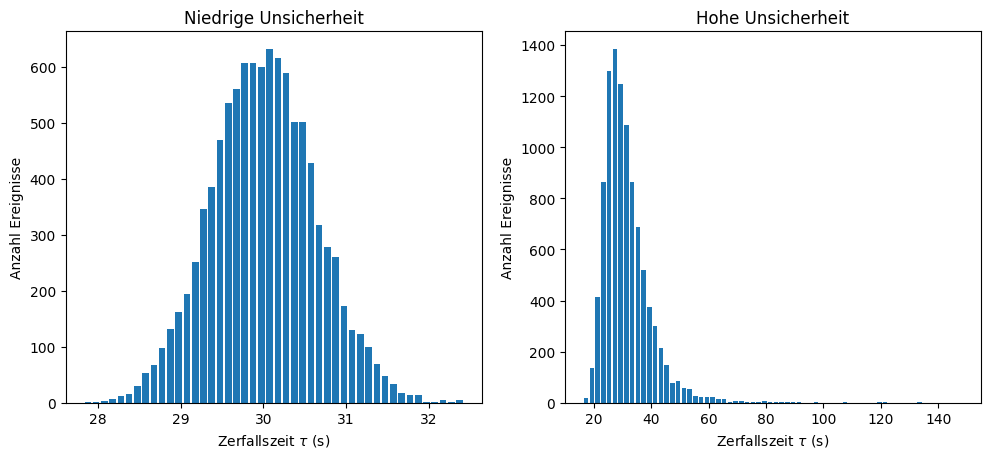

In [1228]:
tau1 = t / np.log(N01 / N1)
tau2 = t / np.log(N02 / N2)

# Histogramme berechnen
binsize1 = 0.1
bin_edges1 = np.arange(np.min(tau1), np.max(tau1), binsize1)
bin_centers1 = bin_edges1[:-1] + 0.5 * binsize1
hist1, _ = np.histogram(tau1, bin_edges1)

binsize2 = 2
bin_edges2 = np.arange(np.min(tau2), np.max(tau2), binsize2)
bin_centers2 = bin_edges2[:-1] + 0.5 * binsize2
hist2, _ = np.histogram(tau2, bin_edges2)

# Daten plotten
cm = 0.393701  # Umrechnung Zoll zu Centimeter

fig = plt.figure(figsize=(30*cm, 12.25*cm))
ax = fig.add_subplot(1, 2, 1)
ax.bar(bin_centers1, hist1, width=0.8*binsize1)
ax.set_xlabel('Zerfallszeit $\\tau$ (s)')
ax.set_ylabel('Anzahl Ereignisse')
ax.set_title('Niedrige Unsicherheit')

ax = fig.add_subplot(1, 2, 2)
ax.bar(bin_centers2, hist2, width=0.8*binsize2)
ax.set_xlabel('Zerfallszeit $\\tau$ (s)')
ax.set_ylabel('Anzahl Ereignisse')
ax.set_title('Hohe Unsicherheit')

Mit der Gaussschen Fehlerforpflanzung benutzt man die lokale Steigung der Funktion um die Unsicherheit zu skalieren. Ist die Unsicherheit aber zu gross, bricht die lineare Approximation zusammen und man erhält keine Normalverteilung mehr, sondern eine asymmetrische Verteilung wie im Histogramm rechts zu sehen.

---

# Musterlösung 5

In [1229]:
import numpy as np
import matplotlib.pyplot as plt

# Kovarianz und Korrelationskoeffizient

In dieser Übung berechnen Sie die Kovarianz und den Korrelationskoeffizienten zwischen verschiedenen Messgrössen eines Datensatzes.

## a)

Laden Sie den Datensatz "data_xyz.txt". Er enthält drei Auslenkungen x, y und z, gemessen in Abhängigkeit der Zeit t. Erstellen Sie Plots der Messgrössen als Funktion der Zeit.

### Lösung

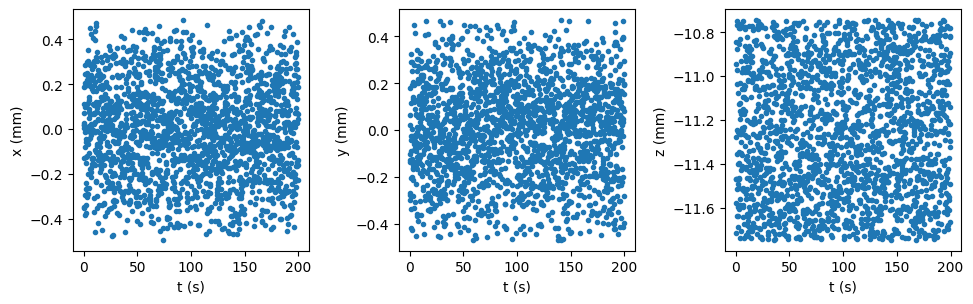

In [1230]:
# Daten einlesen
data = np.loadtxt('data/data_xyz.txt', comments='#')

t = data[:, 0]
x = data[:, 1]
y = data[:, 2]
z = data[:, 3]

# Plots erstellen
cm = 1 / 2.54

fig = plt.figure(figsize=(25*cm, 8*cm))

ax1 = fig.add_subplot(1, 3, 1)
ax1.plot(t, x, '.')
#ax1.plot(t, x)
ax1.set_xlabel('t (s)')
ax1.set_ylabel('x (mm)')

ax2 = fig.add_subplot(1, 3, 2)
ax2.plot(t, y, '.')
ax2.set_xlabel('t (s)')
ax2.set_ylabel('y (mm)')

ax3 = fig.add_subplot(1, 3, 3)
ax3.plot(t, z, '.')
ax3.set_xlabel('t (s)')
ax3.set_ylabel('z (mm)')


# Automatische Formatierung des Plot-Layouts, so dass keine Achsenbeschriftungen und Plots überlappen
fig.tight_layout()

Aus den Plots kann man keine Struktur erkennen. Alle drei Messgrössen scheinen zufällig um einen festen Wert zu fluktuieren.

## b)

Plotten Sie nun die Messgrössen paarweise in Abhängigkeit voneinander, also z.B. y(x), z(x) und y(z). Was sehen Sie für Abhängigkeiten?

Tipp: Verwenden Sie entweder die Funktion `ax.scatter` oder schalten Sie in `ax.plot` die Linien zwischen den Datenpunkten aus, um einen Scatterplot zu erstellen.

### Lösung

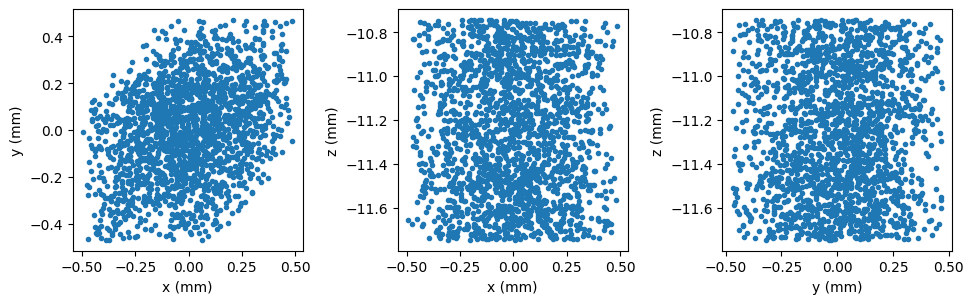

In [1231]:
cm = 1 / 2.54

fig = plt.figure(figsize=(25*cm, 8*cm))

ax1 = fig.add_subplot(1, 3, 1)
ax1.plot(x, y, '.')
ax1.set_xlabel('x (mm)')
ax1.set_ylabel('y (mm)')

ax2 = fig.add_subplot(1, 3, 2)
ax2.plot(x, z, '.')
ax2.set_xlabel('x (mm)')
ax2.set_ylabel('z (mm)')

ax3 = fig.add_subplot(1, 3, 3)
ax3.plot(y, z, '.')
ax3.set_xlabel('y (mm)')
ax3.set_ylabel('z (mm)')

fig.tight_layout()

Die Paare (x, z) und (y, z) sind unkorreliert, was man daran erkennt, dass die Punktewolke im Scatterplot keine ausgezeichnete Richtung aufweist. Das Paar (x, y) ist positiv korreliert: Wenn ein positiver x-Wert gemessen wurde, ist es wahrscheinlich, dass gleichzeitig auch ein positiver y-Wert gemessen wurde.

## c)

Schreiben Sie eine Funktion, die aus zwei gleich langen Arrays von Datenpunkten die Kovarianz berechnet.
Überprüfen Sie Ihr Resultat mithilfe von `np.cov`. Beachten Sie, dass diese Funktion die gesamte Kovarianzmatrix zurückgibt, also

$$ \mathrm{np.cov(x, y)} = \left( \begin{matrix} \sigma_{xx}^2 & \sigma_{xy}^2 \\
                                                 \sigma_{yx}^2 & \sigma_{yy}^2 \end{matrix} \right). $$

### Lösung

Als Referenz hier nochmal die Definition der Kovarianz aus der Vorlesung:

$$ \sigma_{xy}^2 = \mathrm{cov}(x, y) = \frac{1}{N} \sum_{i=1}^{N} (x_i - \bar{x}) (y_i - \bar{y}).$$


In [1232]:
def covariance(x, y):
    '''Calculate covariance of two arrays x and y with same lengths.'''
    # Um Fehler zu vermeiden, können wir vorneweg testen, ob x und y wirklich die gleiche Länge haben
    if len(x) != len(y):
        raise ValueError('x and y must have same length.')
        
    N = len(x)
    
    # Zuerst Berechnen wir die Mittelwerte von x und y.
    # Hier könnten Sie auch np.mean oder Ihre Funktion aus Übung 2 verwenden.
    x_sum = 0
    y_sum = 0
    for i in range(N):
        x_sum += x[i]
        y_sum += y[i]
    
    x_mean = x_sum / N
    y_mean = y_sum / N
    
    # Als nächstes implementieren wir die Summe der Differenzen zum Mittelwert, wie in der Definition.
    cov_sum = 0
    for i in range(N):
        cov_sum += (x[i] - x_mean) * (y[i] - y_mean)
    
    # Duch N dividieren und zurückgeben
    return cov_sum / N


cov_np = np.cov(x, y)[0, 1]
cov_fct = covariance(x, y)
print('Mit der eigenen Funktion: sigma_xy = {:.3f} mm^2\n'
      'Mit np.cov:               sigma_xy = {:.3f} mm^2'.format(cov_fct, cov_np))

Mit der eigenen Funktion: sigma_xy = 0.014 mm^2
Mit np.cov:               sigma_xy = 0.014 mm^2


## d)

Berechnen Sie aus den Kovarianzen die Korrelationskoeffizienten für alle Kombinationen von x, y und z. Entspricht das Resultat Ihren Erwartungen aufgrund der Plots?

Sie können Ihr Resultat mithilfe von `np.corrcoef` überprüfen. Kleine Abweichungen können aufgrund von Rundungsfehlern und der genauen Implementation auftreten. Auch diese Funktion gibt gleich die ganze Korrelationsmatrix zurück.

### Lösung

Die Definition des Korrelationskoeffizienten ist:

$$\rho_{xy} = \frac{\mathrm{cov}(x, y)}{\sigma_x \sigma_y}.$$

In [1233]:
# Da sigma_x = sqrt(cov(x, x)) ist, können wir alles ausrechnen, ohne auf Numpy-Funktionen (ausser np.sqrt)
# zurückzugreifen. Wir machen das hier aus didaktischen Gründen. Wenn Sie Ihre Daten analysieren, ist es
# meistens empfehlenswert die Funktionen von Numpy zu verwenden, da diese optimiert sind und vor allem
# auf grossen Datensätzen viel schneller laufen.
sigma_x = np.sqrt(covariance(x, x))
sigma_y = np.sqrt(covariance(y, y))
sigma_z = np.sqrt(covariance(z, z))

rho_xy = covariance(x, y) / (sigma_x * sigma_y)
rho_xz = covariance(x, z) / (sigma_x * sigma_z)
rho_yz = covariance(y, z) / (sigma_y * sigma_z)

print('         Eigene Funktion   np.corrcoef')
print('rho_xy =     {:.3f}           {:.3f}'.format(rho_xy, np.corrcoef(x, y)[0, 1]))
print('rho_xz =    {:.3f}          {:.3f}'.format(rho_xz, np.corrcoef(x, z)[0, 1]))
print('rho_yz =     {:.3f}           {:.3f}'.format(rho_yz, np.corrcoef(y, z)[0, 1]))

         Eigene Funktion   np.corrcoef
rho_xy =     0.324           0.324
rho_xz =    -0.015          -0.015
rho_yz =     0.015           0.015


Die Korrelationskoeffizienten bestätigen die Annahme, dass $(x,y)$ positiv korreliert sind, während $(x,z)$ und $(y,z)$ unkorreliert sind. Natürlich sind Daten nie perfekt korreliert oder unkorreliert und die Koeffizienten können immer einen kleinen Wert annehmen.

# Autokovarianz als Funktion der Zeit

In dieser Übung schauen Sie sich die Autokovarianz verschiedener Arten von Signalen an.

## a)

Laden Sie den Datensatz 'signal_1.txt' und plotten Sie die Daten.

### Lösung

Text(0, 0.5, 'Amplitude (mV)')

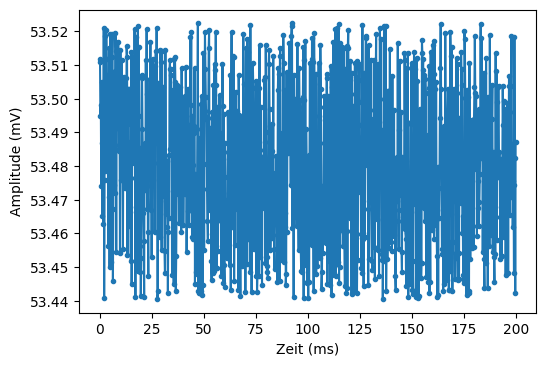

In [1234]:
# Daten laden
data = np.loadtxt('data/signal_1.txt', comments='#')
t = data[:, 0]
amplitude = data[:, 1]

# Plotten
cm = 1 / 2.54
fig = plt.figure(figsize=(15*cm, 10*cm))
ax = fig.add_subplot(1, 1, 1)
ax.plot(t * 1e3, amplitude, '.-')
ax.set_xlabel('Zeit (ms)')
ax.set_ylabel('Amplitude (mV)')

## b)

Schreiben Sie eine Funktion, die die Autokovarianz 

$$R_{xx}(\Delta i) = \frac{1}{N - \Delta i} \sum_{i=0}^{N - \Delta i - 1} \left(x[i] - \bar{x}\right) \left(x[i + \Delta i] - \bar{x}\right)$$

eines Datenarrays $x$ mit $N$ Punkten berechnet, die in gleichmässigen Zeitabständen gemessen wurden. Die Funktion soll zwei Arguemente haben, das Datenarray $x$, und die Verschiebung $\Delta i$. Folgendes ist zu beachten:

- Die Verschiebung $\Delta i$ gibt hier an, um wie viele Stellen der Arrayindex verschoben wird. Die entsprechende zeitliche Verschiebung ist $\tau = t[\Delta i] - t[0]$, wenn $t$ das Array für die Zeitachse ist.
- Die Summe geht von 0 bis $N - \Delta i - 1$, damit der Arrayindex $i + \Delta i$ immer kleiner als $N$ ist.
- Im Nenner steht dementsprechend $N - \Delta i$, da dies die Anzahl Terme in der Summe ist.

### Lösung

In [1235]:
def auto_covariance(x, delta):
    '''Calculate the autocovariance of the array x with index shift delta.'''
    N = len(x)
    
    # Um Fehler zu vermeiden, können wir prüfen, ob delta < N ist.
    if delta >= N:
        raise ValueError("Delta must be smaller than len(x).")
        
    # Berechne den Mittelwert. Wir verwenden hier np.mean, man könnte es natürlich auch wieder
    # selber implementieren, wie in Aufgabe 1c).
    x_mean = np.mean(x)
    
    # Berechne die Summe laut Definition
    summation = 0
    for i in range(0, N - delta):
        summation += (x[i] - x_mean) * (x[i + delta] - x_mean)
    
    # Durch N - delta dividieren und zurückgeben
    return summation / (N - delta)

Diese Implementation ist einfach zu verstehen, aber wegen der for-Schleife für grosse Datensätze ziemlich langsam. Eine schnellere Implementation ist möglich, indem man ausnutzt, dass Operationen auf Numpy-Arrays elementweise ausgeführt werden können, was effizienter ist, als die Operationen in einer for-Schleife einzeln auszuführen. Zum Beispiel kann man den Mittelwert direkt vom ganzen Array subtrahieren:

```
x_mean = np.mean(x)
x_residue = x - x_mean
```

Um zu verstehen, wie die Summe über `x_residue[i] * x_residue[i + delta]` ohne for-Schleife berechnet werden kann, kann man sich die beiden Arrays mit verschobenem Index so vorstellen:

```
Index i                    0   1   2   ...  -5  -4  -3  -2  -1
x_residue[i]               | a | b | c | ... | v | w | x | y | z |
x_residue[i+delta] | a | b | c | d | e | ... | x | y | z |
```

wobei hier `delta = 2` ist. Um die Autokovarianz zu berechnen, müssen wir die Elemente, die hier übereinander stehen, miteinander multiplizieren und dann aufsummieren. Mit Array-Slicing wählen wir die relevanten Teilarrays aus,

```
x_residue[:-delta]   | a | b | c | ... | v | w | x |
x_residue[delta:]    | c | d | e | ... | x | y | z |
```

so dass wir die Multiplikation wieder direkt auf diesen ausführen können. Schliesslich verwenden wir noch die optimierte Numpy-Funktion `np.sum`, um die Summe der Produkte zu berechnen.

In [1236]:
def auto_covariance_fast(x, delta):
    # Den Fall delta = 0 müssen wir separat behandeln, weil x[:-0] ein leeres Array gibt.
    if delta == 0:
        autocov = np.var(x)
    else:
        N = len(x)
    
        # Wir subtrahieren erst den Mittelwert vom ganzen Array
        x_mean = np.mean(x)
        x_residue = x - x_mean
        
        # Durch Array-Slicing erhalten wir die relevanten überlappenden Teilarrays, von denen wir
        # den Mittelwert subtrahieren. Da wir mit Numpy-Arrays arbeiten, wird die anschliessende
        # Multiplikation elementweise durchgeführt. Die Elemente des resultierenden Arrays werden
        # mit np.sum effizient aufsummiert.
        autocov = np.sum(x_residue[:-delta] * x_residue[delta:]) / (N - delta)
        
    return autocov

## c)

Benutzen Sie Ihre Funktion, um die Autokovarianz des Amplitudensignals aus den geladenen Daten für jedes $\Delta = 0, \dots, N-1$ zu berechnen. Berechnen Sie auch die entsprechenden Zeitverschiebungen $\tau$ und plotten sie $R_{xx}(\tau)$. Interpretieren Sie das Resultat.


### Lösung

In [1237]:
N = len(amplitude)  # Anzahl Datenpunkte
dt = t[1] - t[0]  # Zeitdifferenz zwischen zwei Datenpunkten.
tau = np.arange(N-1) * dt  # Tau-Achse für die Autokovarianz

# Initialisiere ein leeres Array mit der richtigen Länge für die Autokovarianz als Funktion von tau oder delta
r_xx = np.zeros(N-1)

# Berechne die Autokovarianz für jedes delta.
for delta in range(N-1):
    r_xx[delta] = auto_covariance(amplitude, delta)

Text(0, 0.5, 'Autokovarianz $R_{xx}$ (mV$^2$)')

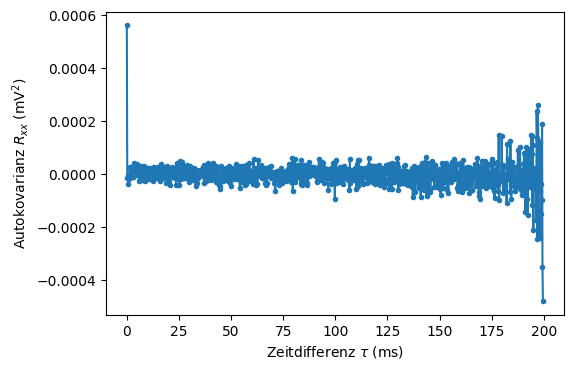

In [1238]:
# Resultat plotten
cm = 1 / 2.54
fig = plt.figure(figsize=(15*cm, 10*cm))
ax = fig.add_subplot(1, 1, 1)
ax.plot(tau * 1e3, r_xx, '.-')
ax.set_xlabel('Zeitdifferenz $\\tau$ (ms)')
ax.set_ylabel('Autokovarianz $R_{xx}$ (mV$^2$)')

Wir sehen, dass die Autokovarianz immer Null ist, ausser bei $\tau = 0$, wo sie der Varianz entspricht $R_{xx}(\tau = 0) = \sigma_{x}^2$. Bei grossen $\tau$ wird die statistische Fluktuation gross, da die Autokovarianz nur noch aus sehr wenigen Punkten berechnet wird ($N - \Delta i$ nähert sich Null an).

Wenn die Autokovarianz überall Null ist, heisst das, dass die Daten zeitlich unkorreliert sind: Der gemessene Wert zu jedem Zeitpunkt ist unabhängig von den Werten zu allen anderen Zeiten. Das betrachtete physikalische System hat keine Erinnerung an seinen Zustand in der Vergangenheit.

## d)

Laden Sie nun den Datensatz 'signal_2.txt' und plotten Sie sowohl die Amplitude als Funktion der Zeit, als auch die Autokovarianz als Funktion von $\tau$. Interpretieren Sie wieder das Resultat.

### Lösung

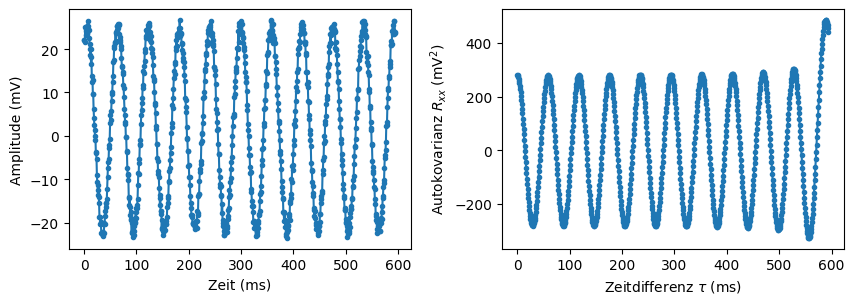

In [1239]:
# Daten laden
data = np.loadtxt('data/signal_2.txt', comments='#')
t = data[:, 0]
amplitude = data[:, 1]

# Autokovarianz
N = len(amplitude)  # Anzahl Datenpunkte
dt = t[1] - t[0]  # Zeitdifferenz zwischen zwei Datenpunkten
tau = np.arange(N-1) * dt  # Tau-Achse für die Autokovarianz
r_xx = np.zeros(N-1)
for delta in range(N-1):
    r_xx[delta] = auto_covariance(amplitude, delta)

# Plotten
cm = 1 / 2.54
fig = plt.figure(figsize=(22*cm, 8*cm))
ax = fig.add_subplot(1, 2, 1)
ax.plot(t * 1e3, amplitude, '.-')
ax.set_xlabel('Zeit (ms)')
ax.set_ylabel('Amplitude (mV)')

ax = fig.add_subplot(1, 2, 2)
ax.plot(tau * 1e3, r_xx, '.-')
ax.set_xlabel('Zeitdifferenz $\\tau$ (ms)')
ax.set_ylabel('Autokovarianz $R_{xx}$ (mV$^2$)')

fig.tight_layout()

Im zeitabhängigen Signal sieht man eine einfache Oszillation. Die Autokorrelation oszilliert ebenfalls, was leicht zu verstehen ist: Immer wenn die Zeitdifferenz $\tau$ ganzzahligen Vielfachen der Oszillationsperiode $T$ enspricht, also $\tau = k \cdot T$ mit $k \in \mathbb{Z}$, überlappt die Oszillation mit sich selbst und alle Summanden in der Autokorrelation sind positiv. Wenn aber $\tau = \left(k + \frac{1}{2}\right) \cdot T$, oszillieren das originale und verschobene Signal genau gegenphasig und alle Summanden sind negativ. Im Plot unten sind diese beiden Fälle dargestellt.

Da das System eine regelmässige Zeitabhängigkeit hat, sind die Messwerte nicht mehr zeitlich unabhängig voneinander: Wenn zum Zeitpunkt $t$ ein positiver Wert gemessen wird, wird auch eine Periode später bei $t + T$ ein positiver Wert auftreten; bei $t + T/2$ wird dagegen ein negativer Wert auftreten. Die Werte sind in diesem Fall also zeitlich korelliert, und zwar für beliebig lange Zeitdifferenzen $\tau$.

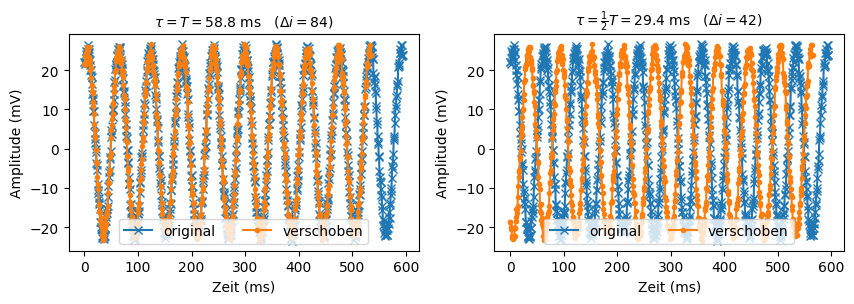

In [1240]:
di_1 = 84
di_2 = 42

cm = 1 / 2.54
fig = plt.figure(figsize=(22*cm, 8*cm))
ax = fig.add_subplot(1, 2, 1)
ax.plot(t * 1e3, amplitude, 'x-', label='original')
ax.plot(t[:-di_1] * 1e3, amplitude[di_1:], '.-', label='verschoben')
ax.set_xlabel('Zeit (ms)')
ax.set_ylabel('Amplitude (mV)')
ax.set_title('$\\tau = T = {:.1f}$ ms   $(\\Delta i = {})$'.format(tau[di_1]*1e3, di_1), size=10)
ax.legend(ncol=2, loc='lower center')

ax = fig.add_subplot(1, 2, 2)
ax.plot(t * 1e3, amplitude, 'x-', label='original')
ax.plot(t[:-di_2] * 1e3, amplitude[di_2:], '.-', label='verschoben')
ax.set_xlabel('Zeit (ms)')
ax.set_ylabel('Amplitude (mV)')
ax.set_title('$\\tau = \\frac{{1}}{{2}} T = {:.1f}$ ms   $(\\Delta i = {})$'.format(tau[di_2]*1e3, di_2),
             size=10)
ax.legend(ncol=2, loc='lower center')

fig.tight_layout()

## e)

Laden Sie nun den letzten Datensatz, 'signal_3.txt'. Dieser enthält zwei zeitabhängige Messungen, die mit der gleichen Zeitachse gemessen wurden. Plotten Sie beide Signale als Funktion der Zeit und zoomen Sie in der Zeitachse, um die Struktur der Daten anzuschauen und sich den Unterschied zwischen den zwei Messungen bewusst zu machen.

### Lösung

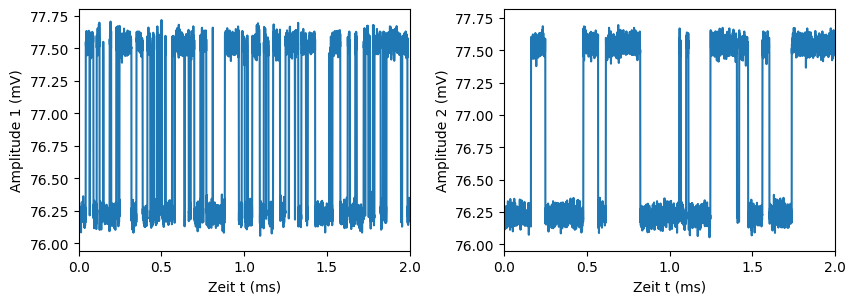

In [1241]:
data = np.loadtxt('data/signal_3.txt', comments='#')

t = data[0]
amplitude1 = data[1]
amplitude2 = data[2]

cm = 1 / 2.54
fig = plt.figure(figsize=(22*cm, 8*cm))
ax = fig.add_subplot(1, 2, 1)
ax.plot(t, amplitude1)
ax.set_xlabel('Zeit t (ms)')
ax.set_ylabel('Amplitude 1 (mV)')

ax.set_xlim(0, 2)


ax = fig.add_subplot(1, 2, 2)
ax.plot(t, amplitude2)
ax.set_xlabel('Zeit t (ms)')
ax.set_ylabel('Amplitude 2 (mV)')

ax.set_xlim(0, 2)

fig.tight_layout()

Beide Messungen zeigen Sprünge zwischen zwei Werten auf, aber die Häufigkeit der Sprünge ist in der zweiten Messung kleiner.

## f)

Aus Ihren Plots sollten Sie für jede Messung eine typische Zeitskala $T_{\mathrm{sys}}$ ablesen können, die für das jeweilige System relevant ist. Da diese Messungen sehr viele Datenpunkte haben, kann die Ausführung des Codes sehr lange dauern, wenn Sie die Autokovarianz wie oben für alle möglichen $\tau$ bis $T_{\mathrm{max}}$ berechnen. Berechnen Sie deswegen die Autokovarianz beider Signale nur für $\tau \in [0, 2 T_{\mathrm{sys}}]$; der genaue Wert der oberen Grenze ist nicht so wichtig, nur dass er etwas grösser als die längere typische Zeitskala $T_{\mathrm{sys}}$ ist. Dass Sie die obere Grenze hinreichend gross gewählt haben, erkennen Sie daran, dass die Autokovarianz für grosse $\tau$ gegen Null geht.

Vergleichen Sie die beiden Autokovarianzen und erklären Sie die Beziehung zu der Struktur, die Sie im zeitabhängigen Signal gesehen haben.

Tipp: Wenn die Fehlersuche mühsam ist, weil die Ausführung des Codes zu lange dauert, nehmen Sie erst mal nur die ersten 1000 Datenpunkte.

### Lösung

Die typische Zeitskala, auf der die langsameren Sprünge in der zweiten Messung stattfinden, ist etwa 0.25 ms., daher wählen wir als obere Grenze 0.5 ms.

In [1242]:
# Tau-Achse
dt = t[1] - t[0]  # Zeitdifferenz zwischen zwei Datenpunkten.
tau_max = 0.5
tau = np.arange(0, tau_max, dt)

# Initialisiere Arrays für die Autokovarianzen
r_xx1 = np.zeros(len(tau))
r_xx2 = np.zeros(len(tau))

# Autokovarianz berechnen
# Das delta zu jedem tau ist jetzt einfach sein Arrayindex.
for delta in range(len(tau)):
    r_xx1[delta] = auto_covariance_fast(amplitude1, delta)
    r_xx2[delta] = auto_covariance_fast(amplitude2, delta)

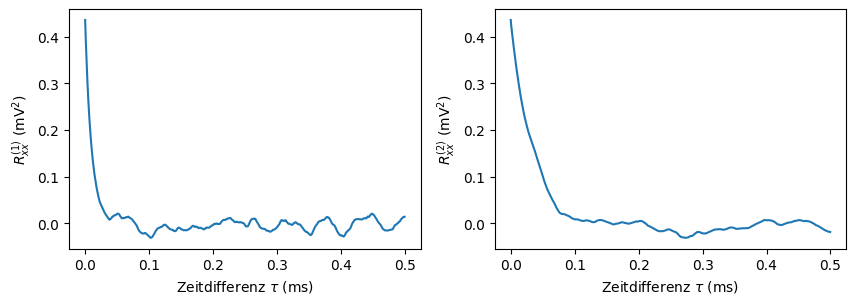

In [1243]:
# Autokovarianz plotten
cm = 1 / 2.54
fig = plt.figure(figsize=(22*cm, 8*cm))
ax = fig.add_subplot(1, 2, 1)
ax.plot(tau, r_xx1)
ax.set_xlabel('Zeitdifferenz $\\tau$ (ms)')
ax.set_ylabel('$R_{xx}^{(1)}$ (mV$^2$)')

ax = fig.add_subplot(1, 2, 2)
ax.plot(tau, r_xx2)
ax.set_xlabel('Zeitdifferenz $\\tau$ (ms)')
ax.set_ylabel('$R_{xx}^{(2)}$ (mV$^2$)')

fig.tight_layout()

Wie man sieht, war die obere grenze von $\tau = 0.5$ s gross genug gewählt, da die Autokovarianz hier schon Null wird (mit ein wenig Rauschen). Auf kurzen Zeitskalen $\tau < 0.1$ s passiert etwas. Zum besseren Vergleich plotten wir die beiden Kurven zusammen und zoomen auf kleine $\tau$.

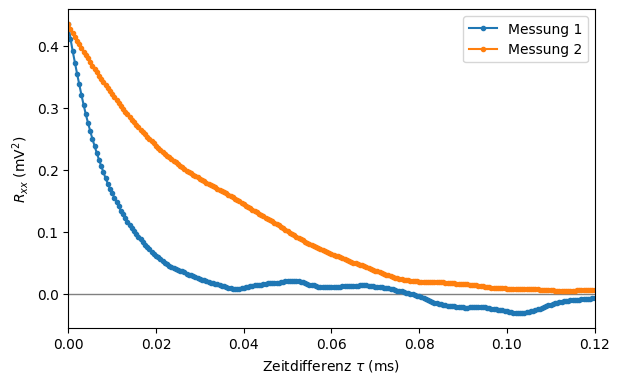

In [1244]:
cm = 1 / 2.54
fig = plt.figure(figsize=(16*cm, 10*cm))
ax = fig.add_subplot(1, 1, 1)

ax.axhline(0, color='.5', linewidth=1)

ax.plot(tau, r_xx1, '.-', label='Messung 1')
ax.plot(tau, r_xx2, '.-', label='Messung 2')

ax.set_xlabel('Zeitdifferenz $\\tau$ (ms)')
ax.set_ylabel('$R_{xx}$ (mV$^2$)')
ax.legend()

ax.set_xlim(0.0, 0.12)

fig.tight_layout()

Man sieht, dass die Autokovarianz beider Messungen für kleine $\tau$ grösser als Null bleibt. Die charakteristische Zeit, in der die Autokovarianz auf Null abfällt unterscheidet sich allerdings: Messung 1 fällt schneller ab ($\tau_c \approx 0.02$ ms) als Messung 2 ($\tau_c \approx 0.07$ ms). Das passt mit der Beobachtung aus den zeitabhängigen Signalen zusammen: In Messung 1 springt das System schneller zwischen den zwei Zuständen hin und her, d.h. schon kurze Zeit nach der Messung eines hohen Werts (77.5 mV) ist es wieder gleich wahrscheinlich, das System in beiden Zuständen zu finden. In Messung 2 sind die Sprünge seltener, d.h. das System "erinnert" sich für eine längere Zeit daran, in welchem Zustand es gerade war, was sich in der Autokorrelation wiederspiegelt.

In diesem Fall erlaubt uns die Autokovarianz die Beobachtung "in Messung 1 sind die Sprünge häufiger" zu quantifizieren, nämlich mit der charakteristischen Zeit $\tau_c$ (Korrelationszeit).

---

# Musterlösung 6

In [1245]:
import numpy as np
import matplotlib.pyplot as plt

# Aufgabe 1 Signal aus harmonischen Funktionen

Wie Sie in der Vorlesung gesehen haben, können periodische Signale aus Sinus- und Kosinusfunktionen aufgebaut werden. Oder allgemeiner formuliert: Die Sinus- und Kosinusfunktionen bilden eine Orthonormalbasis im Raum aller periodischer Funktionen.

Dieses Prinzip wollen wir in der ersten Aufgabe veranschaulichen, indem wir eine periodische Funktion nehmen und sie mit Sinusfunktionen annähern. Dabei werden Sie sehen, dass bereits wenige Summanden der unendlichen Reihe genügen, um die Strukturen der Ausgangsfunktion zu rekonstruieren.


##  a)


Laden Sie den Datensatz `square.txt` und plotten Sie ihn. Er beinhaltet die erste Periode eines Rechtecksignals zusammen mit der dazugehörigen Zeitachse.

### Lösung

Text(0, 0.5, 'Spannung U (V)')

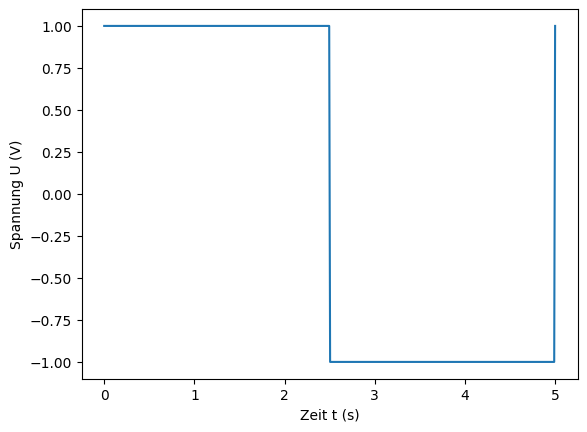

In [1246]:
data = np.loadtxt('data/square.txt', skiprows=1)

t = data[0, :]
square = data[1, :]

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.plot(t, square)
ax.set_xlabel('Zeit t (s)')
ax.set_ylabel('Spannung U (V)')

##  b)


Wir wollen nun das Signal aus einzelnen harmonischen Funktionen aufbauen. Aufgrund der Symmetrie des Signals kann man erkennen, dass es aus Sinusfunktionen aufgebaut ist (Nullstellen bei $t=0, t=T/2$ und $t=T$). Die niedrigste relevante Frequenz $f_1$ ist diejenige, die der inversen Messzeit entspricht,  und alle höheren Frequenzen müssen ein ganzzahliges Vielfaches davon sein, damit sie die Periodizitätsbedingung $U(t + T) = U(t)$ erfüllen.

Wir wollen das Signal also als
    
$$ U(t) = \sum_{n=0}^{N} a_n \sin(2\pi f_n t) $$
    
ausdrücken, wobei $f_n = n \cdot f_1$ ist und $N$ die Anzahl Frequenzkomponenten, die berücksichtigt werden. Die richtigen Amplituden $a_n$, um auf diese Weise ein beliebiges Signal zu konstruieren, können mithilfe der Fouriertransformation berechnet werden, wie Sie in Aufgabe 2 sehen werden. In diesem Fall sind sie gegeben als

$$ a_n = \frac{4}{\pi n} \textrm{ für ungerade } n,\\ a_n = 0 \textrm{ für gerade }n.$$

Schreiben Sie eine Funktion, die die Summe in Gleichung (1) berechnet, wobei als Argumente die Zeitachse $t$ und die Anzahl $N$ der berücksichtigten Frequenzen übergeben werden. Plotten Sie dann das so konstruierte Signal zusammen mit der Rechteckfunktion für verschiedene $N$, um sich zu veranschaulichen, wie das Rechtecksignal immer besser angenähert wird, wenn Sie mehr Frequenzkomponenten dazuaddieren.

### Lösung

In [1247]:
# Wir benutzen die bereits gegebene Zeitachse, um damit die Sinusfunktionen zu definieren
def sum_sin(t, n):
    # Grundfrequenz aufgrund der Länge der Zeitachse
    f1 = 1 / t[-1]
    
    # Initialisieren des Arrays für die Summierung
    signal = np.zeros(len(t))
    
    # Summe über alle Amplituden
    # Die Schleife geht bis n+1, damit die Frequenz f_n auch mit dabei ist.
    # Wir nehmen direkt nur ungerade j, da die Amplituden für gerade j Null ist.
    for j in range(1, n+1, 2):
        a_j = 4 / (np.pi * j)  # Amplitude wie angegeben
        signal += a_j * np.sin(2*np.pi * f1 * j * t)
    return signal

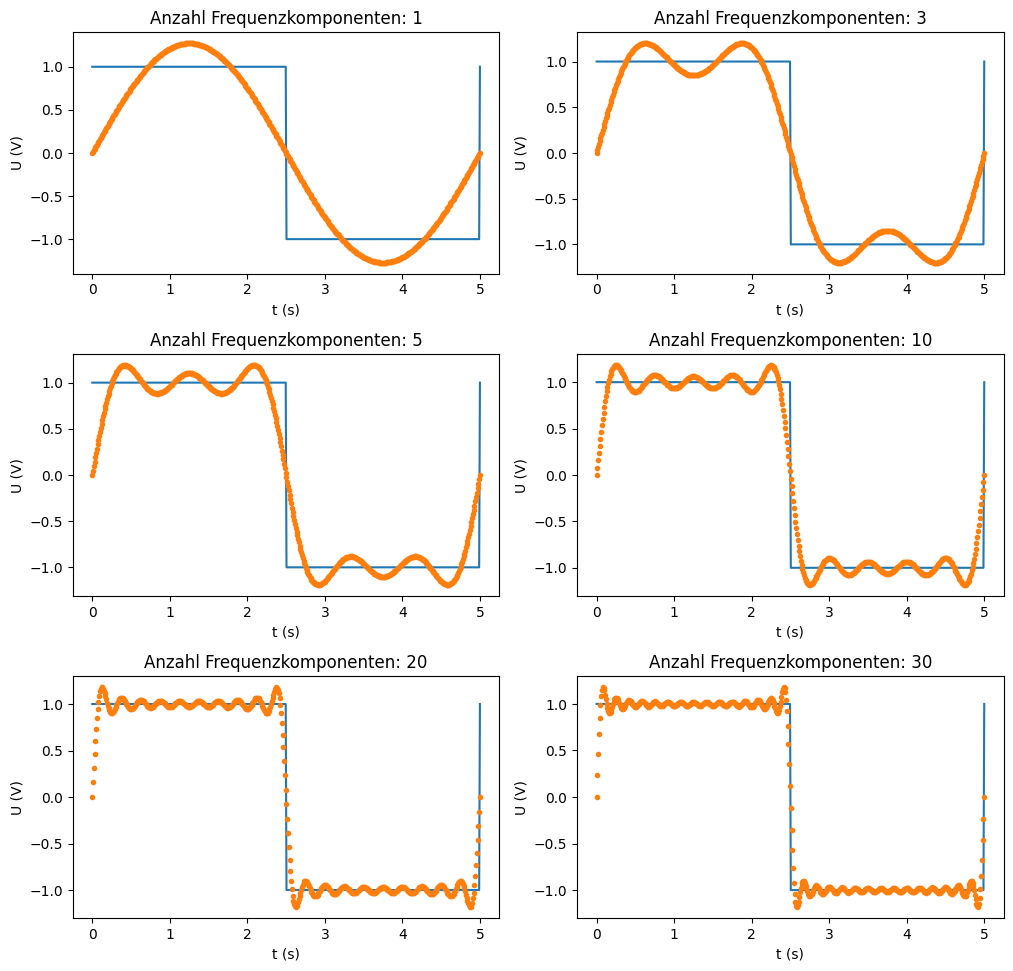

In [1248]:
cm = 1 / 2.54
fig = plt.figure(figsize=(26*cm, 32*cm))

# Die Anzahl der Komponenten, über die summiert werden soll
n_freq = [1, 3, 5, 10, 20, 30]

for i, n in enumerate(n_freq):
    # Neuer Plot mit der Rechtecksfunktion zum Vergleich
    ax = fig.add_subplot(4, 2, i+1)
    ax.plot(t, square)
    
    # Berechne das Signal mit n Frequenzen
    signal = sum_sin(t, n)
    
    # Plotten der aufsummierten Sinusfunktionen.
    ax.plot(t, signal,'.')
    ax.set_xlabel('t (s)')
    ax.set_ylabel('U (V)')
    ax.set_title('Anzahl Frequenzkomponenten: {:n}'.format(n))
    
plt.tight_layout()

Man sieht deutlich, wie die ersten paar Summanden einen grossen Einfluss auf das resultierende Signal haben, während es nicht mehr so darauf ankommt, ob man 20 oder 30 Frequenzen nimmt. Dass die höheren Frequenzen einen kleineren Einfluss haben kann man auch daran sehen, dass die Amplitude mit $1/n$ bzw $1/f_n$ abnimmt.

#  Aufgabe 2 Fouriertransformation

Im obigen Beispiel haben wir als Basis Sinusfunktionen genommen, da sie genau die richtige Phase für unser Signal hatten. Im Allgemeinen ist dies jedoch nicht der Fall, und man muss entweder für jede Frequenz eine Phase $\phi_n$ einführen,

$$x(t) = \sum_{n=0}^{\infty} a_n \sin(2\pi f_n t + \phi_n),$$

einen Kosinusterm hinzufügen,

$$x(t) = \sum_{n=0}^{\infty} a_n \sin(2\pi f_n t) + b_n \cos(2\pi f_n t),$$

oder, was in den meisten Fällen gemacht wird, man benutzt die Exponentialfunktion als Basis,

$$x(t) = \sum_{n=-\infty}^{\infty} a_n e^{i2\pi f_n t},$$
    
womit wir bei der Definition aus der Vorlesung angelangt sind.

In dieser Aufgabe geht es darum, die Amplituden $a_n$ für ein beliebiges Signal zu ermitteln, also die Fouriertransformation auf ein Signal anzuwenden. In Numpy existiert dazu ein ganzes Modul mit entsprechenden Funktionen, von denen wir hier aber lediglich `np.fft.fft` und `np.fft.fftfreq` anschauen werden. Auf der Website https://numpy.org/doc/stable/reference/routines.fft.html finden Sie die Definition der diskreten Fouriertransformation, die in von Numpy verwendet wird. 

In der Vorlesung wurde die diskrete Fouriertrasformation definiert als

$$a_n = \frac{1}{N}\sum_{k=0}^{N-1} x(t_k)e^{-i2\pi f_n t_k},$$

wobei wir die diskretisierte Zeitachse $t_k = k\cdot\Delta t$ betrachten. Durch Einsetzen von

$$
f_n = n \cdot f_1 = \frac{n}{N \cdot \Delta t},\\
t_k = k \cdot \Delta t
$$

erhält man die Form

$$a_n = \frac{1}{N}\sum_{k=0}^{N-1} x(t_k)e^{-i2\pi n k / N},$$

die Sie auch in der Dokumentation von Numpy finden. Beachten Sie, dass der Normierungsfaktor $\frac{1}{N}$ bei Numpy in der Rücktransformation vorhanden ist, was aber lediglich eine Frage der Konvention ist.

## a)

Laden Sie die Daten aus `'Signal.txt'` und plotten Sie sie. Welche Frequenzen können Sie von Auge erkennen (zoomen Sie in der x-Achse entsprechend)?

###  Lösung

(1.2, 1.35)

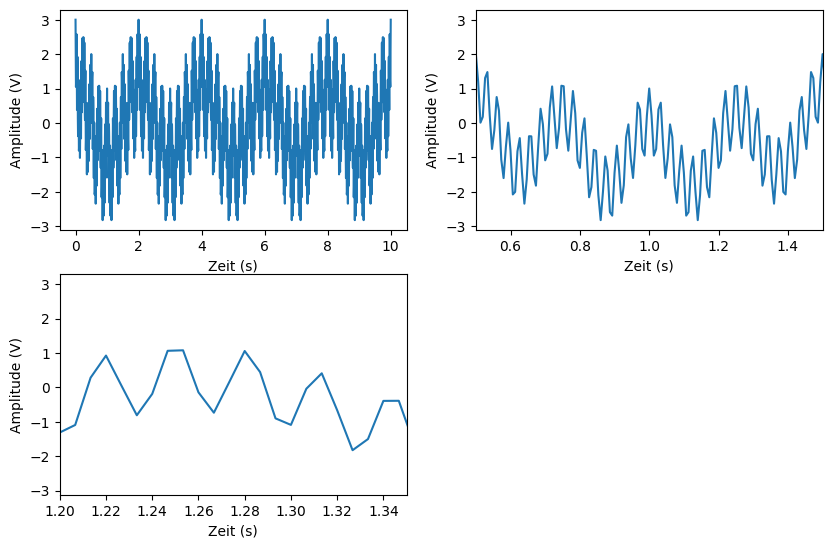

In [1249]:
data = np.loadtxt('data/signal.txt', skiprows=1)
t = data[0, :]
V = data[1, :]

cm = 1 / 2.54
fig = plt.figure(figsize=(25*cm, 16*cm))
ax = fig.add_subplot(2, 2, 1)
ax.plot(t, V)
ax.set_xlabel('Zeit (s)')
ax.set_ylabel('Amplitude (V)')

ax = fig.add_subplot(2, 2, 2)
ax.plot(t, V)
ax.set_xlabel('Zeit (s)')
ax.set_ylabel('Amplitude (V)')
ax.set_xlim(0.5, 1.5)

ax = fig.add_subplot(2, 2, 3)
ax.plot(t, V)
ax.set_xlabel('Zeit (s)')
ax.set_ylabel('Amplitude (V)')
ax.set_xlim(1.2, 1.35)

Im ersten Plot sehen wir eine Oszillation von etwa 2 s / 0.5 Hz, im zweiten von etwa 0.25 s / 4 Hz und im letzten  sieht man Peaks im Abstand von ca. 0.03 s / 33 Hz.

##  b)

Bestimmen Sie aufgrund der Zeitachse die Nyquist-Frequenz, sowie die Frequenzuflösung, die Sie für die Fouriertransformation erwarten.

###  Lösung

In [1250]:
f_ny = 1 / (2 * (t[1] - t[0]))
df = 1 / t[-1]

print('Die Nyquist-Frequenz ist: {:0.2f} Hz\nund die Frequenzauflösung beträgt: {:0.2f} Hz'.format(f_ny,df))

Die Nyquist-Frequenz ist: 75.00 Hz
und die Frequenzauflösung beträgt: 0.10 Hz


## c)

Berechnen Sie nun die Fouriertransformation der Daten. Unter `Implementation details` des obigen Links finden Sie, in welcher Reihenfolge die Amplituden von `np.fft.fft` zurückgegeben werden. Die Funktion `np.fft.fftfreq` gibt Ihnen die entsprechend geordnete Frequenzachse. Plotten Sie zuerst die Frequenzen $f_n$ selbst als Funktion des Index $n$ um zu veranschaulichen, wie die Daten geordnet sind, und dann die spektrale Leistungsdichte als Funktion der Frequenzen. Finden Sie die Frequenzen wieder, die Sie in a) gefunden haben?

### Lösung

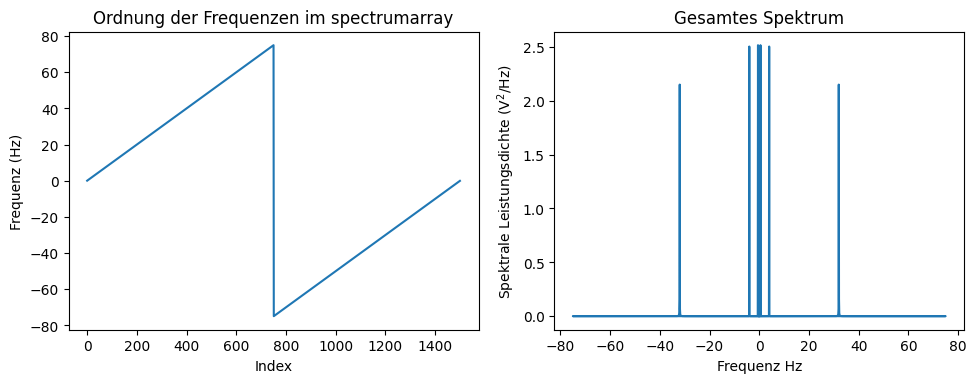

In [1251]:
N = len(t)
dt = t[1] - t[0]

# Berechnen der geordneten Frequenzachse
f = np.fft.fftfreq(N, dt)
# Berechnen der Fouriertransformation
spectrum = np.fft.fft(V)
# Berechnen der spektralen Leistungsdichte
psd = dt / N * np.abs(spectrum)**2

cm = 1 / 2.54
fig = plt.figure(figsize=(25*cm, 10*cm))
ax = fig.add_subplot(1, 2, 1)
ax.plot(f)
ax.set_xlabel('Index')
ax.set_ylabel('Frequenz (Hz)')
ax.set_title('Ordnung der Frequenzen im spectrumarray')

ax = fig.add_subplot(1, 2, 2)
ax.plot(f, psd)
ax.set_xlabel('Frequenz Hz')
ax.set_ylabel(r'Spektrale Leistungsdichte (V$^2$/Hz)')
ax.set_title('Gesamtes Spektrum')

fig.tight_layout()

Das Array beginnt bei 0, dann kommen zuerst die positiven Frequenzen bis $f_{\mathrm{Ny}}$. Danach kommen aufsteigend die negativen Frequenzen beginnend bei $-f_{\mathrm{Ny}}$.

Da wir ein reelles Signal anschauen, genügt es die positiven Frequenzen zu betrachten, denn es gilt dass $a_n=a_m^*$ wenn $f_n=-f_m$. Dies wird anschaulich, wenn man die Summe aus einer positiven und einer negativen Frequenz betrachtet:

$$ a_n e^{2\pi i f_n t} + a_m e^{2\pi i f_m t}=a_n e^{2\pi i f_n t} + a_n^* e^{-2\pi i f_n t} = 2|a_n|\cos(2\pi f_n t+\phi) \in \mathbb{R}.$$

Wenn man also nur auf die positiven Frequenzachse schaut und entsprechend die Achsen etwas vergrössert, sieht man die drei Frequenzen:

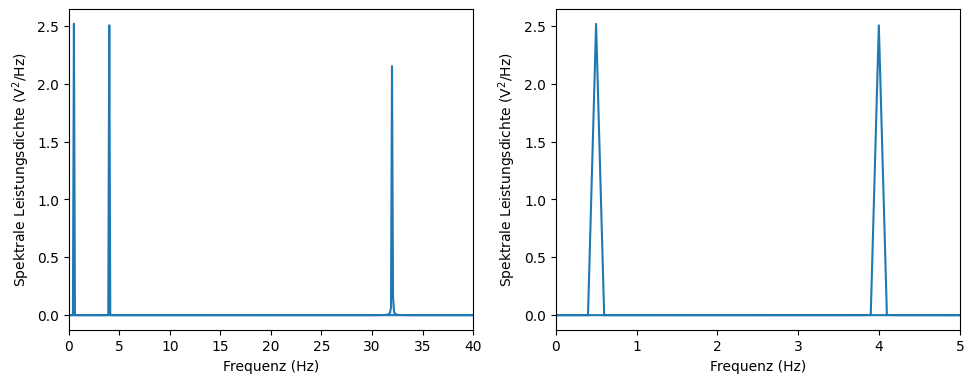

In [1252]:
cm = 1 / 2.54
fig = plt.figure(figsize=(25*cm, 10*cm))
ax = fig.add_subplot(1, 2, 1)
ax.plot(f, psd)
ax.set_xlim(0, 40)
ax.set_xlabel('Frequenz (Hz)')
ax.set_ylabel('Spektrale Leistungsdichte (V$^2$/Hz)')

ax = fig.add_subplot(1, 2, 2)
ax.plot(f, psd)
ax.set_xlim(0, 5)
ax.set_xlabel('Frequenz (Hz)')
ax.set_ylabel('Spektrale Leistungsdichte (V$^2$/Hz)')

fig.tight_layout()

Wenn wir nun nur die positiven Frequenzen plotten, sehen wir Peaks bei 0.5 Hz, 4 Hz und 32 Hz, was den Erwartungen von a) entspricht. Wir können auch überprüfen, dass die kleinste Frequenz grösser ist als die Auflösung.

###  d)

Betrachten Sie nochmals das Recktecksignal aus Aufgabe 1. Berechnen Sie die Fouriertransformation und plotten Sie die spektrale Leistungsdichte. Sie sollten das Verhalten der Amplituden aus Aufgabe 1 rekonstruieren können, sprich die Abnahme mit $1/n$ sowie, dass die Frequenzen mit geraden $n$ verschwindend klein sind. Da aber die Normierungskonvention der `numpy` Fouriertransformation sowie die Basis anders sind, wird die Grösse der Amplituden anders sein.

###  Lösung:

Text(0, 0.5, 'Spektrale Leistungsdichte (V$^2$/Hz)')

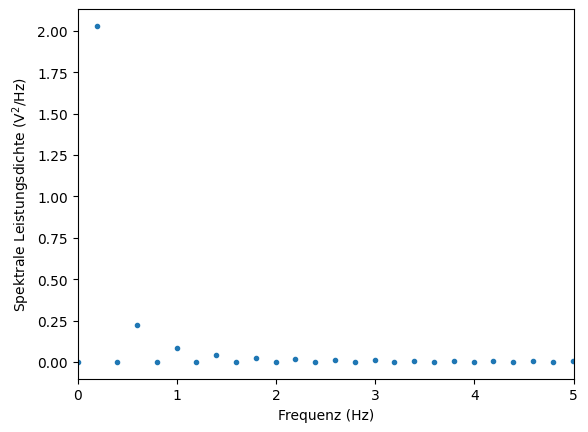

In [1253]:
# Laden der Daten
data = np.loadtxt('data/square.txt', skiprows=1)
t = data[0, :]
square = data[1, :]

N = len(t)
dt = t[1] - t[0]

# Berechnen der geordneten Frequenzachse
f = np.fft.fftfreq(N, dt)
# Berechnen der Fouriertransformation
spectrum = np.fft.fft(square)
# Berechnen der spektralen Leistungsdichte
psd = dt / N * np.abs(spectrum)**2

# Plotten
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.plot(f, psd,'.')
ax.set_xlim(0, 5)
ax.set_xlabel('Frequenz (Hz)')
ax.set_ylabel('Spektrale Leistungsdichte (V$^2$/Hz)')

Um das Spektrum mit den Amplituden aus Aufgabe 1 zu vergleichen, müssen wir das Spektrum wegen der unterschiedlichen Konventionen anders normieren.

Text(0, 0.5, 'Amplitude (V)')

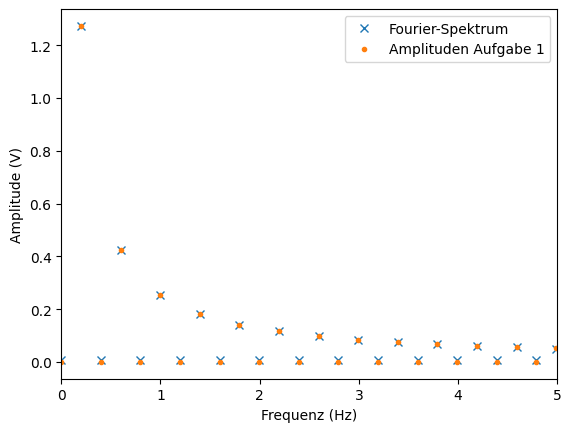

In [1254]:
# Amplituden wie in Aufgabe 1 angegeben:
N = len(f)
amplitudes = np.zeros(int(N/2))
for i in range(1, len(amplitudes), 2):
    amplitudes[i] = 4 / (np.pi * i)
    
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.plot(f, abs(spectrum) * 2 / len(spectrum), 'x', label='Fourier-Spektrum')
ax.plot(f[:int(N/2)], amplitudes, '.', label='Amplituden Aufgabe 1')
ax.legend()
ax.set_xlim(0, 5)
ax.set_xlabel('Frequenz (Hz)')
ax.set_ylabel('Amplitude (V)')

---

# Musterlösung 7

In [1255]:
import numpy as np
from numpy.fft import fftfreq, fft, ifft
import matplotlib.pyplot as plt

# Aufgabe 1: Glätten mit gleitendem Mittelwert

Eine einfache Methode, um das Rauschen in Daten zu reduzieren, ist, den gleitenden Mittelwert (moving average) zu bilden. Das heisst, jeder Datenpunkt $x_i$ wird durch den Mittelwert der benachbarten Datenpunkte ersetzt:

$$\tilde{x}_i = \mathrm{mean}(\{x_{i-\Delta}, \dots, x_{i+\Delta}\}),$$

wobei $x_i$ die gemessenen und $\tilde{x}_i$ die geglätteten Datenpunkte sind.

## a)

Schreiben Sie eine Funktion, die ein gegebenes Datenarray auf diese Weise glättet. Als Argumente sollen die Datenpunkte und die Anzahl Indizes, über die gemittelt wird, übergeben werden.

Überlegen Sie sich, wie Sie die Randwerte behandeln möchten (also Indizes $i=0, \dots, \Delta$ und $i=N-1-\Delta,\dots,N-1$). Es gibt verschiedene Möglichkeiten, die alle ihre Berechtigung haben.

### Lösung

Bei den Randwerten gibt es das Problem, dass der Bereich, über den gemittelt wird, über die Grenzen des Arrays herausragt. Typischerweise wird auf eine der folgenden drei Arten damit umgegangen:

- Man fängt erst beim index $i = \Delta$ mit dem Mitteln an und hört bei $i=N-1-\Delta$ auf. Das resultierende Array mit den geglätteten  Daten ist dann um $2\Delta$ Einträge kürzer als die originalen Daten.
- Man wiederholt den ersten und letzten Wert über die Grenzen des Arrays hinaus. So kann ein geglättetes Datenarray mit der gleichen Länge wie das Originalarray erzeugt werden.
- Man hängt die beiden Enden des Datenarrays zusammen und erzeugt sozusagen periodische Randbedingungen. Auf diese Weise kann das geglättete Array wieder die gleiche Länge haben wie das ursprüngliche. Diese Methode ist vor allem bei periodischen Signalen sinnvoll.

Unten finden Sie eine Funktion, bei der alle drei Varianten implementiert sind, und mit dem Argument `edges` die gewünschte Methode gewählt werden kann. In vielen Fällen kann man sich von Anfang an für eine Methode entscheiden, und muss den Code nicht so allgemein halten.

Für den Rest der Musterlösung werden wir die Methode 'repeat' verwenden, also den ersten und letzten Datenpunkt wiederholen.

In [1256]:
def moving_average(x, delta, edges='repeat'):
    '''Calculate moving average of data array x. Average goes from i-delta to i+delta for every i.
    The argument edges determines how the edge of the array is treated. Options are:
        'repeat': First or last value is repeated beyond array. Output array has same length as input array.
        'cut': Input array is not extended for averaging. Output array has length N-2*delta, where N is len(x).
        'wrap': Input array wraps around for averaging. Output array has same length as input array.'''
    
    N = len(x)
    
    filtered_array = np.zeros(N)
    
    if edges == 'repeat':
        # Original data starts at index delta, stops at delta+N-1
        padded_array = np.concatenate([
            np.ones(delta) * x[0],  # repeat first value at start
            x,
            np.ones(delta) * x[-1]  # repeat last value at end
        ])
    elif edges == 'cut':
        # We pad with zeros to be able to treat this case the same as the others while averaging.
        # We need to cut the start and end of the array before returning it.
        padded_array = np.concatenate([
            np.zeros(delta),
            x,
            np.zeros(delta)
        ])
    elif edges == 'wrap':
        padded_array = np.concatenate([
            x[-delta:],
            x,
            x[:delta]
        ])
    else:
        raise ValueError('Invalid argument edges="{}"'.format(edges))

    # Calculate moving average
    for i in range(N):
        filtered_array[i] = np.mean(padded_array[i:i+2*delta])

    # Cut invalid parts in case edges='cut'
    if edges == 'cut':
        filtered_array = filtered_array[delta:-delta]
        
    return filtered_array

## b)

Laden Sie den Datensatz `peaks.txt`, und plotten Sie das Signal als Funktion der Zeit. Wenden Sie dann Ihre Funktion darauf an, um die Daten zu glätten. Probieren Sie verschiedene Werte für die Breite $\Delta$ des gemittelten Bereichs und schauen Sie, welchen Einfluss diese auf das Resultat haben.

### Lösung

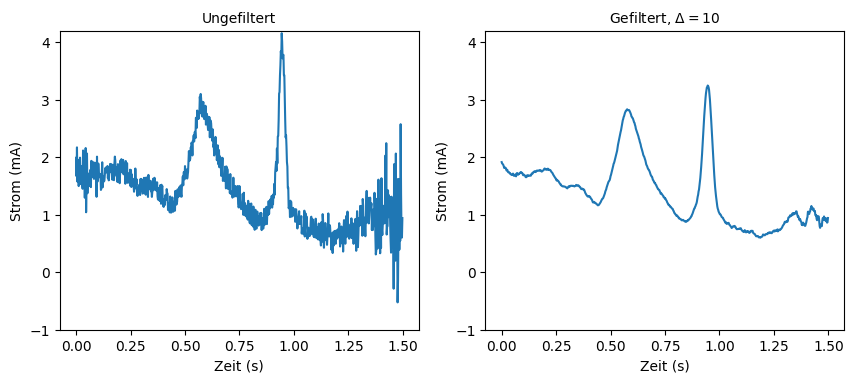

In [1257]:
data = np.loadtxt('data/peaks.txt')
t = data[:, 0]
signal = data[:, 1]

# Glätten
delta = 10
filtered_signal = moving_average(signal, delta)

# Plotten
cm = 1 / 2.54

fig = plt.figure(figsize=(22 * cm, 10 * cm))

ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(t, signal, '-')
ax1.set_title('Ungefiltert', size=10)

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(t, filtered_signal, '-')
ax2.set_title('Gefiltert, $\\Delta = {}$'.format(delta), size=10)

for ax in (ax1, ax2):
    ax.set_xlabel('Zeit (s)')
    ax.set_ylabel('Strom (mA)')
    ax.set_ylim(-1, 4.2)

fig.tight_layout()

Das Glätten entfernt das schnelle Rauschen, während die langsameren Ausschläge beibehalten werden. Je grösser $\Delta$ gewählt wird, desto glatter wird das Signal. Die Peaks werden allerdings durch das Mitteln verbreitert, wenn $\Delta$ zu gross gewählt wird (probieren Sie z.B. $\Delta = 20$).

## c)

Bei welchen Frequenzen erwarten Sie eine Änderung in der spektralen Leistungsdichte, wenn Sie das gefilterte Signal betrachten?

Berechnen Sie mithilfe der Fouriertransformation die spektrale Leistungsdichte des Originalsignals und des geglätteten Signals. Bestätigt sich Ihre Vermutung? Welchen Einfluss hat der Wert $\Delta$?

Hinweis: Sie müssen die y-Achse logarithmisch plotten oder stark vergrössern, um den Effekt zu sehen. Das Spektrum wird ansonsten von den tiefen Frequenzen dominiert, da das Signal grösstenteils konstant ist.

### Lösung

Da das Glätten wie oben erwähnt das schnelle Rauschen entfernt, ist eine Unterdrückung der hohen Frequenzkomponenten zu erwarten.

Hier wird die Glättung noch einmal ausgerechnet, damit Sie mit dem Wert `delta` herumspielen können. Die x-Achse ist auf die positiven Frequenzen gezoomt und die y-Achse auf den relevanten Wertebereich.

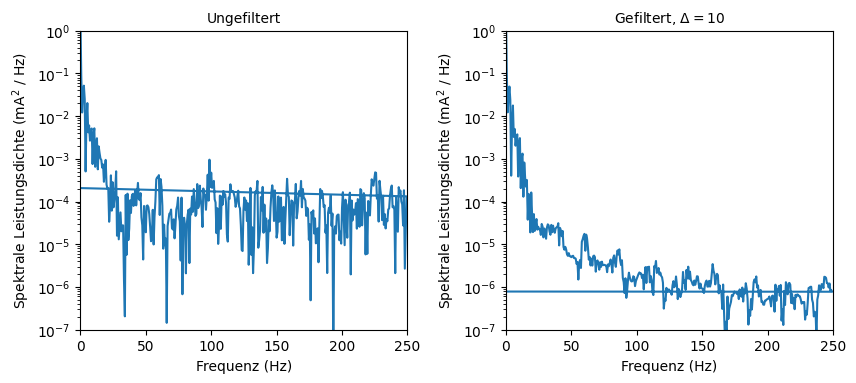

In [1258]:
N = len(signal)
dt = t[1] - t[0]

# Berechnen der Spectralen Leistungsdichte des orginal Signals
frequency = fftfreq(N, dt)
spectrum = fft(signal)
psd = dt / N * np.abs(spectrum)**2

# Berechnen der PSD des gefilterten Signals.
delta = 10
filtered_signal = moving_average(signal, delta)
filtered_spectrum = fft(filtered_signal)
filtered_psd = dt / N * np.abs(filtered_spectrum)**2

# Plotten
cm = 1 / 2.54

fig = plt.figure(figsize=(22 * cm, 10 * cm))

ax1 = fig.add_subplot(1, 2, 1)
ax1.semilogy(frequency, psd, '-')
ax1.set_title('Ungefiltert', size=10)

ax2 = fig.add_subplot(1, 2, 2)
ax2.semilogy(frequency, filtered_psd, '-')
ax2.set_title('Gefiltert, $\\Delta = {}$'.format(delta), size=10)

for ax in (ax1, ax2):
    ax.set_xlabel('Frequenz (Hz)')
    ax.set_ylabel('Spektrale Leistungsdichte (mA$^2$ / Hz)')
    ax.set_ylim(1e-7, 1)
    ax.set_xlim(0,  250)

fig.tight_layout()

Tatsächlich enfernt das Glätten die hohen Frequenzen aus dem Spektrum. Die Frequenzen, die gross genug sind, dass sie in dem Zeitbereich, über den gemittelt wird, mehrere Oszillationen haben, ergeben beim Mitteln Null, da sie etwa gleich oft positiv wie negativ ausschlagen. Dementsprechend ist ihr Beitrag im geglätteten Signal Null. Je höher die Frequenz, desto besser ist die Auslöschung der positiven und negativen Beiträge.

# Aufgabe 2: Filtern im Frequenzraum

In Aufgabe 1 haben Sie die Daten in der Zeitdomäne gefiltert und gesehen, wie sich das in der Frequenzdomäne wiederspiegelt. In dieser Aufgabe werden Sie die Daten in der Frequenzdomäne filtern und schauen, was der Effekt auf das zeitabhängige Signal ist.

## Hintergrund

In der Vorlesung haben Sie gesehen, dass man für die Bestimmung der Dauer eines kurzen Laserpulses dessen Autokovarianz oder Autokorrelation verwenden kann. Dies ist notwendig, weil Laserpulse viel kürzer (z.B. $150\,\mathrm{fs} = 150\cdot 10^{-15}\,\mathrm{s}$) sein können als die Abtastraten von Detektoren (bis zu GHz, also $\Delta t \sim 1\,\mathrm{ns} = 1\cdot 10^{-9}\,\mathrm{s}$).

In der Datei `autocorrelation_laser.txt` finden Sie eine Messung der Autokorrelation eines Laserpulses, die mit einem <a href=https://en.wikipedia.org/wiki/Michelson_interferometer>Michelson-Inteferometer</a> durchgeführt wurde. Das gemessene Signal hat die Einheit Volt und ist proportional zur Intensitätsautokorrelation des Laserlichts. Die Zeitachse entspricht der Zeitverzögerung zwischen den zwei Armen des Interferometers und damit der Zeitdifferenz zwischen den Laserpulsen, die miteinander interferieren.

## a)

Laden Sie den Datensatz `autocorrelation_laser.txt`, und berechnen Sie die Fouriertransformation des Signals. Plotten Sie dann sowohl das Signal als Funktion der Zeit, als auch die spektrale Leistungsdichte.

### Lösung

In [1259]:
data = np.loadtxt('data/autocorrelation_laser.txt')
t = data[:, 0] * 1e-12  # in ps abgespeichert. Wir konvertieren in s
signal = data[:, 1]

# Zeitauflösung und Länge des Signals berechnen
dt = t[1] - t[0]
N = len(t)

# Fouriertransformation
frequency = fftfreq(N, d=dt)
spectrum = fft(signal)

# Spektrale Leistungsdichte
psd = dt / N * np.abs(spectrum)**2

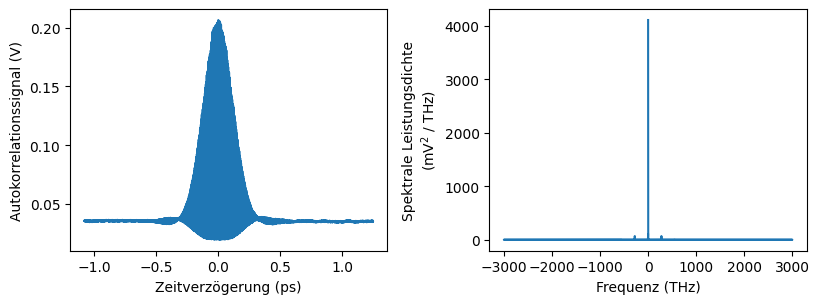

In [1260]:
cm = 1 / 2.54

fig = plt.figure(figsize=(21 * cm, 8 * cm))

ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(t * 1e12, signal, '-')
ax1.set_xlabel('Zeitverzögerung (ps)')
ax1.set_ylabel('Autokorrelationssignal (V)')

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(frequency / 1e12, psd * 1e12 * 1e6, '-')
ax2.set_xlabel('Frequenz (THz)')
ax2.set_ylabel('Spektrale Leistungsdichte\n(mV$^2$ / THz)')

fig.tight_layout()

Da das Signal immer positiv ist, sieht man im Spektrum einen dominanten Peak bei der Frequenz $f = 0$. Dieser Peak entspricht einem konstanten Offset und ist bei realen Messdaten in den meisten Fällen vorhanden.

Durch Vergrössern erkennt man im zeitabhängigen Signal die schnelle Oszillation innerhalb der Einhüllenden des Pulses. Im Spektrum wird durch logarithmisches Plotten die dominante endliche Frequenzkomponente bei $f \approx 280$ THz sichtbar, sowie deren höhere Harmonische, die allerdings um Grössenordnungen kleiner sind.

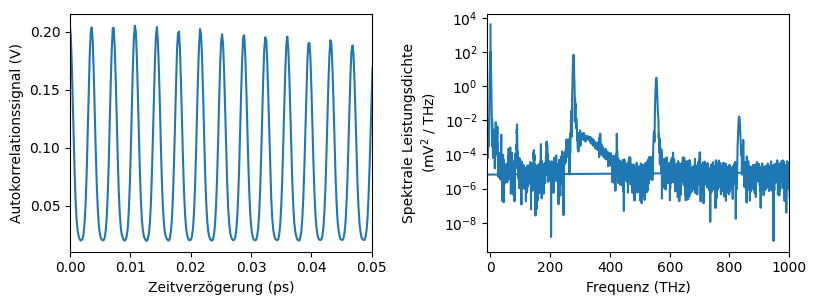

In [1261]:
cm = 1 / 2.54

fig = plt.figure(figsize=(21 * cm, 8 * cm))

ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(t * 1e12, signal, '-')
ax1.set_xlabel('Zeitverzögerung (ps)')
ax1.set_ylabel('Autokorrelationssignal (V)')

ax1.set_xlim(0, 0.05)


ax2 = fig.add_subplot(1, 2, 2)
ax2.semilogy(frequency / 1e12, psd * 1e12 * 1e6, '-')
ax2.set_xlabel('Frequenz (THz)')
ax2.set_ylabel('Spektrale Leistungsdichte\n(mV$^2$ / THz)')

ax2.set_xlim(-10, 1000)
# ax2.set_ylim(0, 100)

fig.tight_layout()

## b)

Berechnen Sie mit `np.fft.ifft` die Fourier-Rücktransformation, und plotten Sie diese als Funktion der Zeit, um sich zu vergewissern, dass Sie das ursprüngliche Signal rekonstruieren können.

### Lösung

Text(0, 0.5, 'Rekonstruiertes Signal U(t) (V)')

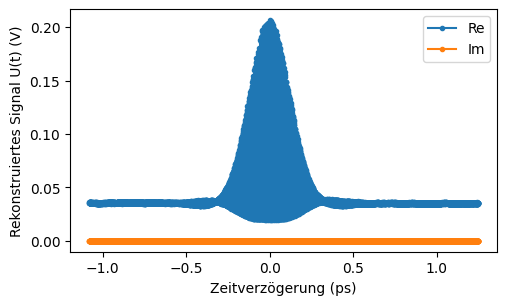

In [1262]:
signal_reconstruct = ifft(spectrum)

cm = 1 / 2.54
fig = plt.figure(figsize=(14 * cm, 8 * cm))

ax1 = fig.add_subplot(1, 1, 1)
# Wir plotten Realteil und Imaginärteil des rekonstruierten Signals, um zu überprüfen,
# dass das Signal rein reell ist.
ax1.plot(t * 1e12, np.real(signal_reconstruct), '.-', label='Re')
ax1.plot(t * 1e12, np.imag(signal_reconstruct), '.-', label='Im')
ax1.legend()
ax1.set_xlabel('Zeitverzögerung (ps)')
ax1.set_ylabel('Rekonstruiertes Signal U(t) (V)')

## c)

Schreiben Sie nun eine Funktion, die ein Signal im Frequenzraum filtert und das gefilterte Signal zurückgibt. Die Funktion soll als Argumente ein zeitabhängiges Signal nehmen (Zeitachse $t$, Messwerte $s(t)$), sowie die untere Grenze $f_{\mathrm{min}}$ und obere Grenze $f_{\mathrm{max}}$ eines Frequenzbereichs. Berechnen Sie die Fouriertransformation des Signals, und setzen Sie dann alle Frequenzen ausserhalb des Frequenzbereichs $[f_{\mathrm{min}}, f_{\mathrm{max}}]$ auf Null. Das gefilterte Signal erhalten Sie aus der Rücktransformation des modifizierten Spektrums.

Hinweis: Beachten Sie, dass auch negative Frequenzen vorkommen. Daher müssen Sie beim Filtern alle Frequenzen $f_n$ behalten, die 

$$ f_{\mathrm{min}} \leq \left| f_n \right| \leq f_{\mathrm{max}} $$

erfüllen.

### Lösung

In [1263]:
def filter_signal(t, signal, f_min, f_max):
    '''Filter a signal by keeping only Fourier components between f_min and f_max.'''
    # Zeitauflösung und Anzahl Punkte im Signal
    dt = t[1] - t[0]
    N = len(t)
    
    # Fouriertransformation
    frequency = fftfreq(N, d=dt)
    spectrum = fft(signal)
    
    # In einer for-Schleife werden alle Frequenzen durchlaufen. Wenn die Frequenz
    # ausserhalb des gewählten Bereichs liegt, wird die entsprechende Amplitude
    # auf Null gesetzt.
    for i in range(len(frequency)):
        if abs(frequency[i]) < f_min or f_max < abs(frequency[i]):
            spectrum[i] = 0
    
    # Rücktransformation des gefilterten Spektrums. Der Imaginärteil ist Null und kann
    # verworfen werden.
    filtered_signal = np.real(ifft(spectrum))
    return filtered_signal

## d)

Verwenden Sie Ihre Funktion aus c), um auf das Signal, das Sie in a) geladen haben, einen Tiefpassfilter anzuwenden (d.h. hohe Frequenzen über einem Grenzwert werden herausgefiltert). Plotten Sie das gefilterte Signal als Funktion der Zeit.

Was passiert, wenn Sie statt einem Tiefpassfilter einen Hochpassfilter anwenden (also Frequenzen unter dem Grenzwert herausfiltern)? Welches Signal würden Sie verwenden, um die Länge des Laserpulses zu bestimmen?

Hinweis: Wählen Sie den Grenzwert kleiner als die erste endliche Frequenzkomponente des Signals, so dass die oszillierenden und die nicht oszillierenden Teile des Signals getrennt werden.

### Lösung

Text(0, 0.5, 'Signal U(t) (V)')

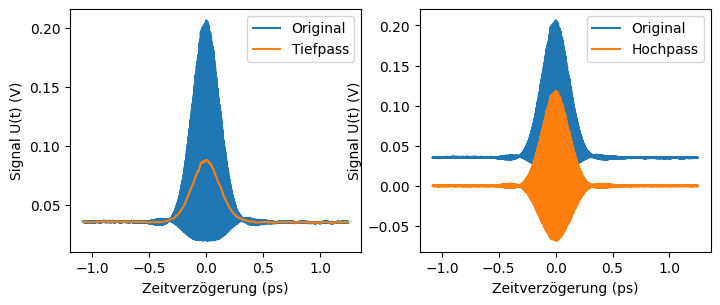

In [1264]:
cutoff = 150e12
f_ny = 1 / (2 * (t[1] - t[0]))

filtered_lowpass = filter_signal(t, signal, 0, cutoff)
filtered_highpass = filter_signal(t, signal, cutoff, f_ny)

cm = 1 / 2.54
fig = plt.figure(figsize=(21 * cm, 8 * cm))

ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(t * 1e12, signal, '-', label='Original')
ax1.plot(t * 1e12, filtered_lowpass, '-', label='Tiefpass')
ax1.legend()
ax1.set_xlabel('Zeitverzögerung (ps)')
ax1.set_ylabel('Signal U(t) (V)')

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(t * 1e12, signal, '-', label='Original')
ax2.plot(t * 1e12, filtered_highpass, '-', label='Hochpass')
ax2.legend()
ax2.set_xlabel('Zeitverzögerung (ps)')
ax2.set_ylabel('Signal U(t) (V)')

Um die zwei Frequenzkomponenten des Signals zu trennen, kann für den Filter irgendein Grenzwert zwischen ca. 5 THz und 270 THz gewählt werden. Mit dem Tiefpassfilter kann man die Einhüllende des Pulses extrahieren (bis auf einen Skalierungsfaktor). Diese kann dann weiter analysiert werden, um die Pulslänge zu bestimmen. Zum Beispiel kann sie mit einer Gaussfunktion angenähert werden, oder die Breite auf halber Höhe kann numerisch ermittelt werden.

## e)

Laden Sie nun den Datensatz `noisy_pulse.txt`, und plotten Sie wieder das Signal als Funktion der Zeit und die spektrale Leistungsdichte. Lesen Sie aus dem Spektrum die dominante Frequenzkomponente ab, und verwenden Sie Ihre Funktion aus c), um einen Bandpassfilter in diesem Frequenzbereich auf die Daten anzuwenden; d.h. Sie behalten nur die Frequenzen aus einem kleinen Bereich rund um die dominante Frequenzkomponente.

Hinweis: Sie sollten nach Anwenden des Filters eine Oszillation mit einer gaussförmigen Einhüllenden bekommen.

### Lösung

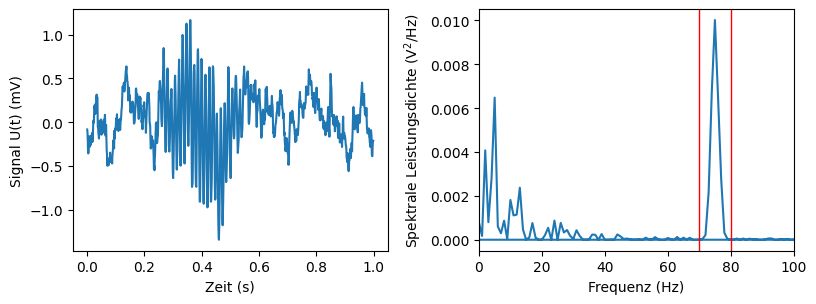

In [1265]:
# Daten laden
data = np.loadtxt('data/noisy_pulse.txt')
t = data[:, 0]
signal = data[:, 1]

# Fouriertransformation und spektrale Leistungsdichte
N = len(t)
dt = t[1] - t[0]

frequency = fftfreq(N, dt)
spectrum = fft(signal)
psd = dt / N * np.abs(spectrum)**2


# Daten Plotten
cm = 1 / 2.54

fig = plt.figure(figsize=(21 * cm, 8 * cm))

ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(t, signal, '-')
ax1.set_xlabel('Zeit (s)')
ax1.set_ylabel('Signal U(t) (mV)')

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(frequency, psd, '-')
ax2.set_xlabel('Frequenz (Hz)')
ax2.set_ylabel('Spektrale Leistungsdichte (V$^2$/Hz)')
ax2.set_xlim(0, 100)

ax2.axvline(70, color='r', linewidth=1)
ax2.axvline(80, color='r', linewidth=1)

fig.tight_layout()

Man sieht im originalen Signal, dass zwischen 0.3 s und 0.6 s etwas passiert, allerdings ist das Rauschen relativ gross. Die dominante Signalfrequenz ist zwischen 70 Hz und 80 Hz, während das Rauschen vor allem bei niedrigen Frequenzen gross ist. Dass die niedrigen Frequenzen nur Rauschen enthalten, können Sie auch mit einem Tiefpassfilter überprüfen.

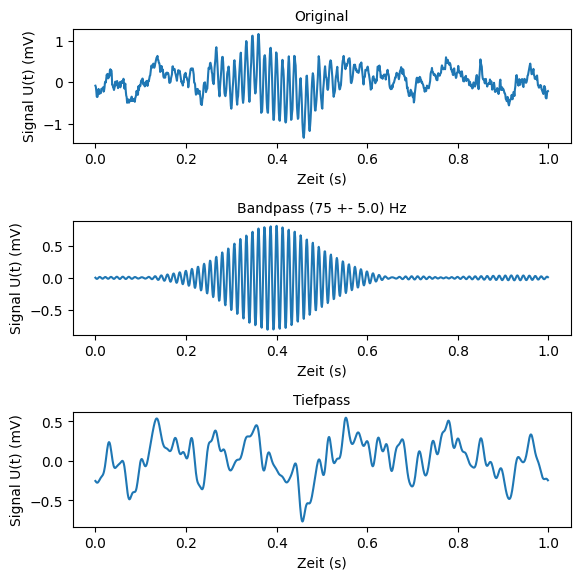

In [1266]:
center = 75
width = 10
bandpass_signal = filter_signal(t, signal, center - width / 2, center + width / 2)
lowpass_signal = filter_signal(t, signal, 0, 60)

cm = 1 / 2.54

fig = plt.figure(figsize=(15 * cm, 15 * cm))

ax1 = fig.add_subplot(3, 1, 1)
ax1.plot(t, signal, '-')
ax1.set_xlabel('Zeit (s)')
ax1.set_ylabel('Signal U(t) (mV)')
ax1.set_title('Original', size=10)

ax2 = fig.add_subplot(3, 1, 2)
ax2.plot(t, bandpass_signal, '-')
ax2.set_xlabel('Zeit (s)')
ax2.set_ylabel('Signal U(t) (mV)')
ax2.set_title('Bandpass ({} +- {}) Hz'.format(center, width/2), size=10)

ax3 = fig.add_subplot(3, 1, 3)
ax3.plot(t, lowpass_signal, '-')
ax3.set_xlabel('Zeit (s)')
ax3.set_ylabel('Signal U(t) (mV)')
ax3.set_title('Tiefpass', size=10)

fig.tight_layout()

Man sieht, dass die schnelle Oszillation von einem Puls bei 0.4 s kommt. Nach Anwenden des Bandpassfilters ist die Form des Pulses wieder erkennbar, und man könnte z.B. wieder dessen Länge bestimmen.

# Nachbemerkung

Bei all diesen Aufgaben war immer von einem zeitabhängigen Signal die Rede, so dass das Spektrum auch echten Frequenzen entspricht. Allerdings ist dies nicht nötig, um diese Methoden anzuwenden; sie funktionieren für jedes Array von Datenpunkten, unabhängig davon, was die x-Achse dazu ist. Tatsächlich waren die Daten aus Aufgabe 1 nicht ein zeitabhängiges Signal, sondern ein optisches Reflexionsspektrum und die x-Achse entspricht in Wirklichkeit einer Wellenlänge. Dennoch kann man die Daten durch Mitteln oder Tiefpassfiltern im Fourier-Raum glätten.

---

# Musterlösung 8

In [1267]:
import numpy as np
import matplotlib.pyplot as plt

# Aufgabe 1 Wahrscheinlichkeitsmassenfunktion

Wie Sie aus der Vorlesung wissen, gibt die Wahrscheinlichkeitsmassenfunktion (probability mass function, kurz PMF) die Wahrscheinlichkeit an, mit der ein bestimmter Wert z.B. in einem Datensatz vorkommt. Sie ist für diskrete Wahrscheinlichkeitsverteilungen das Analogon zur Wahrscheinlichkeitsdichtefunktion.

### a)

Schreiben Sie eine Funktion, die die Wahrscheinlichkeitsmassenfunktion für einen Datensatz berechnet. Die Diskretisierung der Daten wird durch die Auflösung der Messung oder allfälliges späteres Binning gegeben sein. Die Funktion sollte also die Daten sowie die Auflösung der Daten als Argument nehmen und die möglichen Werte mit den dazugehörigen Wahrscheinlichkeiten zurückgeben.

Sie können dazu die `np.histogramm` Funktion benutzen. Beachten Sie dabei, dass Sie die Bins richtig definieren. Falls `bins = [1, 2, 3]` dann ist das erste Bin durch die Grenzen `[1, 2)` und das zweite durch `[2, 3)` gegeben.


### Lösung

In [1268]:
def PMF(data, resolution):
    # Definieren der Bins und Berechnen des Histogramms
    # Wir addieren resolution / 1000 zur Obergrenze, um sicherzustellen, dass der letzte Wert auch im Array ist.
    bin_centers = np.arange(np.min(data), np.max(data) + resolution / 1000, resolution)
    bin_edges = np.linspace(bin_centers[0] - resolution / 2,
                            bin_centers[-1] + resolution / 2,
                            len(bin_centers) + 1)
    
    hist, _ = np.histogram(data, bin_edges)
    
    # Normieren
    px = hist / np.sum(hist)
    
    return bin_centers, px

### b)

In der Datei `Voltages.txt` finden Sie zwei Datensätze mit Spannungen mit einer Auflösung von 10mV als Funktion der Zeit. Laden Sie die Datensätze, berechnen Sie jeweils die PMF und stellen Sie sie graphisch dar. Überprüfen Sie dabei Ihre Funktion, indem Sie die Summe über alle Wahrscheinlichkeiten berechnen. Welchen Wert sollten Sie erhalten?

### Lösung

In [1269]:
data = np.loadtxt('data/voltages_pmf.txt', skiprows=1)
time = data[0, :]
V1 = data[1, :]
V2 = data[2, :]
resolution = 1e-2

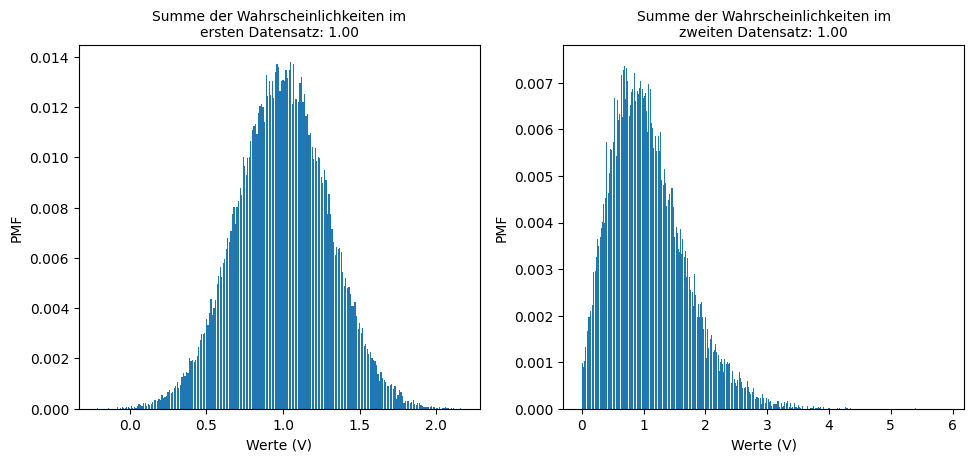

In [1270]:
cm = 1 / 2.54
fig = plt.figure(figsize=(25*cm, 12*cm))

ax = fig.add_subplot(1, 2, 1)
x, px = PMF(V1, resolution)
ax.bar(x, px, resolution*0.8)
ax.set_xlabel('Werte (V)')
ax.set_ylabel('PMF')
ax.set_title('Summe der Wahrscheinlichkeiten im\nersten Datensatz: {:.2f}'.format(np.sum(px)), size=10)

ax = fig.add_subplot(1, 2, 2)
x, px = PMF(V2, resolution)
ax.bar(x, px, resolution*0.8)
ax.set_xlabel('Werte (V)')
ax.set_ylabel('PMF')
ax.set_title('Summe der Wahrscheinlichkeiten im\nzweiten Datensatz: {:.2f}'.format(np.sum(px)), size=10)
#ax.set_xlim(0.8,1.2)

fig.tight_layout()

Die Summe über alle Wahrscheinlichkeiten ergibt wie erwartet 1.

### c)

Sie haben in der Vorlesung die Begriffe Mode, Median und Mittelwert kennengelernt. Schreiben Sie eine Funktion, die ein Set an Daten und deren Auflösung als Argument nimmt und die Mode und den Median der Daten zurückgibt. Sie können zur Hilfe auch geeignete Numpy Funktionen verwenden.

### Lösung

In [1271]:
def mode(data, resolution):
    # Berechnen der PMF
    x, px = PMF(data, resolution)
    # Der Wahrscheinlichste Wert ist derjenige, bei dem die PMF ein Maximum hat. 
    return x[np.argmax(px)]


def mode_manual(data, resolution):
    # Berechnen der PMF
    x, px = PMF(data, resolution)
    
    max_x = 0
    max_val = px[0]
    # Iteration durch das Array, um die höchste Wahrscheindlichkeit und den dazugehörigen Wert zu finden. 
    for i, val in enumerate(px):
        if val > max_val:
            max_val = val
            max_x = x[i]
            
    return max_x


def median(data, resolution):
    # Wir berechnen zuerst die PMF
    x, px = PMF(data, resolution)
    # Wir summieren die Wahrscheinlichkeiten auf, bis wir 50% erreicht haben, der Median entspricht
    # dem Wert bei 50%.
    curr_sum = 0
    for i in range(len(x)):
        curr_sum += px[i]
        if curr_sum >= 0.5:
            break
    return x[i]


def mediansort(data):
    # Wir sortieren die Daten, der Median entspricht dem Datenpunkt in der Mitte.
    data_sorted = np.sort(data)
    if len(data) % 2 != 0:
        median = data_sorted[len(data)//2]
    # Bei gerader Anzahl Datenpunkten mitteln wir über die beiden benachbarten Punkte.
    else:
        median = (data_sorted[len(data)//2] + data_sorted[len(data)//2 - 1]) / 2
    return median

### d)

Plotten Sie nun die Mode, den Median und den Mittelwert der Datensätze in die PMF. Was für Unterschiede werden deutlich?

### Lösung

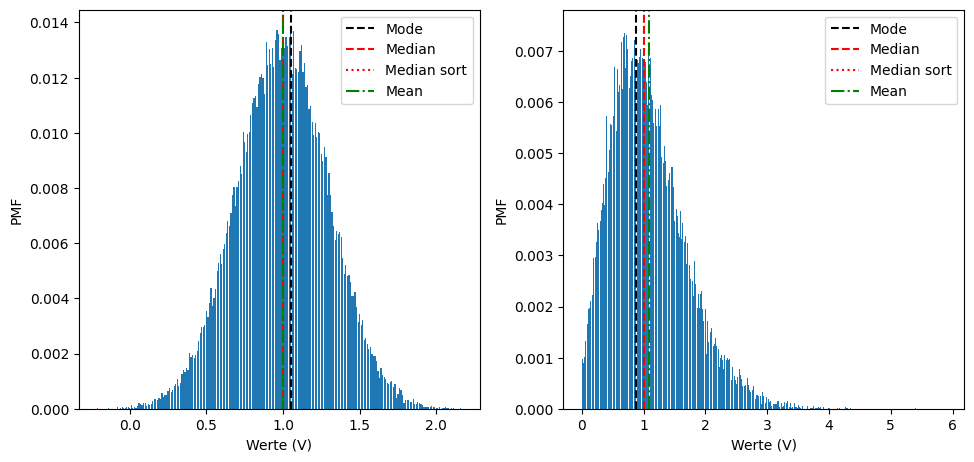

In [1272]:
fig = plt.figure(figsize=(25*cm, 12*cm))

x, px = PMF(V1, resolution)

ax = fig.add_subplot(1,2,1)
ax.bar(x, px, resolution*0.8)

ax.axvline(mode(V1, resolution), color='k', linestyle='--', label='Mode')
ax.axvline(median(V1, resolution), color='r', linestyle='--', label='Median')
ax.axvline(mediansort(V1), color='r', linestyle=':', label='Median sort')
ax.axvline(np.mean(V1), color='g', linestyle='-.', label='Mean')

ax.set_xlabel('Werte (V)')
ax.set_ylabel('PMF')
#ax.set_xlim(0.975,1.02)
ax.legend()


x, px = PMF(V2, resolution)

ax = fig.add_subplot(1,2,2)
ax.bar(x, px, resolution*0.8)

ax.axvline(mode(V2, resolution), color='k', linestyle='--', label='Mode')
ax.axvline(median(V2, resolution), color='r', linestyle='--', label='Median')
ax.axvline(mediansort(V2), color='r', linestyle=':', label='Median sort')
ax.axvline(np.mean(V2), color='g', linestyle='-.', label='Mean')

ax.set_xlabel('Werte (V)')
ax.set_ylabel('PMF')
#ax.set_xlim(0.975,1.02)
ax.legend()

fig.tight_layout()

Im Vergleich zum symmetrisch verteilten Datensatz entspricht die Mode beim asymmetrischen Datensatz einem deutlich anderen Wert als der Mittelwert und der Median. Grund dafür ist die erhöhte Wahrscheinlichkeit, Werte zu finden, die rechts vom Maximum der Wahrscheinlichkeitsverteilung liegen, also grösser als der wahrscheinlichste Wert sind.

### e)

Eine wichtige Kenngrösse einer Verteilung ist deren Breite, und eine häufig verwendete Definition dafür ist die Breite auf halber Höhe (full width at half maximum oder kurz FWHM). Schreiben Sie eine Funktion, die die FWHM für eine Verteilung berechnet, die ein einzelnes Maximum aufweist. Für Datensätze mit starkem Rauschen kann das Finden des halben Wertes komplizierter werden. Sie haben bereits Methoden gesehen, wie man Daten glätten kann, nehmen Sie also für diese Aufgabe an, dass das Rauschen der Daten kleiner ist als deren Auflösung.

### Lösung

In [1273]:
def FWHM1(x, y):
    # Definieren eines Arrays, in das alle Indizes gespeichtert werden, bei denen y>=y/2
    larger_idx = np.array([],dtype=int)
    for i in range(len(y)):
        if y[i] >= np.max(y)/2:
            larger_idx = np.append(larger_idx, i)
            
    # Die FWHM ist dann x beim letzten dieser Indizes minus x beim ersten
    x0 = x[larger_idx[0]]
    x1 = x[larger_idx[-1]]
    return abs(x1 - x0)


def FWHM2(x, y):
    # np.where findet alle Werte, die die gegebene Bedingung erfüllen, und gibt deren Indizes aus.
    # Wir wählen also den ersten und letzten Wert, der grösser ist als die Hälfte des Maximums,
    # und geben deren Abstand wieder. 
    x0 = x[np.where(px >= np.max(y)/2)[0][0]]
    x1 = x[np.where(px >= np.max(y)/2)[0][-1]]
    return abs(x1 - x0)

### f)

Berechnen Sie die FWHM der PMF der Daten aus den beiden Datensätzen. Für normalverteilte Daten kann die FWHM auch analytisch berechnet werden. Dabei gilt, dass $\mathrm{FWHM} = 2\sigma\sqrt{2\log{2}}$, wobei $\sigma$ die Wurzel der Varianz ist. Vergleichen Sie das Resultat Ihrer Funktion mit der FWHM, die Sie aus der Varianz berechnen. Können Sie die Abweichungen erklären? (Der symmetrische Datensatz ist Normalverteilt.)

### Lösung

Erster Datensatz:
FWHM: 0.660000
sigma: 0.299801 -> FWHM = 0.705977
Zweiter Datensatz:
FWHM: 1.340000
sigma: 0.611588 -> FWHM = 1.440180


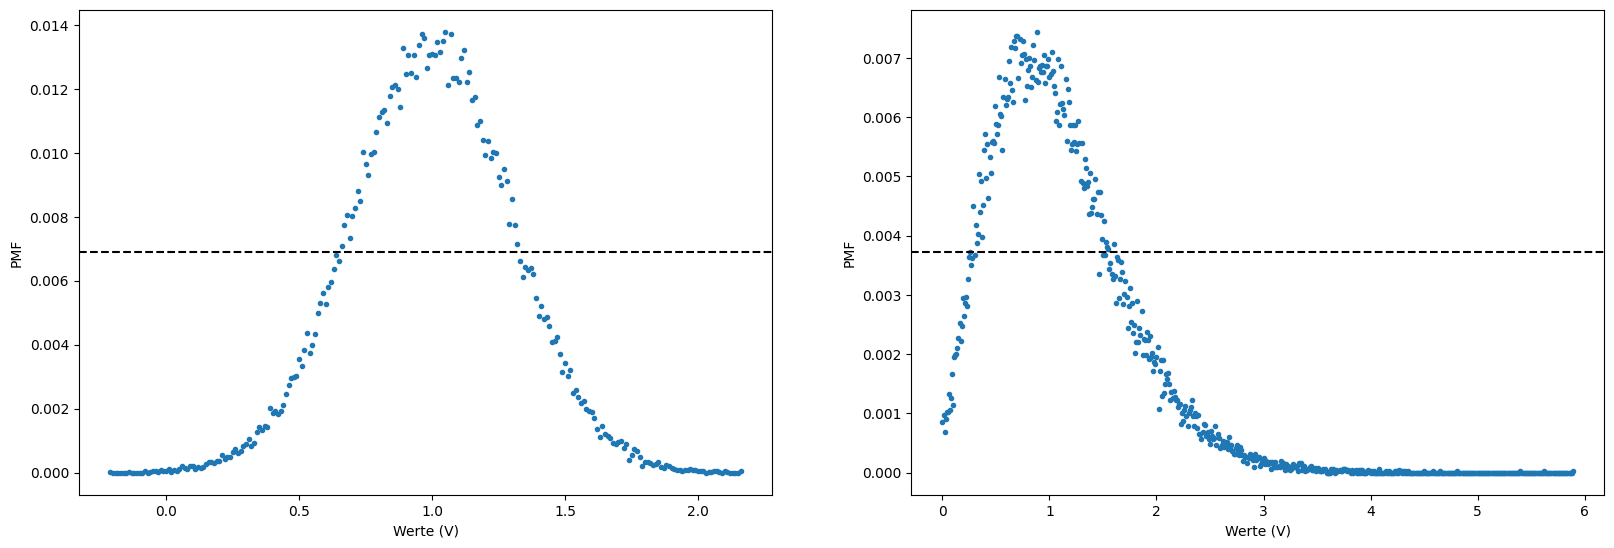

In [1274]:
fig = plt.figure(figsize=(50*cm, 16*cm))

ax = fig.add_subplot(1, 2, 1)
x, px = PMF(V1, resolution)

fwhm = FWHM2(x, px)
sigma = np.sqrt(np.var(V1))

ax.plot(x, px, '.')
ax.axhline(np.max(px) / 2, color='k', linestyle='--')

ax.set_xlabel('Werte (V)')
ax.set_ylabel('PMF')

print('Erster Datensatz:')
print('FWHM: {:f}'.format(fwhm))
print('sigma: {:f} -> FWHM = {:f}'.format(sigma, 2*np.sqrt(2*np.log(2))*sigma ) )


ax = fig.add_subplot(1, 2, 2)
x, px = PMF(V2, resolution)

fwhm = FWHM2(x, px)
sigma = np.sqrt(np.var(V2))

ax.plot(x, px, '.')
ax.axhline(np.max(px)/2, color='k', linestyle='--')

ax.set_xlabel('Werte (V)')
ax.set_ylabel('PMF')

print('Zweiter Datensatz:')
print('FWHM: {:f}'.format(fwhm))
print('sigma: {:f} -> FWHM = {:f}'.format(sigma, 2*np.sqrt(2*np.log(2))*sigma ) ) 

Die Abweichung zwischen den FWHM Werten, die aus der Varianz berechnet und mit der Funktion extrahiert wurden, sind in beiden Fällen ähnlich gross. Die Abweichung im asymmetrischen Datensatz ist zu erwarten, da die Daten nicht Normalverteilt sind. Da es im symmetrischen Fall ähnlich ist, ist es aber wahrscheinlicher, dass der Unterschied durch das Rauschen zustande kommt.

#  Aufgabe 2 Momente

Momente sind charakteristische Grössen für Zufallsvariablen und sind verknüpft mit Erwartungswert, Varianz, Schiefe etc. In der Vorlesung haben Sie die Formel für das n-te Moment von diskrete Zufallsvariablen gesehen:

$$m_n = \sum_{i=0}^{N}x^n_ip_i,$$

wobei der Wert $x_i$ mit Wahrscheinlichkeit $p_i$ im Datensatz vorkommt. Da $p_i = \frac{n_i}{M}$, wobei $M$ die Länge des Datenarrays und $n_i$ die Anzahl Datenpunkte $X_j$ mit Wert $x_i$ im Datenarray ist, kann man das n-te Moment auch via:

$$ m_n =\frac{1}{M}\sum_{j=0}^{M}X_j^n $$
berechnen. Dies hat den Vorteil, dass man nicht auf ein Binning angewiesen ist.

### a)

Schreiben Sie eine Funktion, die das n-te Moment aus einem Datensatz berechnet.

### Lösung

In [1275]:
def moment(data, n):
    return np.sum(data**n)/len(data)

### b)

Die ersten beiden Momente hängen mit dem Mittelwert und der Varianz zusammen. Berechnen Sie für die beiden Datensätze Mittelwert und Varianz einmal über die Momente und einmal mit Numpy und vergleichen Sie die Werte.

### Lösung

In [1276]:
# Berechnen des ersten Moments
m1 = moment(V1, 1)
# Die Varianz entspricht dem zweiten zentralen Moment
mu1 = moment(V1-m1, 2)
print('Mittelwert aus den Momenten:    {:0.3f}    und mit Numpy:    {:0.3f}'.format(m1, np.mean(V1)))
print('Varianz aus den Momenten:       {:0.3f}    und mit Numpy:    {:0.3f}'.format(mu1, np.var(V1)))


m1 = moment(V2, 1)
m2 = moment(V2, 2)
# Die Varianz kann auch aus den ersten beiden Momenten direkt berechnet werden
mu2 = m2-m1**2
print('Mittelwert aus den Momenten:    {:0.3f}    und mit Numpy:    {:0.3f}'.format(m1, np.mean(V2)))
print('Varianz aus den Momenten:       {:0.3f}    und mit Numpy:    {:0.3f}'.format(mu2, np.var(V2)))

Mittelwert aus den Momenten:    0.998    und mit Numpy:    0.998
Varianz aus den Momenten:       0.090    und mit Numpy:    0.090
Mittelwert aus den Momenten:    1.084    und mit Numpy:    1.084
Varianz aus den Momenten:       0.374    und mit Numpy:    0.374


### c)

Die höheren Momente geben zusätzliche Informationen über die Symmetrie und die Breite der Verteilung. Berechnen und vergleichen Sie die ersten drei zentralen Momente für die beiden Datensätze.

### Lösung

In [1277]:
m1_1 = moment(V1, 1)
m1_2 = moment(V2, 1)
for i in range(3):
    n = i+1
    mi_1 = moment(V1-m1_1, n)
    mi_2 = moment(V2-m1_2, n)
    print('{:n}-tes zentrales Moment vom ersten Datensatz: {:0.3f}, vom zweiten Datensatz: {:0.3f}'.format(n, mi_1, mi_2))

1-tes zentrales Moment vom ersten Datensatz: 0.000, vom zweiten Datensatz: -0.000
2-tes zentrales Moment vom ersten Datensatz: 0.090, vom zweiten Datensatz: 0.374
3-tes zentrales Moment vom ersten Datensatz: 0.000, vom zweiten Datensatz: 0.202


Die ersten zwei zentralen Momente zeigen wie erwartet 0 und die Varianz. Das dritte zentrale Moment ist 0 für die symmetrische Funktion und endlich für die asymmetrische, es ist also ein Mass für die Schiefe der Verteilung.

---

# Musterlösung 9

In [1278]:
import numpy as np
import matplotlib.pyplot as plt

In [1279]:
def PMF(data, resolution):
    # Definieren der Bins und Berechnen des Histogramms
    # Wir addieren resolution / 1000 zur Obergrenze, um sicherzustellen, dass der letzte Wert auch im Array ist.
    bin_centers = np.arange(np.min(data), np.max(data) + resolution / 1000, resolution)
    bin_edges = np.linspace(bin_centers[0] - resolution / 2,
                            bin_centers[-1] + resolution / 2,
                            len(bin_centers) + 1)
    
    hist, _ = np.histogram(data, bin_edges)
    
    # Normieren
    px = hist / np.sum(hist)
    
    return bin_centers, px

## Aufgabe 1

In dieser Aufgabe werden wir uns mit der Gaussschen Normalverteilung vertraut machen. Dazu werden wir Daten analysieren, die aus einer Normalverteilung stammen, und diese plotten.\
Zur Erinnerung: Die Wahrscheinlichkeitsdichtefunktion der Gaussschen Normalverteilung ist definiert als $$ f(x) = {1 \over \sqrt{2\pi\sigma^2}} e^{-{1 \over 2}{(x-\mu)^2 \over \sigma^2}}$$

### a)
Ihre Aufgabe besteht darin, eine Funktion zu vervollständigen, die die Wahrscheinlichkeitsmassefunktion (PMF) einer Normalverteilung an den Stellen der Werte im Vektor x zurückgibt. Die Normalverteilung soll dabei einen Mittelwert `mu` und eine Standardabweichung `sigma` haben.
\
**Hinweis:** Die Wahrscheinlichkeitsdichtefunktion und die Wahrscheinlichkeitsmassefunktion unterscheiden sich in einem kleinen Detail der Implementierung

### Lösung

In [1280]:
def normal_pmf(x, mu, sigma, binsize):
    # Wir approximieren die PMF der Gausschen Normalverteilung. Warum dies lediglich eine 
    # Approximation ist, ist im Zusatz Notebook Histogramme beschrieben.
    return 1/np.sqrt(2*np.pi*sigma**2)*np.exp(-1/2*((x-mu)**2/(sigma**2)))*binsize

### b)
Ziehen Sie 1000 Werte aus einer Normalverteilung (Sie können dazu die Funktion `numpy.random.normal` verwenden). Plotten Sie das Histogramm dieser Zufallswerte und überlagern Sie einen Plot der entsprechenden PMF mit denselben Parametern. Zur Darstellung der PMF der Zufallswerte können Sie die oben definierte PMF-Funktion verwenden.\
\
Ändern Sie die Anzahl der Zufallswerte, die Sie für Ihr Histogramm verwenden, um ein Gefühl zu erhalten, wie die Verteilung mit zunehmender Anzahl an Datenpunkten immer besser die Normalverteilung abbildet.

### Lösung

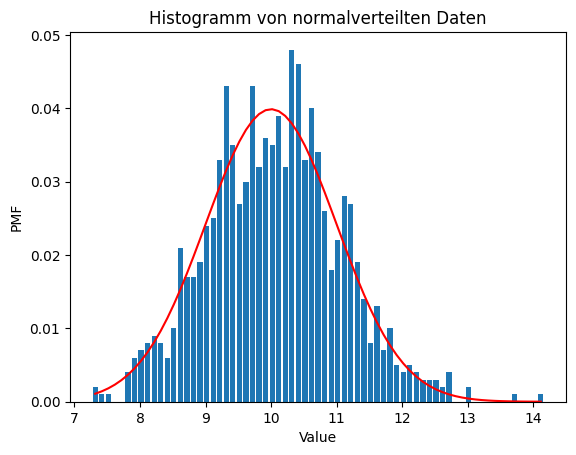

In [1281]:
mu = 10
sigma = 1
# Wir ziehen Samples aus einer Gaussschen Normalverteilung mit Mittelwert mu und Standardabweichung sigma. 
normal_data = np.random.normal(mu, sigma, 1000)

binsize = 0.1
x, px = PMF(normal_data, binsize)
plt.figure()
plt.bar(x, px, width=0.08)
plt.xlabel('Value')
plt.ylabel('PMF')
plt.title('Histogramm von normalverteilten Daten')

# Überlagern des Histogramms mit der erwarteten PMF der gezogenen Daten.
plt.plot(x,normal_pmf(x,mu,sigma,binsize),'r')

## Aufgabe 2: Zentraler Grenzwertsatz

Der zentrale Grenzwertsatz ist ein wichtiges Resultat der Wahrscheinlichkeitstheorie. Wie in der Vorlesung vermittelt besagt er, dass sich die Verteilung der Mittelwerte von Stichproben einer Gaussschen Normalverteilung annähern werden, sofern die Zufallsvariablen unabhängig und identisch verteilt sind. Dies ist unabhängig von der Verteilung der unterliegenden Daten.

In der Datei 'NASA_small_body_data_period.txt' sind die Umlaufzeiten der meisten bekannten kleineren Objekte in unserem Sonnensystem enthalten. Im folgenden werden wir uns mit derer Verteilung beschäftigen. 

### a)

Laden Sie den Datensatz 'NASA_small_body_data_period.txt', und stellen Sie die Verteilung der Umlaufzeiten in einem Plot dar. Wie würden Sie diese Verteilung beschreiben? Ist diese Verteilung eine Gaussche Normalverteilung? Wenn ja, was ist deren Mittelwert und Standardabweichung? Wenn nein, haben Sie eine Idee warum dies nicht der Fall ist?


### Lösung

Text(0.5, 1.0, 'Umlaufzeiten der kleinen Objekte im Sonnensystem')

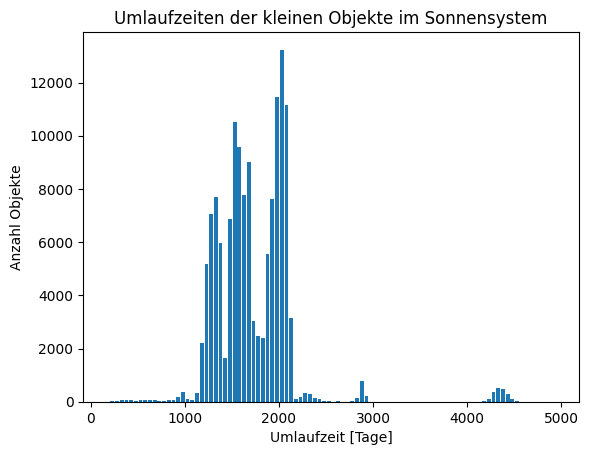

In [1282]:
data = np.loadtxt('data/nasa_periods.txt', skiprows=1)


resolution = 50
x, px = PMF(data, resolution)
# Um die Anzahl an Objekten pro Bin zu erhalten, müssen wir die PMF mit der Gesamtanzahl der Objekte multiplizieren.
px = px*np.size(data)

# Plotten
plt.figure()
plt.bar(x, px, width=0.8*resolution)
plt.xlabel('Umlaufzeit [Tage]')
plt.ylabel('Anzahl Objekte')
plt.title('Umlaufzeiten der kleinen Objekte im Sonnensystem')

Die Umlaufzeiten sind nicht Normalverteilt. Dies kommt daher, dass Himmelskörper, welche eine Umlaufzeit haben, die im Vergleich zu derjeniger von Jupiter als Verhältnis natürlicher Zahlen beschrieben werden kann, in eine instabile Resonanzbedingung mit diesem eingehen und solange durch Austausch von Impuls mit Jupiter beschleunigt oder gebremst werden, bis sie diese Resonanzbedingung verlassen haben. Mehr Informationen dazu können Sie unter dem folgenden Link finden: [NASA](https://ssd.jpl.nasa.gov/diagrams/mb_hist.html)

### b)

Im nächsten Schritt möchten wir den zentralen Grenzwertsatz auf diese Daten anwenden. Dazu gehen Sie folgendermaßen vor:

1. Ziehen Sie eine Stichprobe mit 500 Objekten aus den gegebenen Daten.
2. Berechnen Sie den Mittelwert dieser Stichprobe und speichern Sie diesen in einem NumPy-Array.
3. Wiederholen Sie dieses Verfahren 250-mal.

Gemäss dem zentralen Grenzwertsatz sollte sich die Verteilung dieser Mittelwerte der Stichproben einer Gaussverteilung annähern.

Um dies zu überprüfen, befolgen Sie das oben genannte Vorgehen. Plotten Sie als nächstes die Verteilung der Mittelwerte der Stichproben mittels eines Histogramms.

In der Vorlesung haben Sie gelernt, dass der erwartete Mittelwert und die Standardabweichung der Normalverteilung aus den Ursprungsdaten berechnet werden können.\
Tun Sie dies und überlagern Sie diese erwartete Normalverteilung mit dem bereits geplotteten Histogramm.


### Lösung

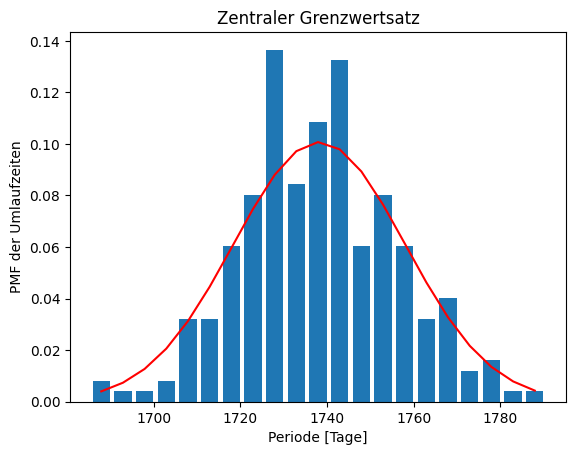

In [1283]:
sample_size = 500

number_of_samples = 250

sample_means = np.zeros(number_of_samples)

for i in range(number_of_samples):
    # Ziehe die richtige Anzahl an zufälligen Datenpunkten aus den Ursprungsdaten und 
    # berechne den Mittelwert dieser Samples.
    sample = np.random.choice(data, size=sample_size, replace=False)
    sample_means[i] = np.mean(sample)

resolution = 5
x, px = PMF(sample_means, resolution)

# Plotten
plt.figure()
plt.bar(x, px, width=0.8*resolution)
plt.xlabel('Periode [Tage]')
plt.ylabel('PMF der Umlaufzeiten')
plt.title('Zentraler Grenzwertsatz')

meanPeriod = np.mean(data)
stdPeriod = np.std(data)/np.sqrt(sample_size)
plt.plot(x,normal_pmf(x,meanPeriod,stdPeriod,resolution),'r')


Laut dem Zentralen Grenzwertsatz erwarten wir eine Normalverteilung der Mittelwerte der Stichproben. Dabei ist der Mittelwert dieser Verteilung der Mittelwert des ursprünglichen Datensatzes. Die erwartete Standardabweichung ist die Standardabweichung der Ursprungsdaten, geteilt durch die Grösse der Stichproben.

### c)

Wiederholen Sie dies für den Fall, dass Sie 2, 10, 100, 1000 Werte pro Stichprobe nehmen. Stellen Sie das Ergebnis in einer Abbildung mit 4 Untergrafiken dar. Was fällt dabei auf? Wie verhält sich das Histogramm der Stichproben im Vergleich zur erwarteten Normalverteilung?\
Ändern Sie zusätzlich die Anzahl der Stichproben. Welchen Effekt hat dies?

In [1284]:
n_samples_list = np.array([2, 10, 100, 1000])
number_of_samples = 500

### Lösung

Text(0.5, 0.98, 'Unterschiedliche Anzahl an Werten pro Stichprobe')

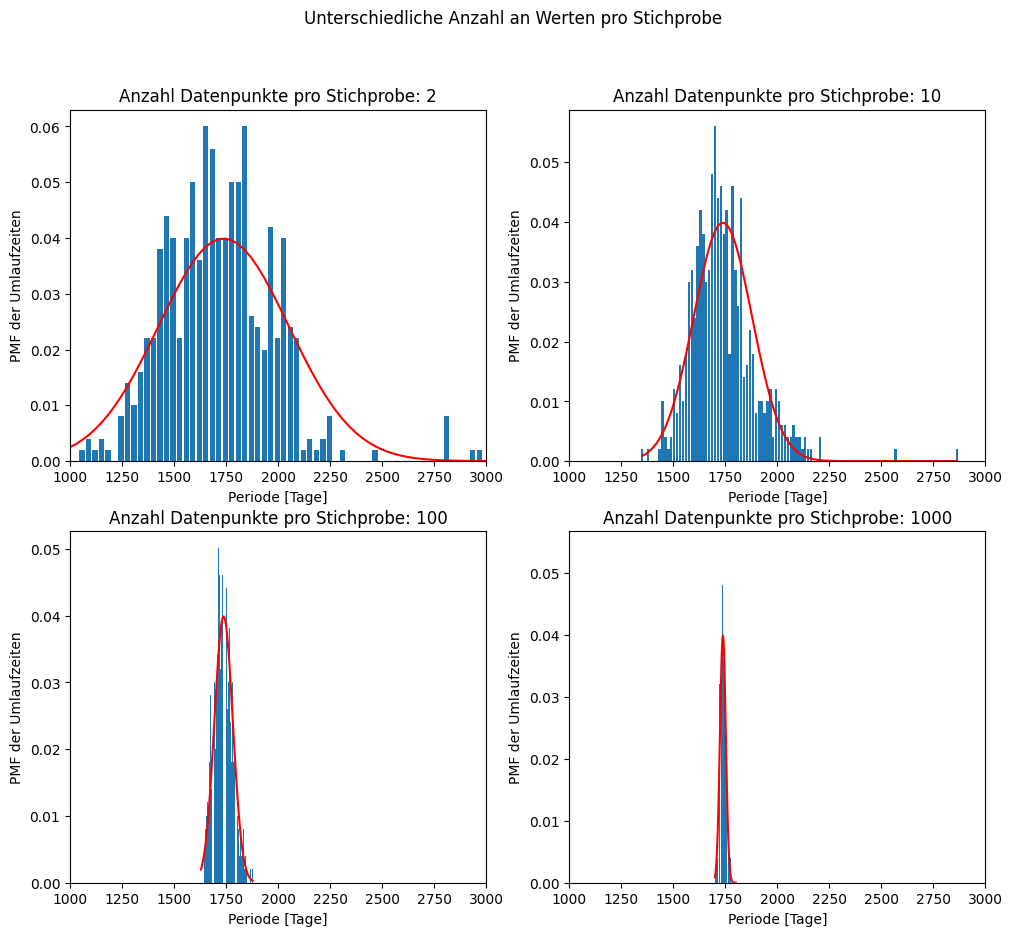

In [1285]:
cm = 0.393701


fig = plt.figure(figsize=(30*cm, 25.5*cm))

# Wir erzeugen die Histogramme und Plots für die verschiedene Anzahl an Datenpunkten in einer for-Schleife, da
# der Code immer der gleiche ist.
for idx, sample_size in enumerate(n_samples_list):
    sample_means = np.zeros(number_of_samples)

    for i in range(number_of_samples):
        sample = np.random.choice(data, size=sample_size, replace=False)
        sample_means[i] = np.mean(sample)
        
    meanPeriod = np.mean(data)
    stdPeriod = np.std(data)/np.sqrt(sample_size)
    # Histogramm erzeugen
    resolution = stdPeriod/10
    x, px = PMF(sample_means, resolution)
    
    # Plotten
    ax = fig.add_subplot(2, 2, idx+1)
    ax.bar(x, px, width=0.8*resolution)
    ax.plot(x,normal_pmf(x,meanPeriod,stdPeriod,resolution),'r')
    ax.set_xlabel('Periode [Tage]')
    ax.set_ylabel('PMF der Umlaufzeiten')
    ax.set_title('Anzahl Datenpunkte pro Stichprobe: {:.0f}'.format(sample_size))
    ax.set_xlim([1000,3000])
fig.suptitle("Unterschiedliche Anzahl an Werten pro Stichprobe")

Wenn die Anzahl der Datenpunkte pro Stichpunkt erhöht wird, führt dies zu einer Reduzierung der Standardabweichung der resultierenden Normalverteilung. Um dies zu verdeutlichen, wurden oben alle vier Plots über das gleiche x-Achsen Intervall geplottet.

Text(0.5, 0.98, 'Unterschiedliche Anzahl an Stichproben')

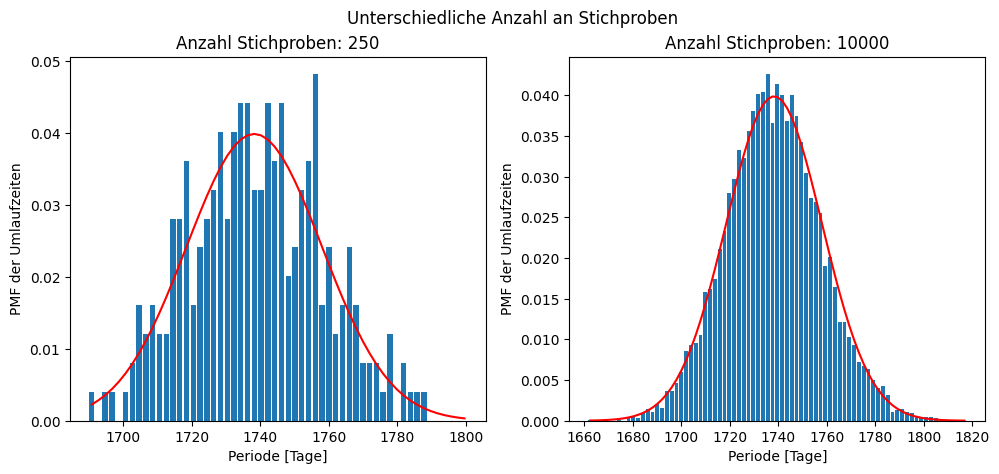

In [1286]:
#Nun ändern wir die Anzahl samples, behalten jedoch die Samplegrösse von 500 Datenpunkten pro Sample

sample_size = 500
number_of_samples_list = np.array([250, 10000])

fig2 = plt.figure(figsize=(30*cm, 12*cm))

# Wir erzeugen die Histogramme und Plots für die verschiedene Anzahl an Datenpunkten in einer for-Schleife, da
# der Code immer der gleiche ist.
for idx, number_of_samples in enumerate(number_of_samples_list):
    sample_means = np.zeros(number_of_samples)

    for i in range(number_of_samples):
        sample = np.random.choice(data, size=sample_size, replace=False)
        sample_means[i] = np.mean(sample)
        
    meanPeriod = np.mean(data)
    stdPeriod = np.std(data)/np.sqrt(sample_size)
    # Histogramm erzeugen
    resolution = stdPeriod/10
    x, px = PMF(sample_means, resolution)
    
    # Plotten
    ax = fig2.add_subplot(1, 2, idx+1)
    ax.bar(x, px, width=0.8*resolution)
    ax.plot(x,normal_pmf(x,meanPeriod,stdPeriod,resolution),'r')
    ax.set_xlabel('Periode [Tage]')
    ax.set_ylabel('PMF der Umlaufzeiten')
    ax.set_title('Anzahl Stichproben: {:.0f}'.format(number_of_samples))
fig2.suptitle("Unterschiedliche Anzahl an Stichproben")

Wenn hingegen die Anzahl der Stichproben erhöht wird, führt dies zu einer verbesserten Übereinstimmung mit der erwarteten Verteilung.

### d)

Um das Ziehen der Stichproben effizienter zu gestalten, stellen wir Ihnen den folgenden Code zur Verfügung:

In [1287]:
def draw_samples(data, sample_size, number_of_samples):
    start_points = np.random.randint(0, data.size-sample_size, size=(1,number_of_samples))
    drawn_indices = np.squeeze(np.linspace(start_points, start_points + sample_size-1 ,sample_size))
    sample_data = data[drawn_indices.astype(int)]
    
    return sample_data

Ziehen Sie 1000 Stichproben, wobei jede Stichprobe aus 5000 Objekten besteht, und plotten Sie die Verteilung der Mittelwerte dieser Stichproben. Was fällt Ihnen dabei auf? Können Sie dieses Verhalten erklären?

In [1288]:
sample_size = 5000
number_of_samples = 1000

### Lösung

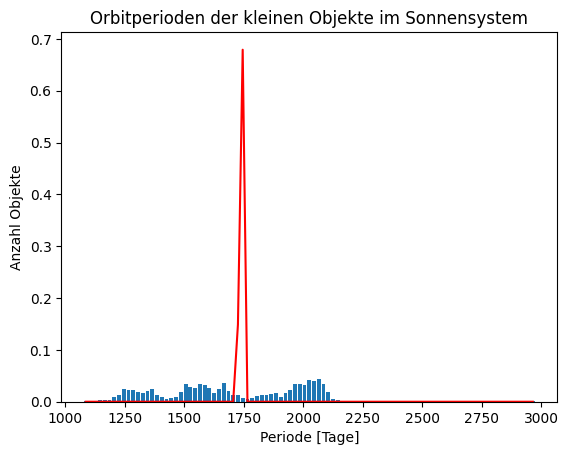

In [1289]:
resolution = 20
samples = draw_samples(data, sample_size, number_of_samples)
sample_means = np.mean(samples, axis=0)

x, px = PMF(sample_means, resolution)
# Plotten
plt.figure()
plt.bar(x, px, width=0.8*resolution)
plt.xlabel('Periode [Tage]')
plt.ylabel('Anzahl Objekte')
plt.title('Orbitperioden der kleinen Objekte im Sonnensystem')

meanPeriod = np.mean(data)
stdPeriod = np.std(data)/np.sqrt(sample_size)
plt.plot(x,normal_pmf(x,meanPeriod,stdPeriod,resolution),'r')


Eine der fundamentalen Annahmen des zentralen Grenzwertsatzes ist, dass die Stichproben unabhängig und identisch verteilt sind. Die oben gezeigte draw_samples Funktion wählt zwar zufällig gewählte Startwerte für jede Stichprobe, der Inhalt der Stichprobe sind allerdings die folgenden Indizes. Dadurch sind die Stichproben nicht mehr unabhängig (dies wird dadurch verstärkt, dass der Inhalt der Ursprungsdaten aufsteigend sortiert ist) und der zentrale Grenzwertsatz kann nicht mehr angewendet werden.

---

# Musterlösung 10

In [1290]:
import numpy as np
import matplotlib.pyplot as plt

# Aufgabe 1

Bei Messungen möchte man häufig die Abhängigkeit einer Messgrösse $y$ von einer unabhängigen Variable $x$ bestimmen. Zum Beispiel, wenn man die Kennlinie einer Diode bestimmt, dann ist die angelegte Spannung $U$ die unabhängige Variable, und man misst den Strom $I$ in Abhängigkeit davon. Wird ein polynomieller Zusammenhang von der Form:

$$y(x) = f(x, \vec{a}) = a_0 + a_1 x + a_2 x^2 + \dots = \sum_{n=0}^{m} a_n x^n \qquad \mathrm{mit}\quad \vec{a} = (a_0, \dots, a_m)$$

erwartet, dann kann man die unbekannten Parameter $a_n$ aufgrund von gemessenen Daten mittels linearem Fitten 
bestimmen.

Von nun an nennen wir das Polynom $f(x, \vec{a})$ das Modell, welches uns für jedes $x$ den erwarteten Messwert gibt. Die tatsächlich gemessenen Werte nennen wir $y_i$, mit der jeweiligen Unsicherheit (Standardabweichung) $\sigma_i$.

## a)

Laden Sie den Datensatz 'lin_data.txt', der eine positionsabhängige Kraft beschreibt, und plotten Sie die Daten mit Fehlerbalken. Verwenden Sie hierzu die Funktion `ax.errorbar` von matplotlib. Schätzen Sie aufgrund des Plots von Hand die Steigung und den Achsenabschnitt der Geraden ab, die den Zusammenhang zwischen Kraft und Ort in diesem Datensatz beschreibt.

### Lösung

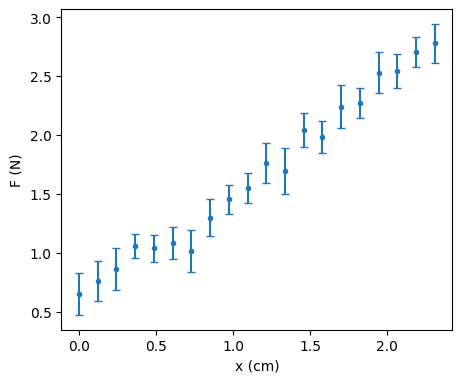

In [1291]:
# Daten Laden
data = np.loadtxt('data/lin_data.txt')
x_val = data[:, 0]
y_val = data[:, 1]
sigma_y = data[:, 2]

# Plot erstellen
cm = 1 / 2.54
fig = plt.figure(figsize=(12 * cm, 10 * cm))
ax = fig.add_subplot(1, 1, 1)
ax.errorbar(x_val, y_val, sigma_y, capsize=3, linestyle='None', marker='.')

ax.set_xlabel('x (cm)')
ax.set_ylabel('F (N)')

fig.tight_layout()

Man kann sehen, dass die Daten etwa auf einer Gerade liegen, die die y-Achse bei $y \approx 0.5\,$N schneidet. Die ungefähre Steigung beträgt $1\,$N/cm. Damit wäre die abgschätzte lineare Abhängigkeit gegeben durch

$$F(x) = 0.5\,\mathrm{N} + 1\,\mathrm{N}/\mathrm{cm} \cdot x.$$

## b)

In der Vorlesung haben Sie gesehen, dass das lineare Fitten dem Minimieren der Summe aller Residuenquadrate entspricht. Das heisst, man sucht die Werte für $a_n$, sodass die Summe

$$S = \sum_{n=1}^{N} \frac{(y_i - f(x_i, \vec{a}))^2}{\sigma_i^2}$$

den minimalen Wert annimmt. (Die Differenzen der Messwerte $y_i$ und der erwarteten Werte $f(x_i, \vec{a})$ heissen Residuen.)

Wie Sie im Plot aus a) gesehen haben, ist der Zusammenhang bei diesen Daten linear, d.h. wir haben $m = 1$ und das Modell ist

$$ f(x, a_0, a_1) = a_0 + a_1 x.$$

Berechnen Sie die Summe $S$ der Residuenquadrate für verschiedene Kombinationen von Werten für $a_0$ und $a_1$ in einem Bereich um die Werte, die Sie in a) von Hand abgeschätzt haben. Nehmen Sie z.B. für $a_0$ fünfzig Werte im Intervall $[-0.5, 1.5]$ und für $a_1$ sechzig Werte im Intervall $[0, 2]$, und berechnen Sie $S$ für alle $50 \times 60$ Kombinationen. 

Plotten Sie $\log(S)$ abhängig von $a_0$ und $a_1$ mithilfe von `ax.pcolormesh` als 2D-Plot. Orientieren Sie sich an dem Beispiel unten für das Erstellen des Plots. Sie sollten ein Minimum sehen, das den optimalen Werten für $a_0$ und $a_1$ entspricht. Stimmt die Position des Minimums mit den Werten, die Sie in a) erhalten haben, überein?

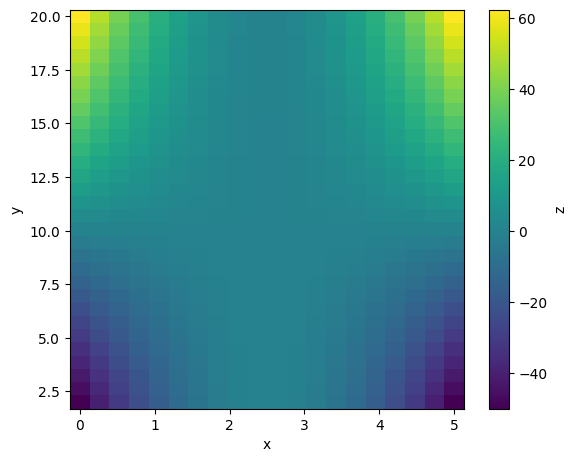

In [1292]:
# Erzeuge einige Daten zum Plotten
x_example = np.linspace(0, 5, 20)
y_example = np.linspace(2, 20, 30)
z_example = np.zeros(shape=(len(x_example), len(y_example)))

for i, x in enumerate(x_example):
    for j, y in enumerate(y_example):
        z_example[i, j] = (x - 2.5)**2 * (y - 10)

        
# 2D-Plot generieren
cm = 1 / 2.54

fig = plt.figure(figsize=(15 * cm, 12 * cm))
ax = fig.add_subplot(1, 1, 1)

# Beachten Sie, dass das Z-Array transponiert werden muss (.T), weil die
# pcolormesh erwartet, dass die erste Achse (äusseres Array) den vertikalen
# Pixeln (y-Achse) enspricht und die zweite Achse (inneres Array) den horizontalen.
im = ax.pcolormesh(x_example, y_example, z_example.T, shading='nearest')

# Colorbar für die Farbskala, mit Achsenbeschriftung
fig.colorbar(im, label='z')

ax.set_xlabel('x')
ax.set_ylabel('y')

fig.tight_layout()

### Lösung

In [1293]:
# Wertebereiche für a0 und a1 definieren
a0_range = np.linspace(-0.5, 1.5, 50)
a1_range = np.linspace(0, 2, 60)

# Array für die berechneten S initialisieren
S = np.zeros(shape=(50, 60))

# S für alle Kombinationen berechnen
for i, a0 in enumerate(a0_range):
    for j, a1 in enumerate(a1_range):
        S[i, j] = np.sum((y_val - (a0 + a1 * x_val))**2 / sigma_y**2)

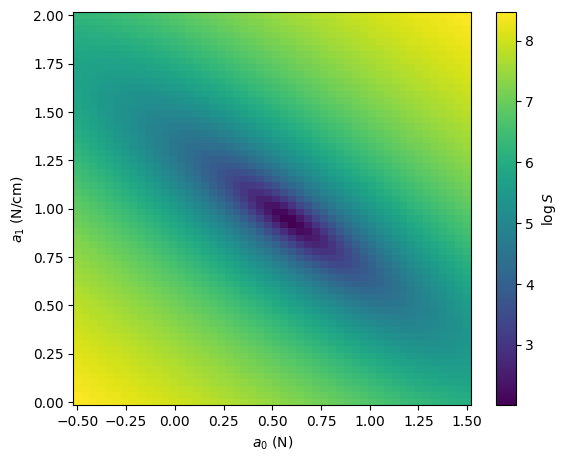

In [1294]:
cm = 1 / 2.54
fig = plt.figure(figsize=(15 * cm, 12 * cm))
ax = fig.add_subplot(1, 1, 1)

im = ax.pcolormesh(a0_range, a1_range, np.log(S).T, shading='nearest')
fig.colorbar(im, label=r'$\log S$')

ax.set_xlabel('$a_0$ (N)')
ax.set_ylabel('$a_1$ (N/cm)')

fig.tight_layout()

Man sieht ein deutliches Minimum in der nähe von $a_0 = 0.5\,\mathrm{N}$, $a_1 = 1\,\mathrm{N}/\mathrm{cm}$, was mit den Werten aus a) übereinstimmt.

## c)

Bestimmen Sie die optimalen Parameter $a_0$ und $a_1$ und deren Unsicherheiten mit der analytischen Methode aus der Vorlesung. Berechnen Sie dazu die Normalmatrix

$$
N = \begin{pmatrix}\sum_i w_i & \sum_i w_i x_i \\ \sum_i w_i x_i & \sum_i w_i x_i^2 \end{pmatrix}
$$

und den Vektor

$$
\vec{Y} = \begin{pmatrix} \sum_i w_i y_i \\ \sum_i w_i x_i y_i \end{pmatrix},
$$

wobei die Gewichte $w_i = 1 / \sigma_i^2$ durch die Unsicherheiten der Datenpunkte gegeben sind. Plotten Sie anschliessend die Daten zusammen mit dem Fit, um Ihr Resultat zu überprüfen.

Hinweise:

- Sie können 2-dimensionale Arrays verwenden, um Matrizen zu speichern.
- Um eine Matrix zu invertieren, verwenden Sie die Funktion `np.linalg.inv`.
- Für das Matrixprodukt können Sie die Notation `A @ B` oder `np.dot(A, B)` verwenden.

### Lösung

In [1295]:
N = np.zeros(shape=(2, 2))
Y = np.zeros(shape=(2,))  # '(2,)' ist ein Tupel mit nur einem Eintrag. '(2)' ohne Komma gibt ein Integer.

# N und Y berechnen. Da wir hier ein Polynom ersten Grades fitten (m = 1), können wir einfach
# jedes Element einzeln hinschreiben.
# Allgemeinere Lösung siehe unten.
N[0, 0] = np.sum(1 / sigma_y**2)
N[0, 1] = np.sum(x_val / sigma_y**2)
N[1, 0] = np.sum(x_val / sigma_y**2)
N[1, 1] = np.sum(x_val**2 / sigma_y**2)

Y[0] = np.sum(y_val / sigma_y**2)
Y[1] = np.sum(y_val * x_val / sigma_y**2)

# Lösungsvektor
a0, a1 = np.linalg.inv(N) @ Y

# Kovarianzmatrix
# Die Unsicherheiten (Standardabweichung) der gefitteten Parameter bekommt man
# aus der Wurzel der Diagonaleinträge.
C = np.linalg.inv(N)
sig_a0 = np.sqrt(C[0, 0])
sig_a1 = np.sqrt(C[1, 1])

# Resultate ausgeben (Unicode string für das "Plusminus"-Zeichen)
print(u'a_0 = ({:.3f} \u00b1 {:.3f}) N\na_1 = ({:.3f} \u00b1 {:.3f}) N/cm'.format(a0, sig_a0, a1, sig_a1))

a_0 = (0.588 ± 0.063) N
a_1 = (0.939 ± 0.047) N/cm


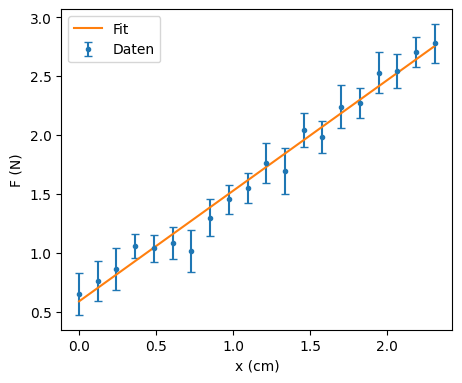

In [1296]:
# Daten und Fit plotten.
cm = 1 / 2.54
fig = plt.figure(figsize=(12 * cm, 10 * cm))
ax = fig.add_subplot(1, 1, 1)

ax.errorbar(x_val, y_val, sigma_y, capsize=3, linestyle='None', marker='.', label='Daten')
ax.plot(x_val, a0 + a1 * x_val, label='Fit')
ax.legend()

ax.set_xlabel('x (cm)')
ax.set_ylabel('F (N)')

fig.tight_layout()

## d)

Schreiben Sie eine Funktion, die einen Datensatz mit einem Polynom beliebiger Ordnung fittet, d.h. die optimalen Parameter $a_i$ findet. Die Funktion soll als Argumente nehmen:

- Die Werte $x_i$ der unabhängigen Variable.
- Die gemessenen Werte $y_i$.
- Die dazugehörigen Unsicherheiten $\sigma_i$.
- Den Grad $m$ des Polynoms, das gefittet werden soll.

Die Rückgabewerte der Funktion sollen der Lösungsvektor $\vec{a}$, also die Koeffizienten des gefitteten Polynoms, und deren Kovarianzmatrix $C$ sein.

Wenden Sie die Funktion auf den Datensatz 'poly_data.txt' an und berechnen Sie die Fits mit $m = 4$, $m=5$ und $m=6$. Plotten Sie den Fit $f(x,\vec{a}_{\mathrm{opt}})$ und die Residuen für die drei Fälle. Was können Sie aus Ihren Plots schliessen? Können Sie zum Beispiel ahnand der Residuen erkennen, ob Ihr Modell die Daten gut beschreibt? Was passiert, wenn sie unterfitten (d.h. wenn das Modell zu wenige Freiheitsgrade hat) und wenn Sie überfitten (zu viele Freiheitsgrade)?

### Lösung

In [1297]:
def linear_fit(x, y, sigma, m):
    '''Perform a linear fit with a polynomial of order m. Returns an array of length m containing
    the optimized coefficients of the fit.'''
    # Gewichte
    w = 1 / sigma**2
    
    # N und Y berechnen. Ein Polynom von Grad m hat m+1 Koeffizienten.
    N = np.zeros(shape=(m+1, m+1))
    Y = np.zeros(shape=(m+1, ))
    
    # Durch Betrachten der Normalmatrix kann man erkennen, dass der Exponent
    # von x in jedem Eintrag der Summe Indizes diese Eintrags entspricht.
    # Ähnlich ist es beim Vektor Y.
    for i in range(m + 1):
        Y[i] = np.sum(w * y * x**i)
        for j in range(m + 1):
            
            N[i, j] = np.sum(w * x**(i+j))
            
    # Kovarianzmatrix
    C = np.linalg.inv(N)
    # Lösungsvektor berechnen und ausgeben
    a_vec = C @ Y
    return a_vec, C

In [1298]:
# Neuen Datensatz laden
data = np.loadtxt('data/poly_data.txt')
u_val = data[:, 0]
i_val = data[:, 1]
sigma_i = data[:, 2]

In [1299]:
# Berechne den Fit für verschiedene m

m = 3
# Lösungsvektor mit der Funktion von oben berechnen.
a_vec_m3, C_m3 = linear_fit(u_val, i_val, sigma_i, m)

# Die erwarteten y-Werte aus dem Fit sind
#    f(x_i, a_opt) = a0 + a1 * x + a2 * x**2 + ... + a_m * x**m.
# Für jeden Datenpunkt x_i müssen wir also die Summe über n von a_n x_i**n berechnen
i_fit_m3 = np.zeros(len(u_val))
for index, x_i in enumerate(u_val):
    sum_i = 0
    for n, a_n in enumerate(a_vec_m3):
        sum_i += a_n * x_i**n
        
    i_fit_m3[index] = sum_i


# Das gleiche für m = 4 und m = 5.
m = 4
a_vec_m4, C_m4 = linear_fit(u_val, i_val, sigma_i, m)

i_fit_m4 = np.zeros(len(u_val))
for index, x_i in enumerate(u_val):
    sum_i = 0
    for n, a_n in enumerate(a_vec_m4):
        sum_i += a_n * x_i**n
        
    i_fit_m4[index] = sum_i
    
m = 5
a_vec_m5, C_m5 = linear_fit(u_val, i_val, sigma_i, m)

i_fit_m5 = np.zeros(len(u_val))
for index, x_i in enumerate(u_val):
    sum_i = 0
    for n, a_n in enumerate(a_vec_m5):
        sum_i += a_n * x_i**n
        
    i_fit_m5[index] = sum_i

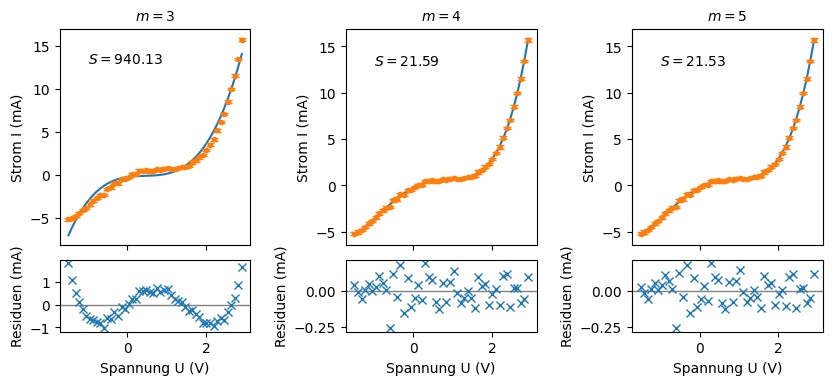

In [1300]:
# Um mehr Kontrolle über die Anordnung von Plots auf einem Gitter zu haben, verwenden wir
# matplotlib.gridspec
import matplotlib.gridspec as gs

# Plotten
cm = 1 / 2.54
fig = plt.figure(figsize=(25 * cm, 10 * cm))

# Definere das Gitter-Layout mit unterschiedlicher Höhe für die zwei Zeilen.
gs0 = gs.GridSpec(nrows=2, ncols=3, height_ratios=[3, 1], hspace=.1, figure=fig)


###### m = 3
# Plots hinzufügen geht dann so:
ax1 = fig.add_subplot(gs0[0, 0])

# Der Rest wie gewohnt
ax1.plot(u_val, i_fit_m3)
ax1.errorbar(u_val, i_val, sigma_i, capsize=3, linestyle='None', marker='.')

ax1.set_ylabel('Strom I (mA)')
ax1.set_xticklabels([])  # Entferne Labels, weil die Achse gleich wie im Plot unten ist
ax1.set_title('$m = 3$', size=10)

ax1.text(-1, 13, '$S = ${:.2f}'.format(np.sum((i_val - i_fit_m3)**2 / sigma_i**2)))

# Residuen
ax2 = fig.add_subplot(gs0[1, 0])
ax2.axhline(0, color='0.5', linewidth=1)
ax2.plot(u_val, i_val - i_fit_m3, 'x')

ax2.set_xlabel('Spannung U (V)')
ax2.set_ylabel('Residuen (mA)')


###### m = 4
ax3 = fig.add_subplot(gs0[0, 1])

ax3.plot(u_val, i_fit_m4)
ax3.errorbar(u_val, i_val, sigma_i, capsize=3, linestyle='None', marker='.')

ax3.set_ylabel('Strom I (mA)')
ax3.set_xticklabels([])
ax3.set_title('$m = 4$', size=10)

ax3.text(-1, 13, '$S = ${:.2f}'.format(np.sum((i_val - i_fit_m4)**2 / sigma_i**2)))
         
# Residuen
ax4 = fig.add_subplot(gs0[1, 1])
ax4.axhline(0, color='0.5', linewidth=1)
ax4.plot(u_val, i_val - i_fit_m4, 'x')

ax4.set_xlabel('Spannung U (V)')
ax4.set_ylabel('Residuen (mA)')


###### m = 5
ax5 = fig.add_subplot(gs0[0, 2])

ax5.plot(u_val, i_fit_m5)
ax5.errorbar(u_val, i_val, sigma_i, capsize=3, linestyle='None', marker='.')

ax5.set_ylabel('Strom I (mA)')
ax5.set_xticklabels([])
ax5.set_title('$m = 5$', size=10)

ax5.text(-1, 13, '$S = ${:.2f}'.format(np.sum((i_val - i_fit_m5)**2 / sigma_i**2)))
         
# Residuen
ax6 = fig.add_subplot(gs0[1, 2])
ax6.axhline(0, color='0.5', linewidth=1)
ax6.plot(u_val, i_val - i_fit_m5, 'x')

ax6.set_xlabel('Spannung U (V)')
ax6.set_ylabel('Residuen (mA)')


##
fig.subplots_adjust(wspace=.5)  # Layout anpassen, damit die Achsenbeschriftungen nicht überlappen

Für $m=3$ weicht der Fit deutlich von den Datenpunkten ab und auch die Residuen zeigen eine klare Struktur. Wenn die Residuen nicht zufällig verteilt sind, deutet das darauf hin, dass das Modell unzureichend komplex für die Daten ist.

Für $m=4$ ist keine Struktur mehr in den Residuen zu erkennen. Ein Polynom fünften Grades beschreibt hier also den Zusammenhang zwischen Strom und Spannung gut.

Durch Erhöhen von $m$ auf 5 kann man die gewichtete Summe $S$ der Residuenquadrate noch ein wenig reduzieren, was aber nicht bedeutet, dass ein Polynom sechsten Grades hier das bessere Modell ist: Man kann nämlich einen Datensatz mit $N$ Punkten immer perfekt fitten, wenn man ein Polynom $N$-ten Grades verwendet. Allerdings haben aber dann die Fitparameter keine physikalische Bedeutung mehr.

Beim Fitten von Daten sollte man also ein physikalisch motivertes Modell nehmen, und nicht einfach die Anzahl Freiheitsgrade (Fitparameter) erhöhen, bis der Fit passt.

---

# Musterlösung 11

In [1301]:
import numpy as np
import matplotlib.pyplot as plt

# Aufgabe 1 - Gradientenverfahren

## a)

Laden Sie zuerst die Daten aus dem File 'decay.txt'. Sie enthalten eine Spannung, die exponentiell mit der Zeit zerfällt,

$$ V(t) = Ae^{-\frac{t}{\tau}},$$

sowie deren Unsicherheiten. Stellen Sie die Werte mit Fehlerbalken dar, und schätzen Sie die Amplitude $A$ und die Zerfallszeit $\tau$  ab, indem Sie sie aus der Grafik ablesen.

### Lösung

Bei t = 0s ist V = 5.79 V, also A = 5.79 V
Dabei ist  V(0)/e = 2.13 V und schlussendlich tau = 0.2 s 


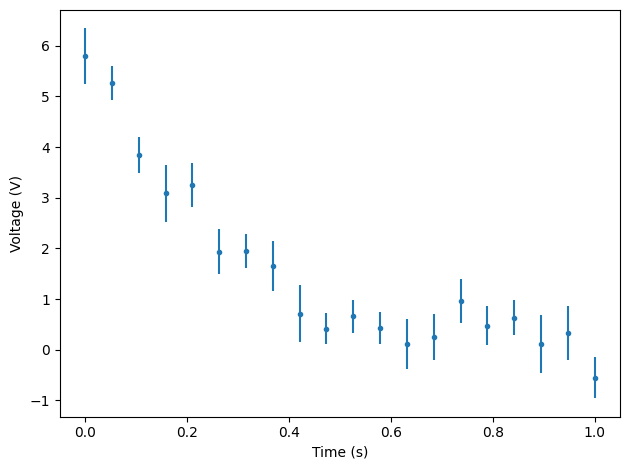

In [1302]:
data = np.loadtxt('data/decay.txt', skiprows=1)
t = data[0, :]
V = data[1, :]
sigma = data[2, :]


fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.errorbar(t, V, yerr=sigma, marker='.', linestyle='None')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Voltage (V)')

fig.tight_layout()

print('Bei t = 0s ist V = {:0.2f} V, also A = {:0.2f} V'.format(V[0], V[0]))
print('Dabei ist  V(0)/e = {:0.2f} V und schlussendlich tau = 0.2 s '.format(V[0]/np.exp(1)))

## b)

Schreiben Sie zuerst eine Funktion $f(x,\vec{a})$, die das Modell beschreibt.

Anschliessend definieren Sie die Funktion, die

$$S = \sum_{n=0}^{m} \frac{(y_i - f(x_i, \vec{a}))^2}{\sigma_i^2}$$

berechnet. Sie sollte $x$, $y$, $\sigma$, $f$ und $\vec{a}$ als Argumente nehmen und $S$ zurückgeben. Benutzen Sie die Funktion, um $S$ für verschiedene Parameter $\vec{a}$ um die Werte herum zu berechnen, die Sie in a) abgeschätzt haben (je ca. 50 Punkte sollten genügen). Plotten Sie $\log(S)$ in einer 2D Grafik (Analog zur Übung 10). 


### Lösung

In [1303]:
def exp(t, a):
    return a[0] * np.exp(-t / a[1])

def Sres(x, y, sigma, f, a):
    return np.sum((y - f(x,a))**2 / sigma**2)

In [1304]:
# Wir definieren die Testwerte rund um unsere Schätzung der vorherigen Aufgabe. 
A_range = np.linspace(5, 7, 50)
tau_range = np.linspace(0.1, 0.4, 51)

# Array um die Werte zu speichern
S = np.zeros((len(A_range), len(tau_range)))

# Iteration durch die beiden Arrays mit den Testwerten
for i, A in enumerate(A_range):
    for j, tau in enumerate(tau_range):
        S[i, j] = Sres(t, V, sigma, exp, [A, tau])

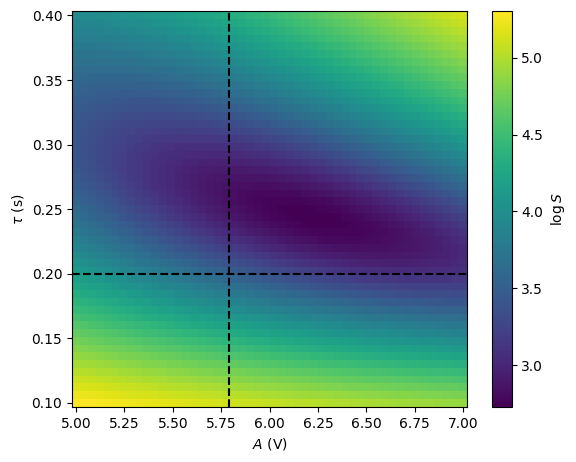

In [1305]:
cm = 1 / 2.54
fig = plt.figure(figsize=(15 * cm, 12 * cm))
ax = fig.add_subplot(1, 1, 1)

im = ax.pcolormesh(A_range, tau_range, np.log(S).T, shading='nearest')
fig.colorbar(im, label=r'$\log S$')

# Wir zeichnen die geschätzten Werte mit Linien ein.
ax.axhline(0.2, color='k', linestyle='--')
ax.axvline(5.79, color='k', linestyle='--')

ax.set_xlabel('$A$ (V)')
ax.set_ylabel(r'$\tau$ (s)')

fig.tight_layout()

## c)

Für das Gradientenverfahren benötigen wir die erste und die zweite Ableitung von $S$ bezüglich der Parameter $a_i$. Man kann die erste Ableitung berechnen, indem man die Werte von $\vec{a}$ um einen kleinen Wert $\Delta$ variiert und die Differenz betrachtet. Um die Ableitung nach jedem Parameter separat zu berechnen, definieren wir den Vektor $\vec{\Delta}_i = \Delta \vec{e}_i$, der den Parameter $a_i$ variiert. Damit ergibt sich für die erste Ableitung:

$$
(\vec{\nabla}S)_i = \frac{\partial S}{\partial {a_i}} = \frac{S(x, y, \sigma, f, \vec{a} + \vec{\Delta}_i) - S(x, y, \sigma, f, \vec{a} - \vec{\Delta}_i)}{2\Delta}.
$$

Und die zweite:

$$
(\nabla^\top\nabla S)_{i,j} = \frac{\partial^2 S}{\partial a_i \partial a_j}= \frac{S(x, y, \sigma, f, \vec{a} + \vec{\Delta}_i + \vec{\Delta}_j) - S(x, y, \sigma, f, \vec{a}  - \vec{\Delta}_i + \vec{\Delta}_j) - S(x, y, \sigma, f, \vec{a}  + \vec{\Delta}_i - \vec{\Delta}_j) + S(x, y, \sigma, f, \vec{a}  - \vec{\Delta}_i - \vec{\Delta}_j)}{4\Delta^2}.
$$

Wir stellen eine Funktion für die zweite Ableitung zur Verfügung. Versuchen Sie, die Schritte nachzuvollziehen und schreiben Sie analog dazu eine Funktion, die die erste Ableitung berechnet.

In [1306]:
def dS2 (x, y, sigma, f, a, delta):
    # Leere Matrix um die Komponenten zu speichern
    delta_S2 = np.zeros((len(a), len(a)))
    
    # Da wir über alle Kombinationen der a_i's ableiten müssen, iterieren wir in zwei verschachtelten Schlaufen über die
    # Einträge von a. 
    for i in range(len(a)):
        for j in range(len(a)):
            # Wir definieren neue Delta-Vektoren, die nur einen Eintrag in der Entsprechenden Dimension haben z.B. (Delta, 0)
            delta_i = np.zeros(len(a))
            delta_j = np.zeros(len(a))
            delta_i[i] = delta
            delta_j[j] = delta
            
            # Und wir berechnen die Matrixelemente so wie in der Aufgabenstellung gegeben.
            delta_S2[i,j] = (  Sres(x, y, sigma, f, a + delta_i + delta_j)
                             - Sres(x, y, sigma, f, a - delta_i + delta_j)
                             - Sres(x, y, sigma, f, a + delta_i - delta_j)
                             + Sres(x, y, sigma, f, a - delta_i - delta_j)) / (4 * delta * delta)
    return delta_S2

### Lösung

In [1307]:
def dS(x, y, sigma, f, a, delta):
    delta_S = np.zeros(len(a))
    
    for i in range(len(a)):
        delta_i = np.zeros(len(a))
        delta_i[i] = delta
        delta_S[i] = (Sres(x, y, sigma, f, a + delta_i) - Sres(x, y, sigma, f, a - delta_i)) / (2 * delta)
        
    return delta_S

## d)

Schreiben Sie nun eine Funktion, die das Gradientenverfahren anwendet, um die optimalen Parameter zu finden. Berechnen Sie dazu zuerst $\vec{\nabla} S$ und dessen Betrag $|dS| = |\vec{\nabla} S|$ für einen Startwert $\vec{a}_0$. Berechnen Sie anschliessend den nächsten Wert $\vec{a} = \vec{a}_0-\alpha\vec{\nabla} S $ mithilfe des Proportionalitätswertes $\alpha$ und dann vom neuen $\vec{a}$ wieder $\vec{\nabla} S$ und $|dS|$. Iterieren Sie nun über diesen Prozess mit einem `while` loop, bis $|dS|$ klein genug ist. Als Alternative sollten Sie auch eine maximale Anzahl Iterationen $i_{\mathrm{max}}$ als Abbruchbedingung definieren, falls die Annäherung zum Minimum zu langsam oder gar nicht konvergiert. Es ist sinnvoll, in einer Fitfunktion auch direkt die Kovarianzmatrix zu berechnen, dazu können Sie die Funktion `np.linalg.inv` benutzen.

Die Funktion sollte also folgende Argumente nehmen: $x$, $y$, $\sigma$, $f$, $\vec{a}_0$, $\Delta$, $\alpha$, $|dS|_{min}$ und $i_{max}$. Die Funktion sollte die optimalen Parameter sowie die Kovarianzmatrix als Resultate zurückgeben. Zudem sollte sie auch noch $|dS|$ für jede Iteration speichern und zusammen mit der Anzahl ausgeführten Iterationen zurückgeben.

### Lösung

In [1308]:
def gradient_descent(x, y, sigma, f, a0, delta, alpha, mingrad, imax):
    # a für die erste iteration
    a_next = a0
    
    # Berechnen des Gradienten
    current_gradient = dS(x, y, sigma, f, a_next, delta)
    
    # Berechnen der Norm des Gradienten
    norm = [np.linalg.norm(current_gradient)]
    
    # Speichern der Parameter (Bonus Aufgabe)
    a = np.zeros((int(imax),2))
    a[0] = a_next
    
    # Initialisieren der Iterationsvariablen
    i = 0
    while norm[i] > mingrad and i <= imax:
        # Parameter für die nächste Iteration
        a_next = a_next - alpha * current_gradient
        
        # Gradient und Norm berechnen
        current_gradient = dS(x, y, sigma, f, a_next, delta)
        norm.append(np.linalg.norm(current_gradient))
        a[i] = a_next
        i += 1 
        
    # Die Kovarianzmatrix ergibt sich aus der invertierten zweiten Ableitung.
    cov = 2*np.linalg.inv(dS2(x, y, sigma, f, a_next, delta))
    
    # Wir entfernen die überzählingen Nullen am Ende des Arrays
    a = a[:i, :]
    return a_next, cov, norm, i, a

## e)

Fitten Sie nun die Parameter mit dem Gradientenverfahren. Was sind die optimalen Parameter und ihre Fehler, wie viele Iterationen hat der Algorithmus gebraucht?

Benutzen Sie als Anfangswerte Ihre Abschätzungen von Aufgabe a). Für die restlichen Parameter können Sie die folgenden Werte verwenden, schauen Sie sich aber auch mal an was passiert, wenn Sie diese variieren.

$$
\Delta = 10^{-4}\qquad\alpha = 10^{-5}\qquad{}|dS|_{min} = 10^{-3}\qquad{}i_{max} = 10^{5}
$$

### Lösung

In [1309]:
# Anfangsparameter
a0 = [5.79, 0.2]

# Fitparameter
delta = 1e-4
alpha = 1e-5
mingrad = 1e-3
imax = 1e5

# Fitten der Funktion
a_opt, cov, norm, n_iter, a = gradient_descent(t, V, sigma, exp, a0, delta, alpha, mingrad, imax)

# Berechnen der Standardabweichung aus der Kovarianzmatrix
std = np.sqrt(np.diag(cov))

print(u'Die optimalen parameter sind A = {:0.2f}V \u00b1 {:0.2f}V und tau = {:0.3f}s \u00b1 {:0.3f}s'
      .format(a_opt[0], std[0], a_opt[1], std[1]))
print('Es hat {:n} Iterationen benötigt.'.format(n_iter))

Die optimalen parameter sind A = 6.22V ± 0.33V und tau = 0.244s ± 0.019s
Es hat 49362 Iterationen benötigt.


## f)

Um die Plausibilität der Fitresultate zu überprüfen, plotten Sie nochmals die Daten mit Fehlerbalken und dazu die Exponentialfunktion mit den berechneten optimalen Parametern. Sie sollten sehen, dass die berechnete Funktion in den meisten Fällen innerhalb der Fehlerbalken liegt. Schauen Sie sich auch an, wie schnell der Fit besser wird, indem Sie $|dS|$ als Funktion des Iterations-Indexes darstellen.

Bonus: Modifizieren Sie Ihre Funktion des Gradientenverfahrens so, dass sie bei jeder Iteration den aktuellen Wert von $\vec{a}$ speichert und zurückgibt. Plotten Sie nun nochmals die 2D Map von Aufgabe b), Sie können nun mit `plt.plot` direkt die Werte von $\vec{a}$ darüber plotten. Damit können Sie direkt verfolgen, welchen Weg das Gradientenverfahren einschlägt.

### Lösung

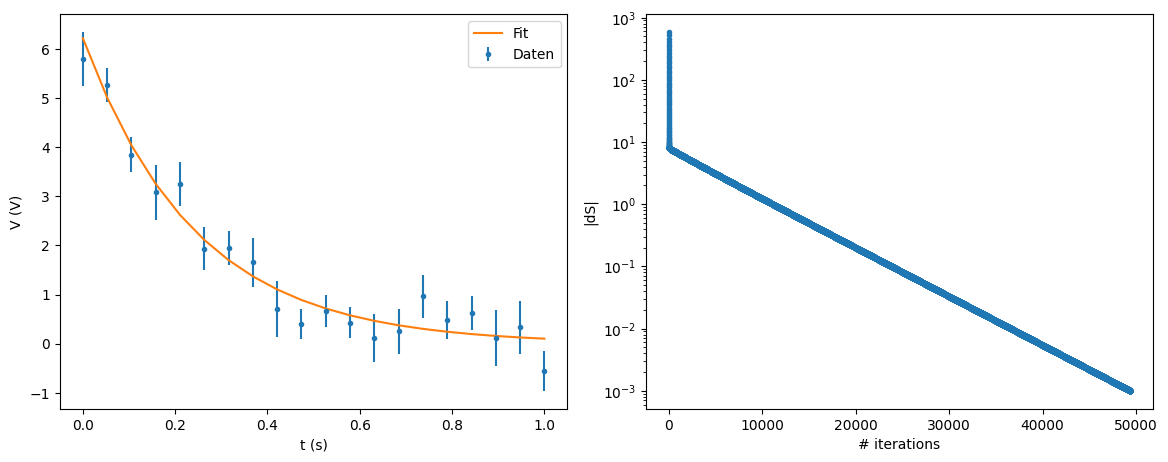

In [1310]:
cm = 1 / 2.54
fig = plt.figure(figsize=(30 * cm, 12 * cm))

ax = fig.add_subplot(1, 2, 1)
ax.errorbar(t, V, yerr=sigma, marker='.', linestyle='none', label='Daten')

# Wir plotten die Fitfunktion zusammen mit dem optimalen Parameter für a
ax.plot(t, exp(t, a_opt), label='Fit')
ax.set_xlabel('t (s)')
ax.set_ylabel('V (V)')
ax.legend()

ax = fig.add_subplot(1, 2, 2)
ax.semilogy(norm,'.')
ax.set_xlabel('# iterations')
ax.set_ylabel('|dS|')

fig.tight_layout()

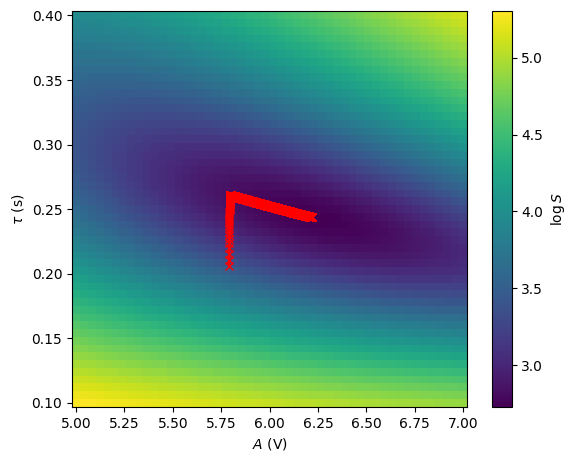

In [1311]:
cm = 1 / 2.54
fig = plt.figure(figsize=(15 * cm, 12 * cm))

ax = fig.add_subplot(1, 1, 1)
im = ax.pcolormesh(A_range, tau_range, np.log(S).T, shading='nearest')
fig.colorbar(im, label=r'$\log S$')

# Entsprechend unserer Definition entspricht der erste Eintrag der Amplitude und der zweite der Zerfallszeit
ax.plot(a[:, 0], a[:, 1], marker='x', color='r')

ax.set_xlabel('$A$ (V)')
ax.set_ylabel(r'$\tau$ (s)')
fig.tight_layout()

## g)

Das Verfahren lässt sich beschleunigen, indem man die Schrittgrösse $\alpha$ proportional zur Steigung von $dS$, also der zweiten Ableitung, skaliert. Die entsprechende Formel für die Parameter ist wie folgt:
$$
a_i = a_{i,0} - \alpha\left(\frac{\partial^2 S}{\partial a_i \partial a_i}\right)^{-1} \frac{\partial S}{\partial a_i}
$$

Schreiben Sie eine neue Funktion, die proportionale Schrittgrössen verwendet, und fitten Sie erneut die Daten. Sie können die gleichen Parameter verwenden, mit Ausnahme von $\alpha=1$. Überprüfen Sie erneut die Qualität des Fits, indem Sie die Funktion mit den optimalen Parametern zusammen mit den Daten plotten. Vergleichen Sie auch, wie schnell $|dS|$ im Vergleich zur obigen Funktion abnimmt.

Bonus: Sie können sich auch hier wieder die Werte von $\vec{a}$ ausgeben lassen und in den 2D Plot einfügen.

###  Lösung

In [1312]:
def gradient_descent_adaptive(x, y, sigma, f, a_next, delta, alpha, mingrad, imax):
    # Analog zur bisherigen Funktion
    current_gradient = dS(x, y, sigma, f, a_next, delta)
    norm = [np.linalg.norm(current_gradient)]
    
    # Berechnen der Diagonalelemente der zweiten Ableitung
    h_diag = np.diag(dS2(x, y, sigma, f, a_next, delta))
    a = np.zeros((imax, 2))
    a[0] = a_next
    i = 0
    while norm[i] > mingrad and i <= imax:
        # Skalierung der nächsten Parameter mit der zweiten Ableitung
        a_next = a_next - alpha/(h_diag)*current_gradient
        current_gradient = dS(x, y, sigma, f, a_next, delta)
        norm.append(np.linalg.norm(current_gradient))
        h_diag = np.diag(dS2(x, y, sigma, f, a_next, delta)) 
        i += 1 
        a[i] = a_next
    
    a = a[:i, :]
    cov = 2 * np.linalg.inv(dS2(x, y, sigma, f, a_next, delta))
    return a_next, cov, norm, i, a

In [1313]:
a0 = [6, 0.2]
delta = 1e-4
alpha = 1e0
mingrad = 1e-3
imax = 50000

a_opt, cov, norm_adaptive, imax, a= gradient_descent_adaptive(t, V, sigma, exp, a0, delta, alpha, mingrad, imax)
std = np.sqrt(np.diag(cov))

print(u'Die optimalen parameter sind A = {:0.2f}V \u00b1 {:0.2f}V und tau = {:0.3f}s \u00b1 {:0.3f}s'
      .format(a_opt[0], std[0],a_opt[1], std[1]))
print('Es hat {:n} iterationen benötigt'.format(imax))

Die optimalen parameter sind A = 6.22V ± 0.33V und tau = 0.244s ± 0.019s
Es hat 31 iterationen benötigt


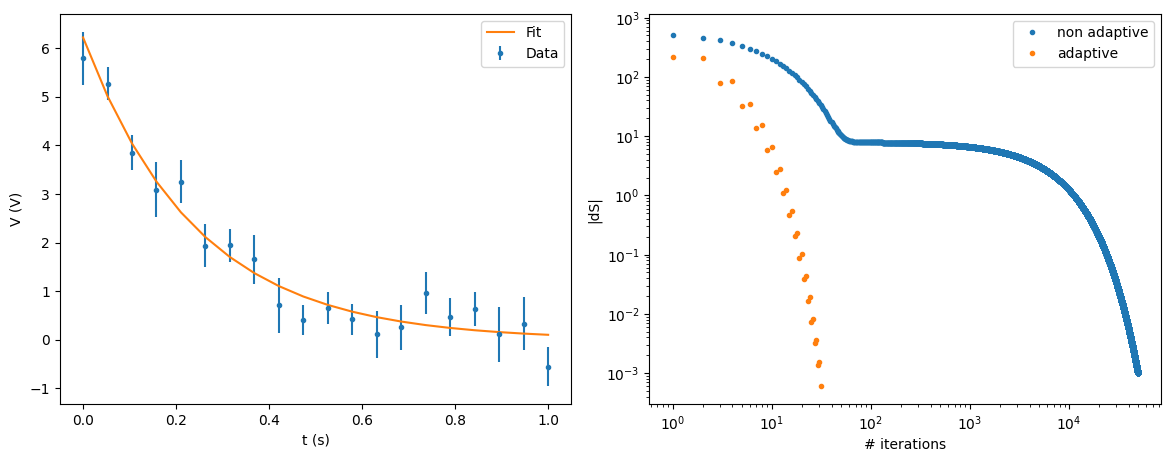

In [1314]:
cm = 1 / 2.54
fig = plt.figure(figsize=(30 * cm, 12 * cm))
ax = fig.add_subplot(1, 2, 1)
ax.errorbar(t, V, yerr=sigma, marker='.', linestyle='none', label='Data')
ax.plot(t, exp(t,a_opt), label='Fit')
ax.set_xlabel('t (s)')
ax.set_ylabel('V (V)')
ax.legend()

ax = fig.add_subplot(1, 2, 2)
ax.semilogy(norm, '.', label='non adaptive')
ax.loglog(norm_adaptive, '.', label='adaptive')
ax.legend()
ax.set_xlabel('# iterations')
ax.set_ylabel('|dS|')

fig.tight_layout()

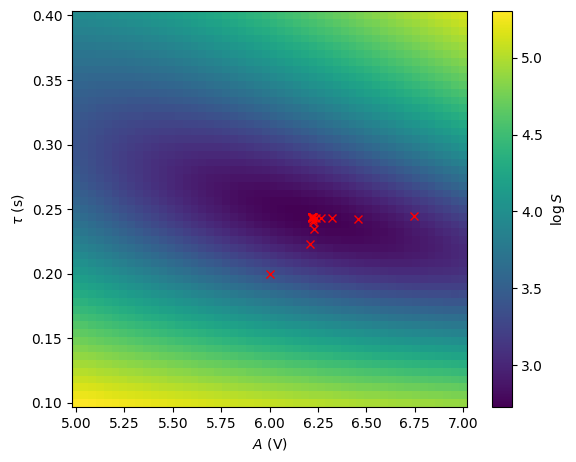

In [1315]:
cm = 1 / 2.54
fig = plt.figure(figsize=(15 * cm, 12 * cm))
ax = fig.add_subplot(1, 1, 1)

im = ax.pcolormesh(A_range, tau_range, np.log(S).T, shading='nearest')
fig.colorbar(im, label=r'$\log S$')

ax.plot(a[:,0], a[:,1], 'rx')

ax.set_xlabel('$A$ (V)')
ax.set_ylabel(r'$\tau$ (s)')
fig.tight_layout()

## h)

In der Vorlesung haben sie `lmfit` gesehen, eine Alternative ist `curve_fit` von `scipy.optimize` zu benutzen. Der Unterschied ist lediglich das Interface, im Hintergrund machen beide Methoden dasselbe. Verwenden Sie `curve_fit` um die Daten zu fitten und vergleichen Sie die Werte.

Falls Sie die Parameter zuvor als Vektoren an die Exponentialfunktion übergeben haben, ist es hier einfacher wenn Sie die Parameter einzeln übergeben. Sprich:

$$
f(x, \vec{a}) \qquad \Rightarrow \qquad f(x, a_1, a_2,...)
$$

In [1316]:
from scipy.optimize import curve_fit
curve_fit?

Signature:
curve_fit(
    f,
    xdata,
    ydata,
    p0=None,
    sigma=None,
    absolute_sigma=False,
    check_finite=None,
    bounds=(-inf, inf),
    method=None,
    jac=None,
    *,
    full_output=False,
    nan_policy=None,
    **kwargs,
)
Docstring:
Use non-linear least squares to fit a function, f, to data.

Assumes ``ydata = f(xdata, *params) + eps``.

Parameters
----------
f : callable
    The model function, f(x, ...). It must take the independent
    variable as the first argument and the parameters to fit as
    separate remaining arguments.
xdata : array_like
    The independent variable where the data is measured.
    Should usually be an M-length sequence or an (k,M)-shaped array for
    functions with k predictors, and each element should be float
    convertible if it is an array like object.
ydata : array_like
    The dependent data, a length M array - nominally ``f(xdata, ...)``.
p0 : array_like, optional
    Initial guess for the parameters (length N). If None

### Lösung

In [1317]:
# Definition der zu fittenden Funktion
def exp_cf(t, A, tau):
    return A*np.exp(-t/tau)

# Startwerte
a0 = [6, 0.2]

# Fitten
a_opt_cf, conv_cf = curve_fit(exp_cf, t, V, p0=a0, sigma=sigma, absolute_sigma=True)

# Berechnen der Standardabweichung
std_cf = np.sqrt(np.diag(conv_cf))

print('Berechnen der Werte mit curve_fit:')
print(u'A = {:0.2f}V \u00b1 {:0.2f}V und tau = {:0.4f}s \u00b1 {:0.5f}s'
      .format(a_opt_cf[0], std_cf[0], a_opt_cf[1], std_cf[1]))
print('Berechnen der Werte mit der eigenen Funktion:')
print(u'A = {:0.2f}V \u00b1 {:0.2f}V und tau = {:0.3f}s \u00b1 {:0.3f}s'
      .format(a_opt[0], std[0], a_opt[1], std[1]))

Berechnen der Werte mit curve_fit:
A = 6.22V ± 0.34V und tau = 0.2436s ± 0.01980s
Berechnen der Werte mit der eigenen Funktion:
A = 6.22V ± 0.33V und tau = 0.244s ± 0.019s


---

# Datenverarbeitung mit Pandas und Regression mit Scikit-Learn

Mit diesem Übungsblatt verfolgend wir zwei Ziele: Erstens wollen wir Ihnen zeigen, wie Sie die grundlegenden Funktionen der Bibliotheken [Pandas](https://pandas.pydata.org/) und [Scikit-learn](https://scikit-learn.org/stable/) verwenden. Diese beiden Bibliotheken sind die Standardbibliotheken für Datenanalyse und maschinelles Lernen in Python. 
Zweitens möchten wir, dass Sie selbst einfache Modelle für Regression erstellen und diese evaluieren können. Dabei sollen die in der Vorlesung vorgestellten Kontezepte angewendet werden.

*Hinweis:* Sie können viele der Aufgaben lösen, indem Sie die Beispiel aus dem Jupyter-Notebook zur Vorlesung (siehe Moodle) anpassen. Zudem haben wir Ihnen auch immer die Links zur Dokumentation der verwendeten Funktionen bereitgestellt. Auch da finden Sie viele Beispiele, die Ihnen helfen sollten.

In [1318]:
import numpy as np
import matplotlib.pyplot as plt

#
# Neue imports für pandas und scikit-learn
#
import pandas as pd
from sklearn import linear_model
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split

# Einführung: Manipulieren von Daten mit Pandas

In den bisherigen Beispielen haben wir vor allem mit Numpy-Arrays gearbeitet. Für das Manipulieren von grösseren Datensätzen mit vielen Variablen, wie wir dies in typischen Machine Learning Anwendungen häufig sehen, ist numpy aber nicht geeignet. Wir können dafür stattdessen die Bibliothek [Pandas](https://pandas.pydata.org/) verwenden. Pandas bietet viele nützliche Funktionen für die Darstellung der Daten, das Auswählen von Teilmengen der Daten, sowie Sortieren und Gruppieren der Daten. So kann man zum Beispiel Variablen nach Namen auswählen und muss nicht immer mit numerischen Indizes arbeiten. Ausserdem kann ein Pandas-Dataframe, im Gegensatz zu einem Numpy-Array, Zeilen oder Spalten mit verschiedenen Datentypen enthalten.

Hier sehen Sie einige Beispiele, die für die Bearbeitung des Übungsblatts nützlich sind.

Als erstes erstellen wir uns ein Dataframe (d.h. eine Tabelle), indem wir Daten mit der `read_csv` Methode von pandas einlesen. 

In [1319]:
df = pd.read_csv('data/periodic_table.csv')

Wir können uns die ersten paar Zeilen mit der Methode `head` anzeigen lassen:

In [1320]:
# Zeige die ersten 10 Zeilen des Dataframes
df.head(n = 10)

,Name,Symbol,Atomic_Number,Atomic_Weight,Density,Melting_Point,Boiling_Point,Atomic_Radius,Covalent_Radius,Ionic_Radius,...,Specific_Heat,Heat_Fusion,Heat_Evaporation,Thermal_Conductivity,Pauling_Electronegativity,First_Ionisation_Energy,Oxidation_States,Electronic_Configuration,Lattice,Lattice_Constant
0,Hydrogen,H,1,1.00794,0.0708 (@ -253degC),14.01,20.28,79,32,NaN,...,14.267 (H-H),0.117 (H-H),0.904 (H-H),0.1815,2.2,1311.3,1 -1,1s¹,HEX,3.75
1,Helium,He,2,4.002602,0.147 (@ -270degC),0.95,4.216,0,-,NaN,...,5.188,-,0.08,0.152,-,2361.3,-,1s²,HEX,3.57
2,Lithium,Li,3,6.941,0.534,553.69,1118.15,155,163,NaN,...,3.489,2.89,148,84.8,0.98,519.9,1,[He]2s¹,BCC,3.49
3,Beryllium,Be,4,9.01218,1.848,1551,3243,112,90,NaN,...,1.824,12.21,309,201,1.57,898.8,2,[He]2s²,HEX,2.29
4,Boron,B,5,10.811,2.34,2573,3931,98,82,NaN,...,1.025,23.6,504.5,27.4,2.04,800.2,3,[He]2s²2p¹,TET,8.73
5,Carbon,C,6,12.011,2.25 (graphite),3820,5100,91,77,NaN,...,0.711,-,-,1.59,2.55,1085.7,4 2 -4,[He]2s²2p²,DIA,3.57
6,Nitrogen,N,7,14.00674,0.808 (@ -195.8degC),63.29,77.4,92,75,NaN,...,1.042 (N-N),-,-,0.026,3.04,1401.5,5 4 3 2 -3,[He]2s²2p³,HEX,4.039
7,Oxygen,O,8,15.9994,1.149 (@ -183degC),54.8,90.19,-,73,NaN,...,0.916 (O-O),-,-,0.027,3.44,1313.1,-2 -1,[He]2s²2p,CUB,6.83
8,Fluorine,F,9,18.998403,1.108 (@ -189degC),53.53,85.01,-,72,NaN,...,0.824 (F-F),0.51 (F-F),6.54 (F-F),0.028,3.98,1680,-1,[He]2s²2p,MCL,-
9,Neon,Ne,10,20.1797,1.204 (@ -246degC),48,27.1,-,71,NaN,...,1.029,-,1.74,<0.0493>,0,2079.4,-,[He]2s²2p,FCC,4.43


Um eine Spalte auszuwählen, nutzen wir den Namen der Spalte als "Index":

In [1321]:
df['Atomic_Weight']

0       1.00794
1      4.002602
2         6.941
3       9.01218
4        10.811
         ...   
113       [289]
114           -
115           -
116           -
117           -
Name: Atomic_Weight, Length: 118, dtype: str

Wir können auch mehrere Spaltennamen als Liste angeben. In diesem Fall ist das Resultat eine neue Tabelle, die nur aus den entsprechenden Spalten besteht:

In [1322]:
df[['Symbol', 'Melting_Point', 'Boiling_Point']]

,Symbol,Melting_Point,Boiling_Point
0,H,14.01,20.28
1,He,0.95,4.216
2,Li,553.69,1118.15
3,Be,1551,3243
4,B,2573,3931
...,...,...,...
113,Uuq,-,-
114,Uup,-,-
115,Uuh,-,-
116,Uus,-,-


Um einzelne Spalten zu entfernen, können Sie die Methode `drop` wie nachfolgend angegeben nutzen. 

*Beachten Sie, dass diese nicht das Dataframe `df` verändert, sondern ein neues Dataframe zurückgibt, aus welchem die entsprechenden Spalten entfernt sind.*  

In [1323]:
df_with_dropped_column = df.drop(columns = ["Symbol", "Melting_Point"])

Um einzelne Zeilen auszuwählen, nutzen wir die Methode `iloc`. Wir können einzelne Indizes, oder wie bei Numpy einen Bereich angeben. 

In [1324]:
df.iloc[5:10]

,Name,Symbol,Atomic_Number,Atomic_Weight,Density,Melting_Point,Boiling_Point,Atomic_Radius,Covalent_Radius,Ionic_Radius,...,Specific_Heat,Heat_Fusion,Heat_Evaporation,Thermal_Conductivity,Pauling_Electronegativity,First_Ionisation_Energy,Oxidation_States,Electronic_Configuration,Lattice,Lattice_Constant
5,Carbon,C,6,12.011,2.25 (graphite),3820,5100,91,77,NaN,...,0.711,-,-,1.59,2.55,1085.7,4 2 -4,[He]2s²2p²,DIA,3.57
6,Nitrogen,N,7,14.00674,0.808 (@ -195.8degC),63.29,77.4,92,75,NaN,...,1.042 (N-N),-,-,0.026,3.04,1401.5,5 4 3 2 -3,[He]2s²2p³,HEX,4.039
7,Oxygen,O,8,15.9994,1.149 (@ -183degC),54.8,90.19,-,73,NaN,...,0.916 (O-O),-,-,0.027,3.44,1313.1,-2 -1,[He]2s²2p,CUB,6.83
8,Fluorine,F,9,18.998403,1.108 (@ -189degC),53.53,85.01,-,72,NaN,...,0.824 (F-F),0.51 (F-F),6.54 (F-F),0.028,3.98,1680,-1,[He]2s²2p,MCL,-
9,Neon,Ne,10,20.1797,1.204 (@ -246degC),48,27.1,-,71,NaN,...,1.029,-,1.74,<0.0493>,0,2079.4,-,[He]2s²2p,FCC,4.43


Mit diesen Funktionen sollten Sie durch das Übungsblatt kommen. Pandas bietet aber viele weitere Funktionen. Wenn Sie mehr erfahren möchten, können wir das Buch [Python for Data Science, Kapitel 3](https://jakevdp.github.io/PythonDataScienceHandbook/03.00-introduction-to-pandas.html) empfehlen oder natürlich die offizielle [Pandas Dokumentation](https://pandas.pydata.org/docs/).

# Regression mit Scikit-Learn

In den nachfolgenden Aufgaben werden Sie ein Regressionsmodell trainieren um die effektivität von verschiedenen Werbemassnahmen zu prognostiezieren. Dabei werden Sie die Bibliothek [Scikit-Learn](https://scikit-learn.org/stable/) verwenden.

## Aufgabe 1: Laden und Vorbereiten der Daten


Verwenden Sie pandas, um den Datensatz `Advertising.csv` in ein DataFrame `df` zu laden. Wenn Sie `df.head()` ausführen, sollten Sie die folgenden Spalten sehen:

* TV: Werbung für das Produkt im Fernsehen (in Tausend Dollar).
* radio: Werbung für das Produkt im Radio (in Tausend Dollar).
* newspaper: Werbung für das Produkt in Zeitungen (in Tausend Dollar).
* sales: Verkaufszahlen des Produkts (in Tausend Einheiten).

In [1325]:
#########
# Lösung
#########
df = pd.read_csv("data/advertising.csv")
df.head()
#########

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


Der Datensatz enthält unter anderem die Information, die wir Vorhersagen wollen (hier in der Spalte `sales`).  Wir spalten diese Information als Zielvariable `y` ab. Die restlichen Spalten sind die Merkmale, die wir verwenden wollen, um Vorhersagen zu machen. Diese speichern wir in der Variablen `X`.

In [1326]:
########
# Lösung
########
X = df.drop(columns = ["sales"])
y = df["sales"]

Um die Performance eines Modells einschätzen zu können, teilen wir die Daten immer in ein Trainings- und ein Testsset auf. Das Trainingsset verwenden wir um das Modell zu trainieren, und das Testsset um die Vorhersage zu evaluieren. In scikit-learn können Sie dies mit der Funktion `train_test_split` machen. Verwenden Sie 30% der Daten für den Test.

Schauen Sie sich auch die [Dokumentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) der Funktion `train_test_split` an, um zu verstehen, was die Funktion genau macht und welche Parameter sie hat.

In [1327]:
######## 
# Lösung
#########
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=41)


Nun müssen wir die Daten noch standardisieren. Das bedeutet, dass wir von jedem Messwert den Durchschnittswert abziehen und durch die Standardabweichung teilen. Wir nutzen dazu den `StandardScaler` von scikit-learn (siehe [Dokumentation](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)). Wichtig hier ist, dass wir den `StandardScaler` nur auf den Trainingsdaten fitten, und dann die gleichen Transformationen auf die Testdaten anwenden. Das ist wichtig, damit wir keine Informationen aus dem Testset in das Training einfliessen lassen.

In [1328]:
scaler = StandardScaler()
scaler.fit(X_train) # fit scaler on training data 

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Aufgabe 2: Lineare Regression

Nun können wir ein  lineares Regressionsmodell erstellen und diees auf den Datensatz anpassen. 
Details, wie dies in scikit-learn gemacht wird, finden Sie in der [Dokumentation](tps://scikit-learn.org/stable/index.html) oder in den Vorlesungsnotebooks.

In [1329]:
########
# Lösung
########
regr = linear_model.LinearRegression()
regr.fit(X_train_scaled, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Nun können wir das Modell nutzen um Vorhersagen zu treffen und die Vorhersagen mit den tatsächlichen Werten zu vergleichen. 

Wir machen dies sowohl mit den Trainingsdaten, als auch mit den Testdaten. 

Um die Qualität der Vorhersage zu beurteilen, verwenden wir den `r2_score` (siehe [Dokumentation von scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html#sklearn.metrics.r2_score). 

Der `r2_score` (auch Coefficient of determination oder Bestimmtheitsmass genannt) ist eine dimensionslose Grösse, die typischwerweise zwischen 0 und 1 liegt. Ein Wert von 1 bedeutet, dass die Daten perfekt erklärt wurden. Bei einem Wert von 0 ist die Vorhersage nicht besser, als wenn man einfach den Durchschnitt der Zielwerte für die Vorhersage verwendet hätte. Negative Werte bedeuten, dass die Vorhersage sogar schlechter ist, als wenn man die Messwerte gar nicht verwendet hätte und immer nur den Mittelwert schätzen würde. Welchen Wert erreichen Sie?



In [1330]:
########
# Lösung
########
y_pred_train = regr.predict(X_train_scaled)
r2_train = r2_score(y_train, y_pred_train)
y_pred_test = regr.predict(X_test_scaled)
r2_test = r2_score(y_test, y_pred_test)

print("R2 train: ", r2_train)
print("R2 test: ", r2_test)

R2 train:  0.8994475215747493
R2 test:  0.8879002374422851


### Aufgabe 3: Polynomiale Regression

In dieser Aufgabe transformieren wir die Daten, indem wir auf den Merkmalen mittels Polynomen transformieren. Scikit-learn stellt dafür die Klasse [PolynomialFeatures](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html) zur Verfügung. Damit lassen sich die Daten so transformieren, dass sie alle möglichen Kombinationen der Merkmale bis zu einem bestimmten Grad enthält. 

Machen Sie dies sowohl für die Trainings- als auch für die Testdaten. Nutzen Sie dazu die standardisierten Daten, die Sie in Aufgabe 1 erstellt haben. Verwenden Sie ein Polynom von Grad 2. 



In [1331]:
########
# Lösung
########
poly = PolynomialFeatures(degree=2)
X_poly_train = poly.fit_transform(X_train_scaled)
X_poly_test = poly.transform(X_test_scaled)


Nun können sie das Lineare Regressionsmodell wieder verwenden, um aus den Daten zu lernen. Wird die Vorhersage besser? Was beobachten Sie, wenn Sie den Grad der PolynomialFeatures erhöhen (z.B. auf Grad 5 oder noch höher)? Weshalb ist das problematisch?

*Ihre Antwort*

In [1332]:

###########
# Lösung
##########
regr_poly = LinearRegression()
regr_poly.fit(X_poly_train, y_train)

y_pred_train = regr_poly.predict(X_poly_train)
r2_train = r2_score(y_train, y_pred_train)
y_pred_test = regr_poly.predict(X_poly_test)
r2_test = r2_score(y_test, y_pred_test)
print("r2 score train:", r2_train)
print("r2 score test:", r2_test)


"""
Der Trainingsfehler wird immer kleiner (d.h. der r2 score geht nahe an1), 
je größer der Grad des Polynoms ist. Der Testfehler wird aber immer grösser 
(der r2 score wird sogar negativ). Dies ist ein klares Zeichen für 
Overfitting. 
"""

r2 score train: 0.9908364548042723
r2 score test: 0.9757392051552569


'\nDer Trainingsfehler wird immer kleiner (d.h. der r2 score geht nahe an1), \nje größer der Grad des Polynoms ist. Der Testfehler wird aber immer grösser \n(der r2 score wird sogar negativ). Dies ist ein klares Zeichen für \nOverfitting. \n'

Versuchen Sie nun auf den Polynomialen Features eine ridge Regression zu machen. Haben Sie hier auch das Problem von Overfitting? Ist das Modell besser, als wenn Sie nur die lineare Regression verwenden? Welcher Einfluss hat der Regularisierungsparameter alpha auf das Modell?


In [1333]:

###########
# Lösung
##########

ridge_regr = Ridge(alpha=1.0)

# Fit the model
ridge_regr.fit(X_poly_train, y_train)

# Make predictions
y_pred_train_ridge = ridge_regr.predict(X_poly_train)
y_pred_test_ridge = ridge_regr.predict(X_poly_test)

# Calculate R2 scores
r2_train_ridge = r2_score(y_train, y_pred_train_ridge)
r2_test_ridge = r2_score(y_test, y_pred_test_ridge)

print("R2 train (Ridge):", r2_train_ridge)
print("R2 test (Ridge):", r2_test_ridge)

R2 train (Ridge): 0.9907876923796505
R2 test (Ridge): 0.9755058234145673


### Aufgabe 3: Kreuzvalidierung und finden der besten Hyperparameter

In dieser Aufgabe sollen Sie Kreuzvalidierung verwenden, um die besten Hyperparameter für den Parameter `alpha` der Ridge Regression zu finden. Nutzen Sie dafür die Klasse `GridSearchCV` und wählen Sie 4-fache Kreuzvalidierung. Probieren Sie Werte von alpha zwischen 0.01 und 1000 (z.B. 0.01, 0.1, 1, 10, 100, 1000).

Geben Sie die besten Hyperparameter aus. 

Auch hier finden Sie wieder Beispiele in der [Dokumentation von scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html#sklearn.model_selection.GridSearchCV) oder in den Vorlesungsnotizen.

*Hinweis:* Eventuell werden Sie bemerken, dass das beste Modell einen schlechteren R2-Score auf dem Testset hat, als das Modell mit den Standardparametern. Das ist nicht ungewöhnlich, da die Kreuzvalidierung nur auf dem Trainingsset durchgeführt wird und wir nur 200 Datenpunkte haben. Es könnte also sein, dass das beste Modell für das Trainingsset nicht unbedingt das beste Modell für das Testset ist. 

In [1334]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'alpha': [0.01, 0.1, 1, 10, 100, 500, 1000]    
}

# Initialize the GridSearchCV
grid_search = GridSearchCV(estimator=Ridge(), param_grid=param_grid, cv=4, scoring='r2')

# Fit the GridSearchCV on the training data
grid_search.fit(X_poly_train, y_train)

# Print the best parameters and the best score
print("Best Parameters:", grid_search.best_params_)
print("Best R2 Score:", grid_search.best_score_)

Best Parameters: {'alpha': 0.01}
Best R2 Score: 0.989055866468597


---

# Klassifikation

In diesem Notebook beschäftigen wir uns mit der Klassifikation von Daten. Wie in der letzten Übung werden Sie dazu Pandas und Scikit-learn verwenden. Zudem werden Sie einen Forward pass durch ein einfaches Neuronales Netz implementieren, und somit die Funktionsweise eines Neuronalen Netzes verstehen.


Wir beginnen mit dem import der benötigten Bibliotheken. 

In [1335]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle

## Aufgabe 1: Klassifikation von Tumoren 

In der ersten Aufgabe beschäftigen wir uns mit der Klassifikation von Tumoren. Wir verwenden dazu den *breast_cancer* Datensatz. Dieser Datensatz enthält Informationen über verschiedene Tumoren, und die Aufgabe besteht darin, zu entscheiden, ob ein Tumor gutartig oder bösartig ist.

Laden Sie den Datensatz `cancer.csv` (im Verzeichnise `Data_1`). Wenn Sie `df.head()` ausführen, erhalten Sie:

```text
   radius_mean  texture_mean  ...  fractal_dimension_worst  diagnosis
0        13.74         17.91  ...                  0.07014          0
1        13.37         16.39  ...                  0.07628          0
2        14.69         13.98  ...                  0.09208          0
3        12.91         16.33  ...                  0.06949          0
4        13.62         23.23  ...                  0.06953          0
```

Jede Zeile stellt eine Zelle dar. Die letzte Spalte (`diagnosis`) ist 1, wenn die Zelle krebsartig ist, und 0 falls diese gutartig ist. Alle anderen Spalten beschreiben geometrische Merkmale der Zelle. 

In [1336]:
### Lösung

df = pd.read_csv('data/cancer.csv')
df.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
0,13.74,17.91,88.12,585.0,0.07944,0.06376,0.02881,0.01329,0.1473,0.05580,...,22.46,97.19,725.9,0.09711,0.1824,0.1564,0.06019,0.2350,0.07014,0
1,13.37,16.39,86.10,553.5,0.07115,0.07325,0.08092,0.02800,0.1422,0.05823,...,22.75,91.99,632.1,0.10250,0.2531,0.3308,0.08978,0.2048,0.07628,0
2,14.69,13.98,98.22,656.1,0.10310,0.18360,0.14500,0.06300,0.2086,0.07406,...,18.34,114.10,809.2,0.13120,0.3635,0.3219,0.11080,0.2827,0.09208,0
3,12.91,16.33,82.53,516.4,0.07941,0.05366,0.03873,0.02377,0.1829,0.05667,...,22.00,90.81,600.6,0.10970,0.1506,0.1764,0.08235,0.3024,0.06949,0
4,13.62,23.23,87.19,573.2,0.09246,0.06747,0.02974,0.02443,0.1664,0.05801,...,29.09,97.58,729.8,0.12160,0.1517,0.1049,0.07174,0.2642,0.06953,0


Erstellen Sie wieder zwei Dataframes `X` und `y`, wobei `y` nur die Diagnosen enthalten und `X` alle anderen Spalten. Teilen Sie die Daten wieder in eine Trainings und ein Testset auf. Verwenden Sie 30 Prozent der Daten für das Testset und den Rest für das Trainingsset.

Skaliere die Daten mit einem `StandardScaler` 

In [1337]:
##########
### Lösung 
##########
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

# Daten Aufteilen in Trainings- und Testdaten
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Daten skalieren

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


### Logistische Regression

Nutzen Sie eine [Logistische Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) und machen Sie eine Vorhersage auf den Daten. Berechnen Sie die *Accuracy*, also die Anzahl korrekter Vorhersagen dividiert durch die Anzahl Vorhersagen. Diese steht Ihnen auch bereits vorgefertigt in scikit-learn als [accuracy_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html) zur Verfügung.

In [1338]:
#########
# Lösung
#########

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

# Vorhersagegenauigkeit berechnen. 
accuracy_train = accuracy_score(y_train, lr.predict(X_train_scaled))
accuracy_test = accuracy_score(y_test, lr.predict(X_test_scaled))

print("Accuracy Trainingsdaten: ", accuracy_train)
print("Accuracy Testdaten: ", accuracy_test)

Accuracy Trainingsdaten:  0.9892086330935251
Accuracy Testdaten:  0.9666666666666667


### Trainieren eines Neuralen Netzes

Nun trainieren Sie ein einfaches Neuronales Netz. Dafür können Sie den [MLPClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html) verwenden. Trainieren Sie das Netz auf den Trainingsdaten und berechnen Sie die Accuracy auf den Trainings- und Testdaten. Experimentieren Sie mit der Anzahl der Neuronen in den versteckten Schichten, um die Accuracy zu verbessern. Können Sie die Accuracy der Logistischen Regression übertreffen?

In [1339]:
#########
# Lösung
#########
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(10,), max_iter=10000, random_state=42)
mlp.fit(X_train_scaled, y_train)

y_pred_train = mlp.predict(X_train_scaled)
y_pred_test = mlp.predict(X_test_scaled)

accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_test = accuracy_score(y_test, y_pred_test)

print("Trainingsgenauigkeit: ", accuracy_train)
print("Testgenauigkeit: ", accuracy_test)

Trainingsgenauigkeit:  0.9928057553956835
Testgenauigkeit:  0.9833333333333333


Im letzten Aufgabenblatt haben Sie die gelernt, wie Sie die Hyperparameter mittels GridSearchCV optimieren können. Probieren Sie das auch hier aus, um die Hyperparameter des MLPClassifiers zu optimieren. Optimieren Sie die Anzahl der Neuronen in den versteckten Schichten, die Anzahl der versteckten Schichten, und die Activation (siehe [MLPClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html) und [GridSearchCV-Dokumentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)).

Können Sie die Accuracy weiter verbessern?



In [1340]:
############
# Lösung
############
from sklearn.model_selection import GridSearchCV


classifier = MLPClassifier(max_iter= 10000, random_state=42)
param_grid = {
    "hidden_layer_sizes": [(10,), (20,), (10, 10,), (20, 20,)],   # Bitte ergänzen
    "activation": ["relu", "tanh"],           # Bitte ergänzen
}
gs = GridSearchCV(classifier, param_grid=param_grid, cv=4)
gs.fit(X_train_scaled, y_train)

print("Beste Hyperparameter: ", gs.best_params_)
best_mlp = gs.best_estimator_
y_pred_train = best_mlp.predict(X_train_scaled)
y_pred_test = best_mlp.predict(X_test_scaled)
accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_test = accuracy_score(y_test, y_pred_test)
print("Trainingsgenauigkeit: ", accuracy_train)
print("Testgenauigkeit: ", accuracy_test)

Beste Hyperparameter:  {'activation': 'relu', 'hidden_layer_sizes': (20, 20)}
Trainingsgenauigkeit:  0.9964028776978417
Testgenauigkeit:  0.975


# Aufgabe 2 Neuronale Netze

Die logistische Regression hat in der ersten Aufgabe sehr gut funktioniert und der MLPClassifier konnte die Accuracy nur wenig verbessern. Das liegt daran, dass die Daten relativ einfach zu klassifizieren sind. Nun klassifizieren wir Daten, bei denen die logistische Regression komplett versagt und wir nicht lineare Klassifikation benötigen.

## a)

Laden Sie zuerst die Datei `Data_2/data.csv` in ein Dataframe. Jede Zeile der Tabelle bezeichnet einen Punkt, wobei die ersten beiden Spalten die Koordinaten des Punktes sind und die letzte Spalte `y` angibt, auf welchem Arm der Spirale der Punkt liegt.

Erstellen Sie zwei Dataframes `X` und `y`. Dabei soll `y` nur die Zuordnung der Punkte zu Spiralarmen enthalten und `X` die beiden andern Spalten.

Stellen Sie die Werte grafisch dar, indem Sie `X` Werte als Koordinaten in einem Scatterplot plotten ([Matplotlib Dokumentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html)). Verwenden Sie dabei die `y`, um die Farbe der Punkte zu bestimmen. Das Ziel des Netzwerkes ist es, die Punkte richtig den beiden Spiralen bzw. Farben zuzuweisen. 

### Lösung

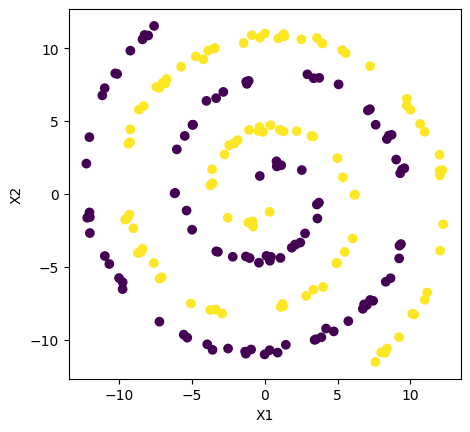

In [1341]:
df = pd.read_csv(r'data/spiral_train.csv')
X = df[['X1', 'X2']].values
y = df['y'].values

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.scatter(X[:,0], X[:,1], c=y)
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_aspect(1)

## b)

Trainieren Sie nun eine logistische Regression und einen MLPClassifier auf diesen Daten. Sie müssen die Daten nicht standardisieren, da die Werte bereits um 0 zentriert sind und dieselbe Größenordnung haben. Sie müssen die Daten auch nicht in ein Trainings- und Testset aufteilen, da wir Ihnen ein separates Testset zur Verfügung stellen. 

Berechnen Sie die Accuracy der logistischen Regression und des MLPClassifiers auf den Trainingsdaten. 

In [1342]:
#######
# Lösung
########
lr = LogisticRegression()
lr.fit(X, y)
lr_pred = lr.predict(X)
accuracy_lr = accuracy_score(y, lr_pred)
print("Logistische Regression Accuracy: ", accuracy_lr)

mlp = MLPClassifier(hidden_layer_sizes=((32,32, 32, 32, 16)), max_iter=50000, random_state=0)
mlp.fit(X, y)
mlp_pred = mlp.predict(X)
accuracy_mlp = accuracy_score(y, mlp_pred)
print("MLP Classifier Accuracy: ", accuracy_mlp)

Logistische Regression Accuracy:  0.58
MLP Classifier Accuracy:  1.0


## c)

Verwenden Sie Pandas, um den Datensatz `X_test.csv` in einem Dataframe `df` zu laden.

Der Datensatz enthält nun die Koordinaten der Punkte ohne ihre Zuordnung. Verwenden Sie das trainierte Netzwerk um die Punkte den Spiralarmen zuzuordnen, und plotten Sie das Resultat sowohl für die Logistische Regression als auch für den MLPClassifier.

Verstehen Sie nun, weshalb die logistische Regression so schlecht abschneidet? 

### Lösung

/Users/std_admin/Desktop/system/ETH/Bachelor Physics/ETH-Data-Analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but MLPClassifier was fitted without feature names
  warnings.warn(


Text(0, 0.5, 'X2')

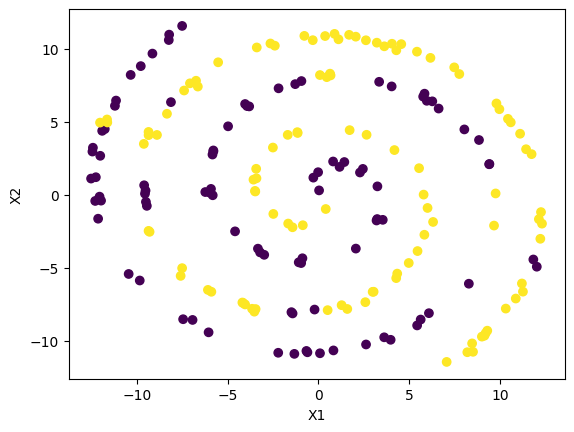

In [1343]:
X_test = pd.read_csv(r"data/spiral_test.csv")
y_test = mlp.predict(X_test)

fig = plt.figure()
plt.scatter(X_test['X1'], X_test['X2'], c=y_test)

plt.xlabel('X1')
plt.ylabel('X2')

# Aufgabe 3: Propagation durch ein neuronales Netz

In der letzten Aufgabe sollen Sie die Propagation durch die hidden Layers eines neuronalen Netzes selber implementieren. In jedem Layer nimmt jedes der $M$ Neuronen die $N$ Inputs, multipliziert jeden davon mit einem Gewicht und bildet dann die Summe. Dies entspricht einer linearen Abbildung eines $N$-Dimensionalen Inputvektors auf $M$ Neuronen, was wiederum als Multiplikation des Inputvektors mit einer $(M\times N)$-Matrix aufgefasst werden kann. In jedem Neuron wird dann zu der Summe noch ein Offset oder Bias addiert und dann wird eine nichtlineare Aktivierungsfunktion darauf angewendet. Diese $M$ Zahlen sind der Output dieses Layers, der als Input an das nächste Layer übergeben wird. 

## a)

Schreiben Sie zuerst zwei Funktionen, die ein einzelnes hidden Layer mit einer ReLU- bzw. einer Sigmoid-Aktivierungsfunktion implementieren. Die Argumente der Funktion sind:

- $N$-dimensionaler Inputvektor (1D-Array mit N Einträgen)
- $(M\times N)$-Gewichtsmatrix ($N$ Gewichte für jedes der $M$ Neuronen)
- $M$-dimensionaler Biasvektor (ein Biaswert für jedes der $M$ Neuronen)

Der Rückgabewert ist ein $M$-dimensionaler Vektor mit den Outputs aller Neuronen.

Für die Matrixmultiplikation  können Sie `np.dot` oder `@` verwenden.

### Lösung

In [1344]:
def forward_propagation(weight_matrix, bias_vector, input_vector):
    """
    Performs forward propagation for one layer with ReLU activation function.
    
    Args:
        weight_matrix (numpy.ndarray): Weight matrix of shape (n_neurons, n_inputs).
        bias_vector (numpy.ndarray): Bias vector of shape (n_neurons,).
        input_vector (numpy.ndarray): Input vector of shape (n_inputs,).
    
    Returns:
        numpy.ndarray: Output vector of shape (n_neurons,).
    """
    # Matrix multiplikation des Inputs mit den Gewichten.
    z = np.dot(weight_matrix, input_vector)
    
    # Hinzuaddieren des Biasvektors
    z += bias_vector
    
    # Anwendend der ReLu Aktivierungsfunktion
    output = np.maximum(0, z)
    
    return output

def forward_sigmoid(weight_matrix, bias_vector, input_vector):
    """
    Performs forward propagation for one layer with sigmoid activation function.
    
    Args:
        weight_matrix (numpy.ndarray): Weight matrix of shape (n_neurons, n_inputs).
        bias_vector (numpy.ndarray): Bias vector of shape (n_neurons,).
        input_vector (numpy.ndarray): Input vector of shape (n_inputs,).
    
    Returns:
        numpy.ndarray: Output vector of shape (n_neurons,).
    """
    # Matrix multiplikation des Inputs mit den Gewichten.
    z = np.dot(weight_matrix, input_vector)
    
    # Hinzuaddieren des Biasvektors
    z += bias_vector
    
    # Anwendend der sigmoid Aktivierungsfunktion
    output = 1 / (1 + np.exp(-z))
    
    return output

## b)

Nutzen Sie das im nächsten Abschnitt gegebene Testarray zusammen mit der gegebenen Gewichtsmatrix und des Biasvektors um ihre Funktionen zu überprüfen. Vergleichen Sie Ihre ergebnisse mit den Resultaten, die wir Ihnen zur Verfügung stellen.

In [1345]:
testarray = np.arange(1, 5)

weight = np.ones((3, 4))
bias = np.array([0, -10, -12])

result_ReLU = np.array([10, 0, 0])
result_sigmoid = np.array([0.9999546, 0.5, 0.11920292])

# Ihr Code

### Lösung

In [1346]:
print(forward_propagation(weight, bias, testarray))
print(forward_sigmoid(weight, bias, testarray))

[10.  0.  0.]
[0.9999546  0.5        0.11920292]


## c) 

Schreiben Sie nun eine Funktion, die die Funktionen aus a) zu einem Netzwerk zusammenfügt. Die Inputs sind:

- input_vector: 1D-Array mit den Inputs für das erste Layer.
- weights: eine Liste mit k-Einträgen, wobei k die Anzahl hidden Layers ist. Jeder Eintrag enthält die Gewichtsmatrix für das entsprechende Layer.
- biases: eine Liste mit k-Einträgen. Jeder Eintrag enthält den Biasvektor für das entsprechende Layer.

Die Funktion iteriert durch alle Layers und propagiert immer den Output des vorigen Layers durch das nächste Layer. Verwenden Sie für alle Layers ausser dem allerletzten die ReLU-Aktivierungsfunktion. Für das letzte Layer verwenden Sie die Sigmoid-Aktivierungsfunktion.

Für einen Classifier will man einen binären Output, 0 oder 1. Da die Sigmoid-Aktivierungsfunktion auch Werte zwischen 0 und 1 zurückgibt, müssen Sie diese noch mit `np.round` auf 0 oder 1 runden.

*Bemerkung: Die Argumente `weights` und `biases` müssen python-Listen anstelle von Numpy-Arrays sein, da diese Einträge unterschiedlichen Typs haben können, z.B.:*
```python
liste = ['a', 2, np.array([2, 5])]
```

### Lösung

In [1347]:
def forward_propagation_network(weights, biases, input_vector):
    """
    Performs forward propagation for a neural network with ReLU activation function.
    
    Args:
        weights (list): List of weight matrices for each layer.
        biases (list): List of bias vectors for each layer.
        input_vector (numpy.ndarray): Input vector of shape (n_inputs,).
    
    Returns:
        numpy.ndarray: Output vector of shape (n_outputs,).
    """
    output = input_vector
    
    # Iteration durch alle Layers
    n = len(weights)
    for i in range(n):
    # Beim letzten Layer wird die sigmoid Aktivierungsfunktion angewendet
        if i < n - 1:
            output = forward_propagation(weights[i], biases[i], output)
        else:
            output = forward_sigmoid(weights[i], biases[i], output)
            
    # Am Schluss runden wir noch, damit das Resultat immer 0 oder 1 ist (Klassifizierungsproblem)
    return np.round(output)

## d)

Mit der Funktion in b) haben sie schon die `predict`-Funktion für einen NN-Classifier implementiert! Das Trainieren des Netzwerks, also das Optimieren der Gewichtsmatrizen und Biasvektoren, ist deutlich aufwendiger und übersteigt den Umfang dieser Übung.

Allerdings können wir unsere Implementation auf Klassifizierungsprobleme anwenden, wenn wir das Resultat des Trainings, also die Gewichtsmatrizen und Biasvektoren, kennen.

Der Datensatz `Data_3/data.csv` enthält ähnlich zu Aufgabe 2 zwei Spalten, die den x- und y-Koordinaten von Punkten entsprechen. Die Punkte können in einen inneren Kreis und einen äusseren Ring aufgeteilt werden.

Laden Sie den Datensatz in eine Dataframe und plotten Sie die Punkte auf einem Scatterplot. 

### Lösung

Text(0, 0.5, 'X2')

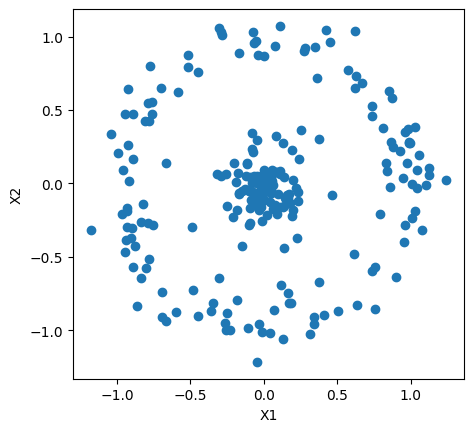

In [1348]:
df = pd.read_csv(r'data/data.csv')
X = df[['X1', 'X2']].values

fig  = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.scatter(X[:, 0], X[:,1])
ax.set_aspect(1)

ax.set_xlabel('X1')
ax.set_ylabel('X2')

## e)

Benutzen Sie nun Ihre Funktion mit den bereitgestellten Gewichtsmatrizen und Biasvektoren, um für jeden Punkt eine Vorhersage zu treffen, ob er in der inneren oder der äusseren Menge liegt. 

Analog zur Spirale können Sie das Resultat in einem Scatterplot darstellen und die Vorhersage als Farbwert übergeben.

In [1349]:

weights = pickle.load(open('data/weights.p', 'rb'))
biases = pickle.load(open('data/biases.p', 'rb'))

# Ihr Code

### Lösung

Text(0, 0.5, 'X2')

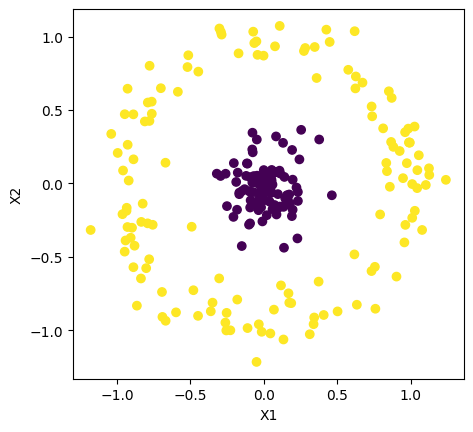

In [1350]:
# Array zum speichern der Vorhersagen
predictions = np.zeros(len(X[:, 0]))

# Iteration durch alle (X1, X2) paare.
for i in range(len(X[:, 0])):
    # Voraussage
    predictions[i] = forward_propagation_network(weights, biases, [X[i, 0], X[i, 1]])[0]
    
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.scatter(X[:, 0], X[:, 1], c=predictions)
ax.set_aspect(1)

ax.set_xlabel('X1')
ax.set_ylabel('X2')

---

In [1351]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import pandas as pd

In diesem Aufgabenblatt werden Sie das erste Mal mit einem Datensatz arbeiten, der nicht für Sie vorbereitet wurde. In der Praxis sind Daten oft unvollständig, enthalten irrelevante Informationen und Merkmale sind so codiert, dass sie nicht direkt für das Lernen verwendet werden können. In der ersten Aufgabe werden Sie den Titanic-Datensatz mithilfe von *scikit-learn* und *pandas* bereinigen. Sie werden die verschiedenen Möglichkeiten sehen, um Kategorische Werte zu kodieren, und fehlende Werte zu ergänzen. 

In der zweiten Aufgabe werden Sie dann den K-Nearest Neighbour Algorithmus und Decision Trees darauf trainieren um die Überlebenschancen der Passagiere vorherzusagen. Dabei werden sie auch nochmals Crossvalidation und Grid Search anwenden um die Modelle zu optimieren.

In der dritten Aufgabe werden Sie den K-Means Clustering Algorithmus selber implementieren und damit besser verstehen wie dieser funktioniert.

# Aufgabe 1: Data-cleaning

Der Titanic-Datensatz enthält Informationen über Passagiere des berühmten Schiffes. Das Ziel ist es, vorherzusagen, ob ein Passagier überlebt hat (`Survived`). Leider können die Daten so nicht verwendet werden: Es fehlen Werte, der 
Datensatz enthält irrelevante Spalten und kategorische Spalten sind Strings statt numerische Werte.

In dieser Aufgabe verwenden Sie pandas und scikit-learn, um den Datensatz `titanic.csv` Schritt für Schritt zu bereinigen und fehlende Daten zu behandeln.  

## a) Laden und explorieren der Daten 

Laden Sie den Datensatz `titanic.csv`.  Schauen Sie sich die ersten Zeilen an und schauen Sie um einen Eindruck über die Daten zu bekommen. Sie finden [hier](https://www.kaggle.com/datasets/yasserh/titanic-dataset/data) mehr Informationen zu den Spalten. Rufen Sie `df.info()` auf um zu sehen, welche Spalten fehlende Werte enthalten. 

### Lösung

In [1352]:
df = pd.read_csv('data/titanic.csv')
display(df.head())
df.info()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


## b) Fehlende Werte behandeln

Behandeln Sie die fehlenden Werte dann wie folgt:

1. Die Spalte `Cabin` fehlt bei über 70% der Passagiere — entfernen Sie sie komplett. Hinweis: Nutzen Sie `df.drop` ([Dokumentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop.html)).
2. Ersetzen Sie fehlende Werte in der Spalte `Age` durch den Mittelwert dieser Spalte.
3. Ersetzen Sie fehlende Werte in der Spalte `Embarked` durch den häufigsten Wert.

Für Schritte 2 und 3: Lesen Sie die Dokumentation zu `SimpleImputer` ([Dokumentation](https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html)) aus `sklearn.impute`. Was müssen Sie beim Parameter `strategy` angeben? Beachten Sie: `fit_transform` nimmt ein 2D-Array entgegen. Der Aufruf ist also z.B. `df[["Name"]] = imputer.fit_transform(df[["Name"]])` (beachten Sie die doppelten eckigen Klammern) und nicht `df["Name"] = imputer.fit_transform(df["Name"])`.

In [1353]:
# 1. Spalte Cabin entfernen (>70% fehlend)
# df = df.drop(columns = ["Cabin"]) # Nutzen Sie df.drop
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Lösung

In [1354]:
from sklearn.impute import SimpleImputer

print("Fehlende Werte vor der Bereinigung:")
print(df.isnull().sum())

# 1. Spalte Cabin entfernen (>70% fehlend)
df = df.drop(columns=['Cabin'])

# 2. Fehlende Altersangaben mit dem Mittelwert ersetzen
age_imputer = SimpleImputer(strategy='mean')
df[['Age']] = age_imputer.fit_transform(df[['Age']])

# 3. Fehlende Embarked-Werte mit dem häufigsten Wert ersetzen
embarked_imputer = SimpleImputer(strategy='most_frequent')
df[['Embarked']] = embarked_imputer.fit_transform(df[['Embarked']])

print("\nFehlende Werte nach der Bereinigung:")
print(df.isnull().sum())

Fehlende Werte vor der Bereinigung:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Fehlende Werte nach der Bereinigung:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


## c) Irrelevante Spalten entfernen

Die Spalten `PassengerId`, `Name` und `Ticket` enthalten keine Information, die ein Modell sinnvoll verwenden kann. Entfernen Sie diese drei Spalten und notieren Sie in einem Kommentar, warum jede Spalte nicht geeignet ist. Nutzen Sie auch hier wieder `df.drop`.

### Lösung

In [1355]:
df = df.drop(columns=['PassengerId', 'Name', 'Ticket'])
print(df.head())

   Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0         0       3    male  22.0      1      0   7.2500        S
1         1       1  female  38.0      1      0  71.2833        C
2         1       3  female  26.0      0      0   7.9250        S
3         1       1  female  35.0      1      0  53.1000        S
4         0       3    male  35.0      0      0   8.0500        S


## d) One-Hot-Kodierung

Die Spalten `Sex` und `Embarked` sind kategorisch. Wenden Sie One-Hot-Kodierung auf beide Spalten an.

Verwenden Sie dazu [`OneHotEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) aus `sklearn.preprocessing`. Lesen Sie die Dokumentation und achten Sie darauf, redundante Spalten zu vermeiden (Stichwort: *Dummy Variable Trap*). Ersetzen Sie anschliessend die ursprünglichen Spalten im DataFrame durch die kodierten Spalten.

Hinweis: Mit `encoder.get_feature_names_out()` erhalten Sie die Namen der neuen Spalten.

### Lösung

In [1356]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(drop='first', sparse_output=False)
encoded_cols = ohe.fit_transform(df[['Sex', 'Embarked']])

# Wir erstellen wieder ein DataFrame aus den kodierten Spalten, damit wir die Spaltennamen behalten
encoded_df = pd.DataFrame(encoded_cols, columns=ohe.get_feature_names_out(), index=df.index)

# Ursprüngliche Spalten entfernen und kodierte hinzufügen
df = df.drop(columns=['Sex', 'Embarked'])
df = pd.concat([df, encoded_df], axis=1)
print(df.head())

   Survived  Pclass   Age  SibSp  Parch     Fare  Sex_male  Embarked_Q  \
0         0       3  22.0      1      0   7.2500       1.0         0.0   
1         1       1  38.0      1      0  71.2833       0.0         0.0   
2         1       3  26.0      0      0   7.9250       0.0         0.0   
3         1       1  35.0      1      0  53.1000       0.0         0.0   
4         0       3  35.0      0      0   8.0500       1.0         0.0   

   Embarked_S  
0         1.0  
1         0.0  
2         1.0  
3         1.0  
4         1.0  


## e) Mean-Kodierung (Zielkodierung)

Bei der Mean-Kodierung (auch *Target Encoding*) wird jeder Wert einer kategorischen Spalte durch den Mittelwert der Zielvariable für diese Gruppe ersetzt.

Ersetzen Sie die Spalte `Pclass` durch die durchschnittliche Überlebensrate der jeweiligen Passagierklasse.

Verwenden Sie dazu `TargetEncoder` ([Dokumentation](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.TargetEncoder.html)) aus `sklearn.preprocessing`. Lesen Sie die Dokumentation. Welche Argumente nehmen `fit_transform` entgegen?

### Lösung

In [1357]:
from sklearn.preprocessing import TargetEncoder

target_enc = TargetEncoder()
df['Pclass'] = target_enc.fit_transform(df[['Pclass']], df['Survived'])
print(df['Pclass'].unique())

[0.2452717  0.61666901 0.24148124 0.25092915 0.24121765 0.47586216
 0.23454289 0.62014412 0.44403695 0.48516551 0.64224115 0.63873361
 0.62433156 0.48535879 0.47233954]


Schauen Sie sich den Datensatz (mit `df.head()` und `df.info()`) nochmals an, um zu sehen, dass jetzt keine fehlenden Werte mehr vorhanden sind und alle Spalten numerisch sind.

### Lösung

In [1358]:
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,0.245272,22.0,1,0,7.2500,1.0,0.0,1.0
1,1,0.616669,38.0,1,0,71.2833,0.0,0.0,0.0
2,1,0.241481,26.0,0,0,7.9250,0.0,0.0,1.0
3,1,0.616669,35.0,1,0,53.1000,0.0,0.0,1.0
4,0,0.245272,35.0,0,0,8.0500,1.0,0.0,1.0


# Aufgabe 2: KNNs und Decision Trees

In dieser Aufgabe verwenden Sie den bereinigten Titanic-Datensatz aus Aufgabe 1, um Klassifikatoren zu trainieren, die vorhersagen, ob ein Passagier überlebt hat.

Falls Sie Aufgabe 1 nicht abgeschlossen haben, können Sie den bereits bereinigten Datensatz `titanic-cleaned.csv` laden.

## Daten vorbereiten

Falls Sie Aufgabe 1 nicht gelöst haben, laden Sie den bereinigten Datensatz. Teilen Sie die Daten in Features `X` (alle Spalten ausser `Survived`) und Zielvariable `y` (`Survived`) auf.

### Lösung

In [1359]:
# Falls Aufgabe 1 nicht gelöst wurde:
df = pd.read_csv('data/titanic_cleaned.csv')

X = df.drop(columns=['Survived'])
y = df['Survived']


## a) K-Nearest Neighbours (KNN)

Da KNN auf Distanzen basiert, müssen die Features zuerst standardisiert werden, damit Features mit grossen Wertebereichen nicht die Distanzberechnung dominieren. Verwenden Sie `StandardScaler` aus `sklearn.preprocessing`, um `X` zu skalieren (`fit_transform`). Trainieren Sie dann einen KNN-Klassifikator ([Dokumentation](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)) auf den skalierten Daten.

Probieren Sie verschiedene Werte für den Parameter `n_neighbors` aus, um die beste Anzahl von Nachbarn zu finden. Validieren Sie mit Kreuzvalidierung (also der Funktion `cross_val_score` ([Dokumentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html)). 

### Lösung

In [1360]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

cross_val_results = cross_val_score(KNeighborsClassifier(n_neighbors=20), X_scaled, y, cv=5, scoring='accuracy')
print("Durchschnittliche Genauigkeit:", np.mean(cross_val_results))

Durchschnittliche Genauigkeit: 0.812560416797439


## b) Decision Tree

Trainieren Sie jetzt den  `DecisionTreeClassifier` ([Dokumentation](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)).

Statt wie beim KNN manuell die Hyperparameter festzulegen, durchsuchen Sie diese mit `GridSearchCV` . Nutzen Sie folgendes Parameter-Gitter:
- `max_depth`: 2, 3, 4, 5 und `None` (unbeschränkt)
- `criterion`: `'gini'` und `'entropy'`
- `min_samples_leaf`: 1, 2, 4

Verwenden Sie `scoring='accuracy'` und 5-fache Kreuzvalidierung auf dem gesamten Datensatz. Geben Sie die besten Parameter und die beste mittlere CV-Genauigkeit aus. Vergleichen Sie diese mit der KNN-Genauigkeit aus a).

*Hinweis: Bei Decision Trees ist es nicht notwendig, die Daten zu skalieren, da sie auf Entscheidungsregeln basieren und nicht auf Distanzen.*

### Lösung

In [1361]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [2, 3, 4, 5, None],
    'criterion': ['gini', 'entropy'],
    'min_samples_leaf': [1, 2, 4],
}

grid_search_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, scoring='accuracy', cv=5)
grid_search_dt.fit(X, y)

print("Beste Parameter:", grid_search_dt.best_params_)
print(f"Beste CV-Genauigkeit (DT):  {grid_search_dt.best_score_:.3f}")

Beste Parameter: {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 1}
Beste CV-Genauigkeit (DT):  0.816


## c) Den Entscheidungsbaum visualisieren

Sie finden nachfolgend Code um den trainierten Entscheidungsbaum zu visualisieren. 

**Frage:** Was sind die wichtigsten Entscheidungsfragen? Ist dies was Sie erwartet hätten? 

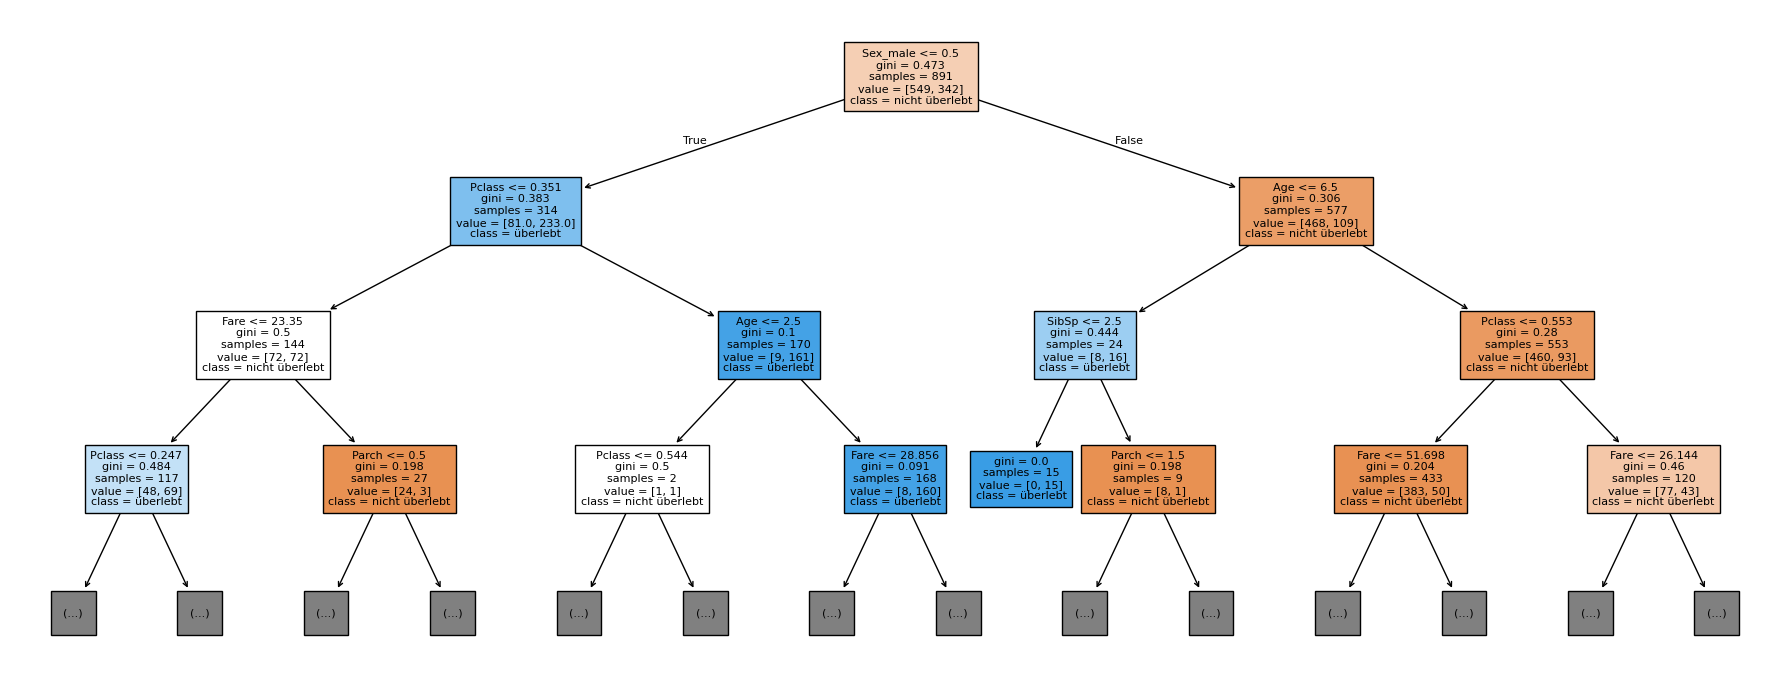

In [1362]:
from sklearn.tree import plot_tree

best_dt = grid_search_dt.best_estimator_

class_names = ['nicht überlebt' if c == 0 else 'überlebt' for c in best_dt.classes_]

plt.figure(figsize=(18, 7))
plot_tree(best_dt, max_depth=3, feature_names=X.columns, class_names=class_names, filled=True, fontsize=8)
plt.tight_layout()
plt.show()

### Lösung

Wir sehen deutlich, dass Muster, dass Frauen und Kinder eher überlebt haben, als Männer. Das ist auch historisch korrekt, da Frauen und Kinder zuerst in die Rettungsboote gelassen wurden. Auch die Passagierklasse spielt eine wichtige Rolle. 

# Aufgabe 3: K-means Clustering in 2D

In dieser Aufgabe werden Sie den k-means Clustering Algorithmus selber zu implementieren. Der Algorithmus teilt eine Punktewolke in $\mathbb{R}^2$ in $k$ Clusters auf.

Wir geben Ihnen zuerst eine Beschreibung des gesamten Algorithmus. Anschliessend implementieren und testen Sie die Schritte einzeln, bevor Sie sie zum Algorithmus zusammenfügen und diesen auf einem Testdatensatz anwenden.

**Clustering Algorithmus**

Inputs: Koordinaten $(x_i, y_i)$ aller Punkte, Anzahl $k$ Clusters.

Am Anfang werden $k$ Punkte zufällig gewählt. Diese dienen als Ausgangswerte für die Schwerpunkte der Clusters.

Nun werden folgende zwei Schritte iterativ ausgeführt:

1. Weise jeden Punkt dem Cluster zu, dessen Schwerpunkt (Centroid) am nächsten liegt.

2. Berechne die Schwerpunkte der Clusters neu (Mittelwert der Koordinaten in jedem Cluster).

Die Iteration wird solange durchgeführt, bis sich die Position der Schwerpunkte nicht mehr ändert.

## a)

Schreiben Sie eine Funktion, die die euklidische Distanz zwischen zwei Punkten berechnet.

### Lösung

In [1363]:
def euclidian_distance(p1, p2):
    '''Calculate the Euclidian distance between two points p1 and p2.'''
    return np.sqrt(np.sum((p1 - p2)**2))

## b)

Implementieren Sie den ersten Schritt der Iteration: Die Zuweisung der Punkte zu Clusters mit gegebenen Schwerpunkten. Sie können das als Funktion schreiben, oder einfach als Codesnippet, das sie nach dem Testen in den Algorithmus kopieren.

Verwenden Sie hier die vordefinierten Arrays `points` und `centroids`, welche die Datenpunkte und die Schwerpunkte der Clusters enthalten. Iterieren Sie durch alle Datenpunkte, finden Sie den nächstgelegenen Schwerpunkt, und speichern Sie den Index dieses Schwerpunktes in einem Array `assignment`.

*Hinweis: Da im Array `assignment` Indizes gespeichert werden, ist es vorteilhaft, den Datentyp der Arrayeinträge als `int` festzulegen (`dtype=int`).*

Zum Überprüfen können sie die Punkte als Scatterplot darstellen, wobei die Farbe jedes Punktes der Zuweisung zum Cluster entspricht.

In [1364]:
n_clusters = 2
points = pickle.load(open('data/testpoints.p', 'rb'))
centroids = pickle.load(open('data/testcentroids.p', 'rb'))

### Lösung

In [1365]:
# Initialisiere Array für die Zuweisungen
assignment = np.zeros(len(points), dtype=int)
for i, p in enumerate(points):
    # Berchne die Distanz zu jedem Schwerpunkt und speichere den Index des nächsten
    min_distance = np.inf
    for j, c in enumerate(centroids):
        distance = euclidian_distance(p, c)
        if distance < min_distance:  # Kleinere Distanz gefunden?
            min_distance = distance
            assignment[i] = j

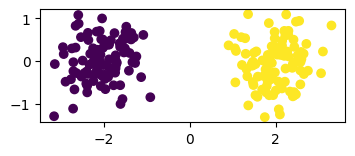

In [1366]:
# Überprüfen
cm = 1 / 2.54
fig = plt.figure(figsize=(10*cm, 10*cm))
ax = fig.add_subplot(1, 1, 1)
ax.scatter(points[:, 0], points[:, 1], c=assignment)
ax.set_aspect(1)

## c)

Implementieren Sie den zweiten Schritt der Iteration: Die Neuberechnung der Schwerpunkte.
    
Verwenden Sie die vordefinierten Arrays `points` und `assignment`. Die Anzahl Cluster ist auch bekannt und in der Variable `n_clusters` gespeichert. Ermitteln Sie den Mittelwert der Koordinaten aller Punkte, die zum gleichen Cluster gehören, wobei x- und y-Koordinaten  separat gemittelt werden. Speichern Sie diese Mittelwerte in `new_centroids`. Sie entsprechen den Koordinaten  der neuen Schwerpunkte.

Zum Überprüfen können Sie wieder die Punkte als Scatterplot darstellen und zusätzlich die Schwerpunkte rot markiert plotten.

<br>
<details>
    <summary><u>Tipp 1 anzeigen</u></summary>
    <br>
    Initialisieren Sie ein Array <code>coord_sum</code> der Grösse <code>(n_clusters, 2)</code>, um die Summe der Koordinaten der Punkte in jedem Cluster zu speichern, und ein Array <code>cluster_size</code> der Grösse <code>(n_clusters)</code>, um die Anzahl Punkte in jedem Cluster zu speichern.
    Iterieren Sie durch die Punkte, um die Koordinaten aufzusummieren und die Grösse der Clusters zu bestimmen.
</details>

<br>
<details>
    <summary><u>Tipp 2 anzeigen</u></summary>
    <br>
    <b>Methode 1</b>: Ein äusserer for-Loop mit Laufvariable <code>k</code> iteriert durch alle Clusters. Ein innerer for-Loop iteriert durch alle Punkte. Bei jedem Punkt prüfen Sie, ob er im <code>k</code>-ten Cluster ist, und falls ja addieren Sie seine Koordinaten zu <code>coord_sum[k]</code> und erhöhen <code>n_clusters[k]</code> um 1. <br>
    <b>Methode 2</b>: Nur ein for-Loop, der durch alle Punkte iteriert, Laufvariable <code>i</code>. Lesen Sie den Index <code>k</code> des Clusters, in dem der <code>i</code>-te Punkt liegt, aus dem Array <code>assignment</code>. Addieren Sie die Koordinaten des <code>i</code>-ten Punktes zu <code>coord_sum[k]</code> und erhöhen Sie <code>n_clusters[k]</code> um 1. <br><br>
    Bilden Sie aus <code>coord_sum</code> und <code>cluster_size</code> den Mittelwert der Koordinaten jedes Clusters und speichern Sie diese im Array <code>new_centroids</code>.
</details>

In [1367]:
n_clusters = 2
points = pickle.load(open('data/testpoints.p', 'rb'))
assignment = pickle.load(open('data/testassignment.p', 'rb'))

### Lösung

In [1368]:
# Array zum Speichern der Anzahl Punkte in jedem Cluster
cluster_size = np.zeros(n_clusters)

# Array zum Speichern der summierten Koordinaten
coord_sum = np.zeros(shape=(n_clusters, 2))

for i, p in enumerate(points):
    # Zum Punkt zugehörigen Cluster auswählen
    cluster_ind = assignment[i]

    # Koordinaten des Punktes zur Summe addieren, Grösse des Clusters um eins erhöhen.
    coord_sum[cluster_ind] += p
    cluster_size[cluster_ind] += 1

# Jede der Koordinatensummen wird durch die entsprechende Clustergrösse dividiert -> Mittelwert
new_centroids = np.zeros(shape=(n_clusters, 2))
for j in range(len(new_centroids)):
    new_centroids[j] = coord_sum[j] / (cluster_size[j] + 1e-9)

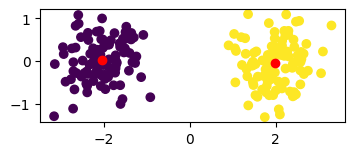

In [1369]:
# Überprüfen
cm = 1 / 2.54
fig = plt.figure(figsize=(10*cm, 10*cm))
ax = fig.add_subplot(1, 1, 1)
ax.scatter(points[:, 0], points[:, 1], c=assignment)
ax.scatter(new_centroids[:, 0], new_centroids[:, 1], c='r')
ax.set_aspect(1)

## d)

Setzen Sie nun die zwei Schritte zum iterativen Algorithmus zusammen. Schreiben Sie hierzu eine Funktion, die folgende Argumente nimmt:

- `points`: Das Array mit den Datenpunkten.
- `n_clusters`: Ein Integer mit der Anzahl Clusters, in die die Punkte eingeteilt werden sollen.
- `tol`: Eine absolute Toleranz für die Abbruchbedingung (siehe unten).
- `max_iterations`: Ein Integer, das angibt, nach wie vielen Durchgängen die Iteration spätestens abgebrochen wird.

Für die Initialisierung erstellen sie ein Zufallsgenerator-Objekt mit `rng = np.random.default_rng()` und verwenden dessen Funktion `rng.choice()` um zufällige Punkte aus dem Datensatz zu wählen.

Die zwei Schritten kommen dann in eine `while`-Schleife mit folgenden Abbruchbedingungen:

- Kein Schwerpunkt hat sich im letzten Durchlauf um mehr als `tol` verschoben, **oder**
- Die Anzahl Durchläufe ist grösser als `max_iterations`.

Am Ende gibt die Funktion die Arrays `assignment` und `centroids` aus, die die Zuweisung der Punkte zu Clusters und die Schwerpunkte der Clusters enthalten.

Testen Sie Ihren Code am Datensatz 'Data3/xy_dataset.txt'. Sie können mit `sklearn.datasets.make_blobs(centers=n_clusters)` auch eigene Datensätze mit mehr oder weniger Clusters generieren. Wenn Sie die Zwischenresultate des Algorithmus anschauen wollen, können Sie `max_iterations` auf 1, 2, 3, etc. setzen und das Resultat plotten.

Extrabonus: Verallgemeinern Sie den Algorithmus für Punkte in $\mathbb{R}^n$.

In [1370]:
from sklearn.datasets import make_blobs

### Lösung

In [1371]:
def euclidian_distance(p1, p2):
    '''Calculate the Euclidian distance between two points p1 and p2.'''
    return np.sqrt(np.sum((p1 - p2)**2))


def k_means(points, n_clusters=3, tol=1e-3, max_iterations=100):
    '''Assign points in M-D space to n_clusters different clusters.
    Args:
        points (Array): 2D-Array with shape (N, M) containing N datapoints points in M-D space.
        n_clusters (int): Number of clusters
        tol (float): tolerance for centroid update to stop the iteration.
                     Iteration stops when the sum of distances between new
                     and old centroid locations is smaller than tol.
        max_iterations (int): Maximum iterations stop condition
        
    Returns:
        assignment: 1D-Array of length N with the assignment for each point to a cluster.
                    Assignment corresponds to index in centroids array.
        centroids: 2D-Array with shape (n_clusters, M) giving the final centroid locations.'''
    
    # Find dimensionality of points
    dim = points.shape[1]
    
    # Inital centroids are chosen randomly from dataset.
    # np.random.seed(1)  # optional fixed seed for reproducible RNG
    rng = np.random.default_rng()
    centroids = rng.choice(points, n_clusters, replace=False)
    
    # Initialize a list that stores the assigment of points to centroids
    assignment = np.zeros(len(points), dtype=int)
    
    # Iterate over assignment and centroid recalculation until centroids are not moving anymore
    centroid_shift = np.inf
    num_iter = 0
    while np.max(centroid_shift) > tol and num_iter < max_iterations:
        ## Assignment
        for i, p in enumerate(points):
            # calculate Euclidian distance to each centroid, save the index of the
            # centroid with smallest distance
            min_distance = np.inf
            for j, c in enumerate(centroids):
                distance = euclidian_distance(p, c)
                if distance < min_distance:
                    min_distance = distance
                    assignment[i] = j
        
        ## Recalculate centroids as means of each cluster
        # Array that stores number of points in each cluster
        cluster_size = np.zeros(n_clusters)
        
        # Array that stores sum of the coordinates of the points in each cluster
        # Used to calculate the mean of the coordinates -> new centroids
        coord_sum = np.zeros(shape=(n_clusters, dim))
        
        for i, p in enumerate(points):
            # Select assigned cluster
            cluster_ind = assignment[i]
            
            # Add x and y coordinates centroid coordinates, increase number of points in cluster by 1
            coord_sum[cluster_ind] += p
            cluster_size[cluster_ind] += 1
        
        # Divide each of the coord_sum by the corresponding cluster_size
        # -> we have calculated the mean of the x and y coordinates of all points in each cluster
        new_centroids = np.zeros(shape=(n_clusters, dim))
        for j in range(len(new_centroids)):
            new_centroids[j] = coord_sum[j] / (cluster_size[j] + 1e-9)
        
        # calculate the total shift
        centroid_shift = np.zeros(n_clusters)
        for j in range(len(new_centroids)):
            centroid_shift[j] = euclidian_distance(centroids[j], new_centroids[j])  # Norm of the vector
            
        # Update centroids and number of iterations
        centroids = np.copy(new_centroids)
        num_iter += 1
    
    # End while
    
    if num_iter >= max_iterations - 1:
        print('Warning: maximum iterations reached. Result might not be converged.')
    
    # Return assigments
    return assignment, centroids

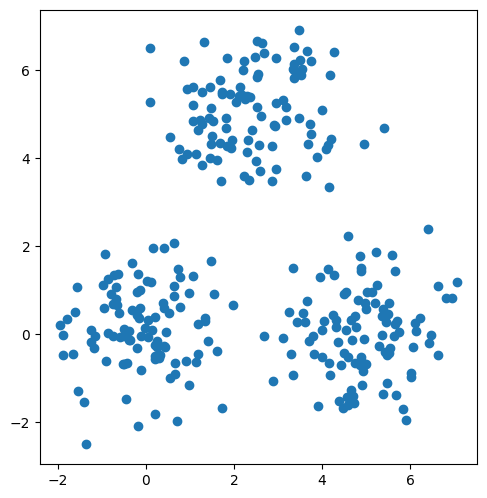

In [1372]:
# Daten Laden und Plotten
points = np.loadtxt('data/xy_dataset.txt')

cm = 1 / 2.54
fig = plt.figure(figsize=(15*cm, 15*cm))
ax = fig.add_subplot(1, 1, 1)
ax.scatter(points[:, 0], points[:, 1])
ax.set_aspect(1)

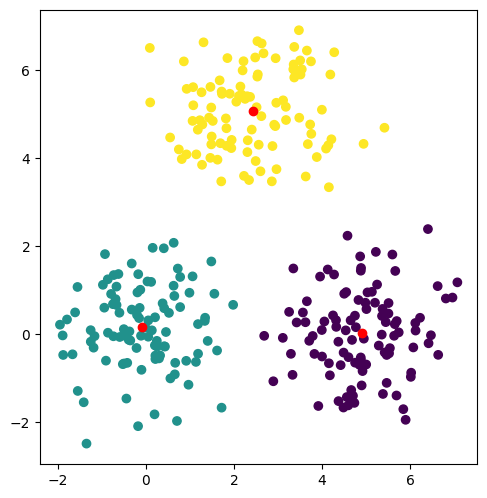

In [1373]:
# k-means Clustering anwenden, Resultat plotten
assignment, centroids = k_means(points, n_clusters=3, max_iterations=10)

cm = 1 / 2.54
fig = plt.figure(figsize=(15*cm, 15*cm))
ax = fig.add_subplot(1, 1, 1)
ax.scatter(points[:, 0], points[:, 1], c=assignment)
ax.scatter(centroids[:, 0], centroids[:, 1], c='r')
ax.set_aspect(1)

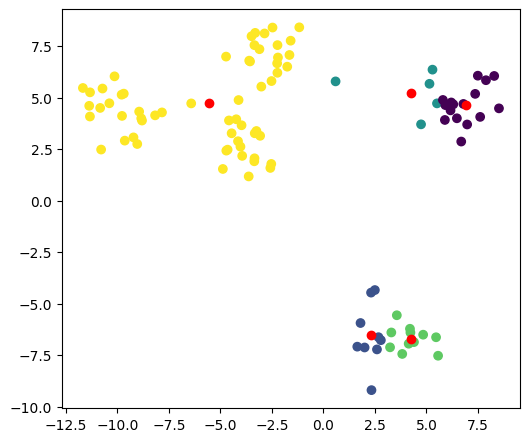

In [1374]:
# Eigene Datensätze generieren und Resultat plotten
n_clusters = 5
points, _ = make_blobs(centers=n_clusters)

assignment, centroids = k_means(points, n_clusters=n_clusters, max_iterations=100)

cm = 1 / 2.54
fig = plt.figure(figsize=(15*cm, 15*cm))
ax = fig.add_subplot(1, 1, 1)
ax.scatter(points[:, 0], points[:, 1], c=assignment)
ax.scatter(centroids[:, 0], centroids[:, 1], c='r')
ax.set_aspect(1)

Wenn Sie einige zufällige Datensätze ausprobieren, werden Sie sehen, dass der Algorithmus die Cluster nicht immer korrekt identifizieren kann. Das liegt an der zufälligen Initialisierung und daran, dass der Algorithmus relativ simpel ist und sozusagen in lokalen Minima stecken bleiben kann. Allerdings ist die Konvergenz erstaunlich schnell, meistens braucht es nur 4 oder 5 Iterationen, um zum Resultat zu gelangen.